# Optimization Algorithms From Scratch

## Goals

Implement and understand:

- Batch Gradient Descent
- Mini-Batch SGD
- SGD with Momentum
- Nesterov Momentum
- AdaGrad
- RMSProp
- Adam
- AdamW
- Learning-rate schedulers
- Gradient clipping
- Weight decay

We will implement the algorithms using:

1. NumPy
2. PyTorch tensors without using `torch.optim`

We will compare them on:

- Linear regression
- Logistic regression
- A small MLP on Fashion-MNIST

We will track:

- Training loss
- Validation loss
- Gradient norms
- Learning rate
- Parameter trajectories on two-dimensional toy problems

In [3]:
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
Device: cpu


In [4]:
def generate_linear_data(
    n_samples=200,
    true_weight=3.0,
    true_bias=2.0,
    noise_std=0.8,
    seed=42,
):
    """
    Generate data using:

        y = true_weight * x + true_bias + noise
    """

    rng = np.random.default_rng(seed)

    X = rng.uniform(
        low=-3.0,
        high=3.0,
        size=(n_samples, 1),
    )

    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_samples, 1),
    )

    y = true_weight * X + true_bias + noise

    return X, y


X, y = generate_linear_data()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst five inputs:")
print(X[:5])

print("\nFirst five targets:")
print(y[:5])

X shape: (200, 1)
y shape: (200, 1)

First five inputs:
[[ 1.64373629]
 [-0.36672936]
 [ 2.15158752]
 [ 1.18420817]
 [-2.43493591]]

First five targets:
[[ 7.44587031]
 [ 0.58412782]
 [ 8.45066507]
 [ 5.4218702 ]
 [-5.0347481 ]]


In [5]:
def train_validation_split(
    X,
    y,
    validation_fraction=0.2,
    seed=42,
):
    """
    Randomly divide X and y into training and validation sets.
    """

    rng = np.random.default_rng(seed)

    n_samples = len(X)

    indices = rng.permutation(n_samples)

    n_validation = int(
        n_samples * validation_fraction
    )

    validation_indices = indices[:n_validation]
    training_indices = indices[n_validation:]

    X_train = X[training_indices]
    y_train = y[training_indices]

    X_validation = X[validation_indices]
    y_validation = y[validation_indices]

    return (
        X_train,
        y_train,
        X_validation,
        y_validation,
    )


(
    X_train,
    y_train,
    X_validation,
    y_validation,
) = train_validation_split(X, y)

print("Training examples:", len(X_train))
print("Validation examples:", len(X_validation))

Training examples: 160
Validation examples: 40


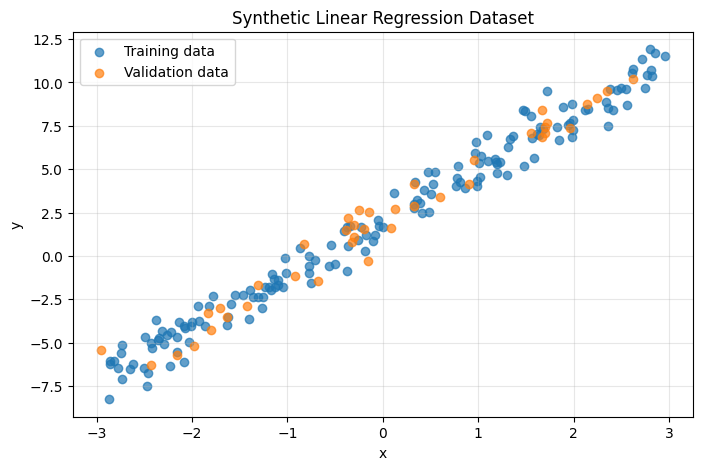

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train,
    y_train,
    alpha=0.7,
    label="Training data",
)

plt.scatter(
    X_validation,
    y_validation,
    alpha=0.7,
    label="Validation data",
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Synthetic Linear Regression Dataset"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
def linear_model(X, weight, bias):
    """
    Linear-regression model:

        y_hat = Xw + b
    """

    predictions = X @ weight + bias

    return predictions

In [8]:
weight = np.array([[0.0]])
bias = np.array([[0.0]])

predictions = linear_model(
    X_train,
    weight,
    bias,
)

print("Weight shape:", weight.shape)
print("Bias shape:", bias.shape)
print("Prediction shape:", predictions.shape)

print("\nFirst five predictions:")
print(predictions[:5])

Weight shape: (1, 1)
Bias shape: (1, 1)
Prediction shape: (160, 1)

First five predictions:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [9]:
def mean_squared_error(
    predictions,
    targets,
):
    """
    Mean squared error:

        MSE = mean((prediction - target)^2)
    """

    errors = predictions - targets

    loss = np.mean(errors ** 2)

    return loss

In [10]:
initial_loss = mean_squared_error(
    predictions,
    y_train,
)

print(f"Initial training loss: {initial_loss:.4f}")

Initial training loss: 32.7377


In [11]:
def linear_regression_gradients(
    X,
    predictions,
    targets,
):
    """
    Compute analytical gradients of MSE.

    Model:
        predictions = X @ weight + bias

    Loss:
        mean((predictions - targets)^2)
    """

    n_samples = len(X)

    errors = predictions - targets

    weight_gradient = (
        2.0 / n_samples
    ) * (X.T @ errors)

    bias_gradient = (
        2.0 / n_samples
    ) * np.sum(
        errors,
        axis=0,
        keepdims=True,
    )

    return weight_gradient, bias_gradient

In [12]:
weight_gradient, bias_gradient = (
    linear_regression_gradients(
        X_train,
        predictions,
        y_train,
    )
)

print("Weight gradient:")
print(weight_gradient)

print("\nBias gradient:")
print(bias_gradient)

Weight gradient:
[[-18.44484313]]

Bias gradient:
[[-3.70152997]]


In [13]:
def compute_loss(
    X,
    y,
    weight,
    bias,
):
    predictions = linear_model(
        X,
        weight,
        bias,
    )

    return mean_squared_error(
        predictions,
        y,
    )


def numerical_gradient(
    parameter,
    loss_function,
    epsilon=1e-5,
):
    """
    Approximate a gradient using central differences:

        df/dx ≈
        [f(x + epsilon) - f(x - epsilon)]
        / (2 * epsilon)
    """

    gradient = np.zeros_like(
        parameter,
        dtype=np.float64,
    )

    for index in np.ndindex(
        parameter.shape
    ):
        original_value = parameter[index]

        parameter[index] = (
            original_value + epsilon
        )

        positive_loss = loss_function()

        parameter[index] = (
            original_value - epsilon
        )

        negative_loss = loss_function()

        parameter[index] = original_value

        gradient[index] = (
            positive_loss - negative_loss
        ) / (2.0 * epsilon)

    return gradient

In [14]:
weight = np.array(
    [[0.0]],
    dtype=np.float64,
)

bias = np.array(
    [[0.0]],
    dtype=np.float64,
)


def current_loss():
    return compute_loss(
        X_train,
        y_train,
        weight,
        bias,
    )


predictions = linear_model(
    X_train,
    weight,
    bias,
)

analytical_weight_gradient, \
analytical_bias_gradient = (
    linear_regression_gradients(
        X_train,
        predictions,
        y_train,
    )
)

numerical_weight_gradient = (
    numerical_gradient(
        weight,
        current_loss,
    )
)

numerical_bias_gradient = (
    numerical_gradient(
        bias,
        current_loss,
    )
)

print("Analytical weight gradient:")
print(analytical_weight_gradient)

print("\nNumerical weight gradient:")
print(numerical_weight_gradient)

print("\nWeight-gradient difference:")
print(
    np.abs(
        analytical_weight_gradient
        - numerical_weight_gradient
    )
)

print("\nAnalytical bias gradient:")
print(analytical_bias_gradient)

print("\nNumerical bias gradient:")
print(numerical_bias_gradient)

print("\nBias-gradient difference:")
print(
    np.abs(
        analytical_bias_gradient
        - numerical_bias_gradient
    )
)

Analytical weight gradient:
[[-18.44484313]]

Numerical weight gradient:
[[-18.44484313]]

Weight-gradient difference:
[[3.43181483e-10]]

Analytical bias gradient:
[[-3.70152997]]

Numerical bias gradient:
[[-3.70152997]]

Bias-gradient difference:
[[1.33042466e-10]]


# Part 2: Batch Gradient Descent in NumPy

Batch Gradient Descent computes the gradient using the entire
training dataset before performing one parameter update.

For parameters $\theta$, the update rule is:

$$
\theta_{t+1}
=
\theta_t
-
\eta \nabla_\theta L(\theta_t)
$$

where:

- $\eta$ is the learning rate;
- $\nabla_\theta L$ is the gradient of the loss;
- one epoch produces one optimizer update because the entire
  training set is one batch.

In [15]:
class NumPyOptimizer:
    """
    Base class for NumPy optimizers.

    Every optimizer will implement a step() method
    that updates model parameters using gradients.
    """

    def __init__(self, learning_rate):
        if learning_rate <= 0:
            raise ValueError(
                "learning_rate must be greater than zero."
            )

        self.learning_rate = learning_rate
        self.step_count = 0

    def step(self, parameters, gradients):
        """
        Update parameters using gradients.

        This method must be implemented by each
        optimizer subclass.
        """

        raise NotImplementedError

    def zero_grad(self):
        """
        Included for API consistency.

        NumPy arrays do not accumulate gradients
        automatically, so this currently does nothing.
        """

        pass

In [16]:
class BatchGradientDescent(NumPyOptimizer):
    """
    Standard gradient-descent optimizer.

    Update rule:

        parameter =
            parameter
            - learning_rate * gradient

    It becomes Batch Gradient Descent when the
    gradients are computed using the complete
    training dataset.
    """

    def step(self, parameters, gradients):

        if parameters.keys() != gradients.keys():
            raise ValueError(
                "Parameters and gradients must "
                "have the same keys."
            )

        for name in parameters:

            parameters[name] -= (
                self.learning_rate
                * gradients[name]
            )

        self.step_count += 1

In [17]:
# Initialize model parameters

parameters = {
    "weight": np.array(
        [[0.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[0.0]],
        dtype=np.float64,
    ),
}


# Create the optimizer

optimizer = BatchGradientDescent(
    learning_rate=0.05
)


# Compute predictions before the update

predictions = linear_model(
    X_train,
    parameters["weight"],
    parameters["bias"],
)


# Compute the loss before the update

loss_before_update = mean_squared_error(
    predictions,
    y_train,
)


# Compute gradients

weight_gradient, bias_gradient = (
    linear_regression_gradients(
        X_train,
        predictions,
        y_train,
    )
)


gradients = {
    "weight": weight_gradient,
    "bias": bias_gradient,
}


# Perform one optimizer update

optimizer.step(
    parameters,
    gradients,
)


# Compute predictions after the update

updated_predictions = linear_model(
    X_train,
    parameters["weight"],
    parameters["bias"],
)


# Compute the new loss

loss_after_update = mean_squared_error(
    updated_predictions,
    y_train,
)


print(
    f"Loss before update: "
    f"{loss_before_update:.6f}"
)

print(
    f"Loss after update:  "
    f"{loss_after_update:.6f}"
)

print(
    "\nUpdated weight:",
    parameters["weight"].item(),
)

print(
    "Updated bias:",
    parameters["bias"].item(),
)

print(
    "\nOptimizer steps:",
    optimizer.step_count,
)

Loss before update: 32.737658
Loss after update:  17.634697

Updated weight: 0.9222421567039514
Updated bias: 0.18507649864884146

Optimizer steps: 1


In [18]:
def compute_global_gradient_norm(
    gradients,
):
    """
    Compute the global L2 norm of all gradients.

    global_norm =
        sqrt(
            sum of every squared gradient value
        )
    """

    sum_of_squares = 0.0

    for gradient in gradients.values():

        sum_of_squares += np.sum(
            gradient ** 2
        )

    global_norm = np.sqrt(
        sum_of_squares
    )

    return float(global_norm)

In [19]:
gradient_norm = (
    compute_global_gradient_norm(
        gradients
    )
)

print(
    f"Global gradient norm: "
    f"{gradient_norm:.6f}"
)

Global gradient norm: 18.812591


In [20]:
def create_training_history():
    """
    Create an empty dictionary for storing
    training metrics.
    """

    history = {
        "train_loss": [],
        "validation_loss": [],
        "gradient_norm": [],
        "learning_rate": [],
        "weight": [],
        "bias": [],
    }

    return history

In [21]:
def train_linear_regression_batch_gd(
    X_train,
    y_train,
    X_validation,
    y_validation,
    optimizer,
    epochs=100,
    initial_weight=0.0,
    initial_bias=0.0,
    print_every=10,
):
    """
    Train linear regression using
    Batch Gradient Descent.

    One epoch:

    1. Use the complete training dataset.
    2. Compute predictions.
    3. Compute training loss.
    4. Compute gradients.
    5. Record the gradient norm.
    6. Update the parameters.
    7. Compute training and validation losses
       using the updated parameters.
    8. Save all metrics.
    """

    parameters = {
        "weight": np.array(
            [[initial_weight]],
            dtype=np.float64,
        ),

        "bias": np.array(
            [[initial_bias]],
            dtype=np.float64,
        ),
    }


    history = create_training_history()


    # Save the initial parameter position.

    history["weight"].append(
        parameters["weight"].item()
    )

    history["bias"].append(
        parameters["bias"].item()
    )


    for epoch in range(1, epochs + 1):

        # -----------------------------------
        # Forward pass on the training set
        # -----------------------------------

        predictions = linear_model(
            X_train,
            parameters["weight"],
            parameters["bias"],
        )


        # -----------------------------------
        # Compute gradients
        # -----------------------------------

        (
            weight_gradient,
            bias_gradient,
        ) = linear_regression_gradients(
            X_train,
            predictions,
            y_train,
        )


        gradients = {
            "weight": weight_gradient,
            "bias": bias_gradient,
        }


        # -----------------------------------
        # Measure gradient magnitude
        # before updating the parameters
        # -----------------------------------

        gradient_norm = (
            compute_global_gradient_norm(
                gradients
            )
        )


        # -----------------------------------
        # Update model parameters
        # -----------------------------------

        optimizer.step(
            parameters,
            gradients,
        )


        # -----------------------------------
        # Compute training loss after update
        # -----------------------------------

        updated_train_predictions = (
            linear_model(
                X_train,
                parameters["weight"],
                parameters["bias"],
            )
        )


        train_loss = mean_squared_error(
            updated_train_predictions,
            y_train,
        )


        # -----------------------------------
        # Compute validation loss
        # -----------------------------------

        validation_predictions = (
            linear_model(
                X_validation,
                parameters["weight"],
                parameters["bias"],
            )
        )


        validation_loss = (
            mean_squared_error(
                validation_predictions,
                y_validation,
            )
        )


        # -----------------------------------
        # Save metrics
        # -----------------------------------

        history["train_loss"].append(
            train_loss
        )

        history[
            "validation_loss"
        ].append(
            validation_loss
        )

        history[
            "gradient_norm"
        ].append(
            gradient_norm
        )

        history[
            "learning_rate"
        ].append(
            optimizer.learning_rate
        )

        history["weight"].append(
            parameters["weight"].item()
        )

        history["bias"].append(
            parameters["bias"].item()
        )


        # -----------------------------------
        # Print progress
        # -----------------------------------

        if (
            epoch == 1
            or epoch % print_every == 0
            or epoch == epochs
        ):

            print(
                f"Epoch {epoch:4d} | "
                f"Train loss: "
                f"{train_loss:.6f} | "
                f"Validation loss: "
                f"{validation_loss:.6f} | "
                f"Gradient norm: "
                f"{gradient_norm:.6f}"
            )


    return parameters, history

In [22]:
batch_gd_optimizer = (
    BatchGradientDescent(
        learning_rate=0.05
    )
)


batch_gd_parameters, batch_gd_history = (
    train_linear_regression_batch_gd(
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        optimizer=batch_gd_optimizer,
        epochs=100,
        initial_weight=0.0,
        initial_bias=0.0,
        print_every=10,
    )
)

Epoch    1 | Train loss: 17.634697 | Validation loss: 14.935597 | Gradient norm: 18.812591
Epoch   10 | Train loss: 1.185670 | Validation loss: 1.297035 | Gradient norm: 1.760348
Epoch   20 | Train loss: 0.704040 | Validation loss: 0.728738 | Gradient norm: 0.562243
Epoch   30 | Train loss: 0.647798 | Validation loss: 0.648872 | Gradient norm: 0.196189
Epoch   40 | Train loss: 0.640944 | Validation loss: 0.633999 | Gradient norm: 0.068498
Epoch   50 | Train loss: 0.640109 | Validation loss: 0.630372 | Gradient norm: 0.023916
Epoch   60 | Train loss: 0.640007 | Validation loss: 0.629296 | Gradient norm: 0.008350
Epoch   70 | Train loss: 0.639994 | Validation loss: 0.628944 | Gradient norm: 0.002915
Epoch   80 | Train loss: 0.639993 | Validation loss: 0.628824 | Gradient norm: 0.001018
Epoch   90 | Train loss: 0.639993 | Validation loss: 0.628782 | Gradient norm: 0.000355
Epoch  100 | Train loss: 0.639993 | Validation loss: 0.628768 | Gradient norm: 0.000124


In [23]:
learned_weight = (
    batch_gd_parameters[
        "weight"
    ].item()
)

learned_bias = (
    batch_gd_parameters[
        "bias"
    ].item()
)


print("\nTrue weight:    3.0000")

print(
    f"Learned weight: "
    f"{learned_weight:.4f}"
)

print("\nTrue bias:      2.0000")

print(
    f"Learned bias:   "
    f"{learned_bias:.4f}"
)


True weight:    3.0000
Learned weight: 3.0785

True bias:      2.0000
Learned bias:   2.0027


In [24]:
def plot_losses(
    history,
    title,
):
    """
    Plot training and validation losses.
    """

    epochs = np.arange(
        1,
        len(
            history["train_loss"]
        ) + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs,
        history["train_loss"],
        label="Training loss",
    )


    plt.plot(
        epochs,
        history[
            "validation_loss"
        ],
        label="Validation loss",
    )


    plt.xlabel("Epoch")

    plt.ylabel(
        "Mean Squared Error"
    )

    plt.title(title)

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()

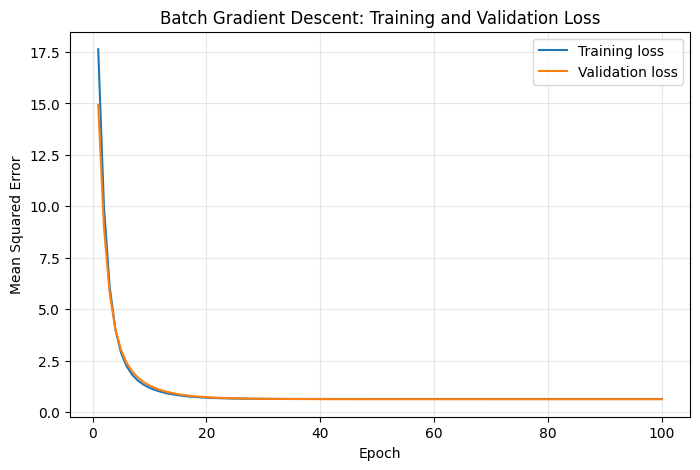

In [25]:
plot_losses(
    batch_gd_history,
    title=(
        "Batch Gradient Descent: "
        "Training and Validation Loss"
    ),
)

In [26]:
def plot_gradient_norms(
    history,
    title,
):
    """
    Plot the global gradient norm
    over training epochs.
    """

    epochs = np.arange(
        1,
        len(
            history[
                "gradient_norm"
            ]
        ) + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs,
        history[
            "gradient_norm"
        ],
    )


    plt.xlabel("Epoch")

    plt.ylabel(
        "Global Gradient L2 Norm"
    )

    plt.title(title)

    plt.grid(
        alpha=0.3
    )

    plt.show()

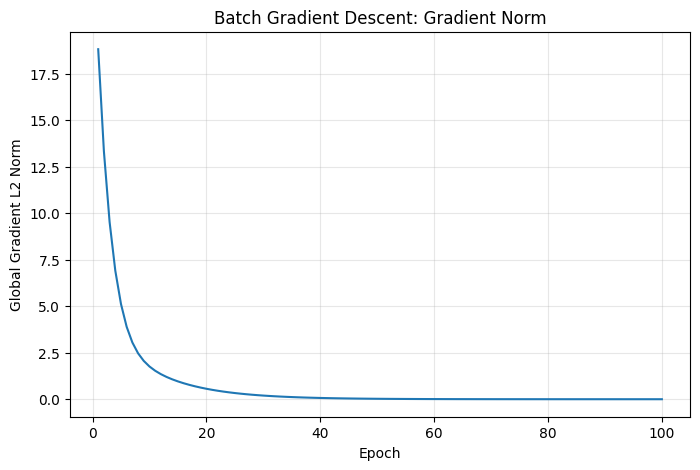

In [27]:
plot_gradient_norms(
    batch_gd_history,
    title=(
        "Batch Gradient Descent: "
        "Gradient Norm"
    ),
)

In [28]:
def plot_learning_rates(
    history,
    title,
):
    """
    Plot the learning rate used
    during training.
    """

    epochs = np.arange(
        1,
        len(
            history[
                "learning_rate"
            ]
        ) + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs,
        history[
            "learning_rate"
        ],
    )


    plt.xlabel("Epoch")

    plt.ylabel(
        "Learning Rate"
    )

    plt.title(title)

    plt.grid(
        alpha=0.3
    )

    plt.show()

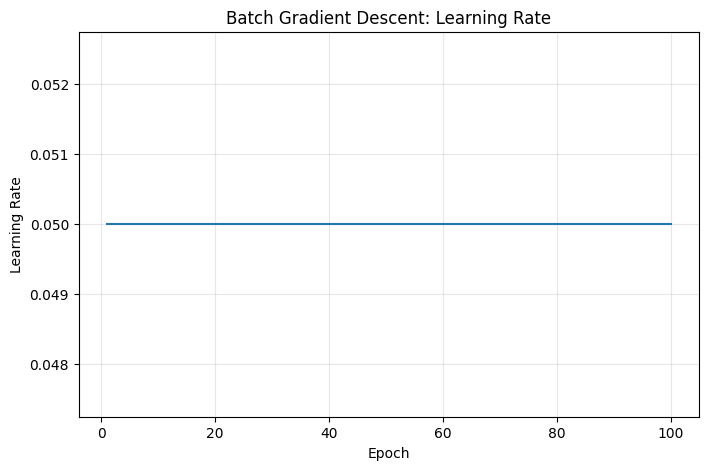

In [29]:
plot_learning_rates(
    batch_gd_history,
    title=(
        "Batch Gradient Descent: "
        "Learning Rate"
    ),
)

In [30]:
def plot_regression_fit(
    X_train,
    y_train,
    X_validation,
    y_validation,
    weight,
    bias,
):
    """
    Plot the dataset and the learned
    regression line.
    """

    x_line = np.linspace(
        X_train.min(),
        X_train.max(),
        200,
    ).reshape(-1, 1)


    y_line = linear_model(
        x_line,
        weight,
        bias,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.scatter(
        X_train,
        y_train,
        alpha=0.6,
        label="Training data",
    )


    plt.scatter(
        X_validation,
        y_validation,
        alpha=0.7,
        label="Validation data",
    )


    plt.plot(
        x_line,
        y_line,
        linewidth=2,
        label="Learned regression line",
    )


    plt.xlabel("x")

    plt.ylabel("y")

    plt.title(
        "Linear Regression Fit"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()

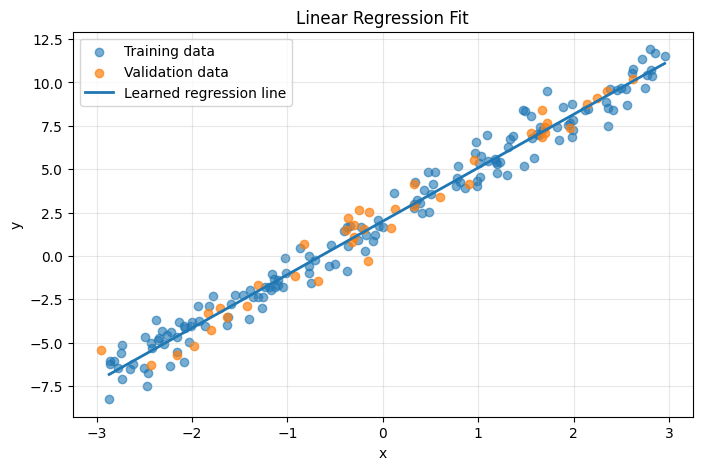

In [31]:
plot_regression_fit(
    X_train,
    y_train,
    X_validation,
    y_validation,
    weight=(
        batch_gd_parameters[
            "weight"
        ]
    ),
    bias=(
        batch_gd_parameters[
            "bias"
        ]
    ),
)

In [32]:
def plot_parameter_trajectory(
    history,
    title,
):
    """
    Plot the path followed by weight and bias
    during optimization.
    """

    weights = np.array(
        history["weight"]
    )

    biases = np.array(
        history["bias"]
    )


    plt.figure(
        figsize=(8, 6)
    )


    plt.plot(
        weights,
        biases,
        marker="o",
        markersize=3,
        linewidth=1.5,
    )


    plt.scatter(
        weights[0],
        biases[0],
        s=100,
        label="Starting point",
    )


    plt.scatter(
        weights[-1],
        biases[-1],
        s=100,
        marker="X",
        label="Final point",
    )


    plt.xlabel("Weight")

    plt.ylabel("Bias")

    plt.title(title)

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()

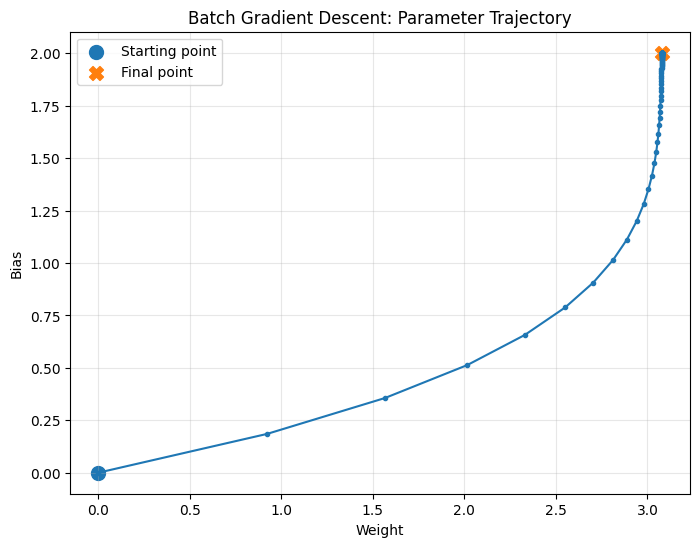

In [33]:
plot_parameter_trajectory(
    batch_gd_history,
    title=(
        "Batch Gradient Descent: "
        "Parameter Trajectory"
    ),
)

In [34]:
assert (
    batch_gd_history[
        "train_loss"
    ][-1]
    <
    batch_gd_history[
        "train_loss"
    ][0]
)


assert np.isclose(
    batch_gd_parameters[
        "weight"
    ].item(),
    3.0,
    atol=0.3,
)


assert np.isclose(
    batch_gd_parameters[
        "bias"
    ].item(),
    2.0,
    atol=0.3,
)


assert (
    batch_gd_optimizer.step_count
    == 100
)


print(
    "All Batch Gradient "
    "Descent checks passed."
)

All Batch Gradient Descent checks passed.


# Part 3: Mini-Batch Stochastic Gradient Descent

Mini-Batch SGD divides the training dataset into small batches.

For every mini-batch $\mathcal{B}$:

$$
g_t
=
\frac{1}{|\mathcal{B}|}
\sum_{i \in \mathcal{B}}
\nabla_\theta L_i
$$

The parameters are then updated using:

$$
\theta_{t+1}
=
\theta_t
-
\eta g_t
$$

Compared with Batch Gradient Descent:

- gradients are computed using fewer examples;
- several parameter updates occur during each epoch;
- gradient estimates are noisier;
- training is usually more computationally practical for large datasets.

In [35]:
def create_mini_batches(
    X,
    y,
    batch_size,
    shuffle=True,
    rng=None,
):
    """
    Yield mini-batches of X and y.

    Parameters
    ----------
    X:
        Input features.

    y:
        Target values.

    batch_size:
        Maximum number of examples
        in one mini-batch.

    shuffle:
        Whether to randomly reorder
        examples before creating batches.

    rng:
        NumPy random-number generator.
    """

    if batch_size <= 0:
        raise ValueError(
            "batch_size must be "
            "greater than zero."
        )

    if len(X) != len(y):
        raise ValueError(
            "X and y must contain "
            "the same number of examples."
        )

    if rng is None:
        rng = np.random.default_rng()


    n_samples = len(X)


    # Create indices:
    #
    # [0, 1, 2, ..., n_samples - 1]

    indices = np.arange(
        n_samples
    )


    # Randomize the example order.

    if shuffle:

        rng.shuffle(
            indices
        )


    # Move through the dataset
    # batch_size examples at a time.

    for start_index in range(
        0,
        n_samples,
        batch_size,
    ):

        end_index = (
            start_index
            + batch_size
        )


        batch_indices = indices[
            start_index:end_index
        ]


        X_batch = X[
            batch_indices
        ]

        y_batch = y[
            batch_indices
        ]


        yield (
            X_batch,
            y_batch,
        )

In [36]:
test_rng = np.random.default_rng(
    seed=42
)


test_batches = list(
    create_mini_batches(
        X=X_train,
        y=y_train,
        batch_size=16,
        shuffle=True,
        rng=test_rng,
    )
)


print(
    "Number of training examples:",
    len(X_train),
)

print(
    "Batch size:",
    16,
)

print(
    "Number of mini-batches:",
    len(test_batches),
)


print("\nMini-batch shapes:")

for batch_number, (
    X_batch,
    y_batch,
) in enumerate(
    test_batches,
    start=1,
):

    print(
        f"Batch {batch_number:2d}: "
        f"X = {X_batch.shape}, "
        f"y = {y_batch.shape}"
    )

Number of training examples: 160
Batch size: 16
Number of mini-batches: 10

Mini-batch shapes:
Batch  1: X = (16, 1), y = (16, 1)
Batch  2: X = (16, 1), y = (16, 1)
Batch  3: X = (16, 1), y = (16, 1)
Batch  4: X = (16, 1), y = (16, 1)
Batch  5: X = (16, 1), y = (16, 1)
Batch  6: X = (16, 1), y = (16, 1)
Batch  7: X = (16, 1), y = (16, 1)
Batch  8: X = (16, 1), y = (16, 1)
Batch  9: X = (16, 1), y = (16, 1)
Batch 10: X = (16, 1), y = (16, 1)


In [37]:
uneven_batches = list(
    create_mini_batches(
        X=X_train,
        y=y_train,
        batch_size=24,
        shuffle=False,
    )
)


print(
    "Number of batches:",
    len(uneven_batches),
)


print(
    "Batch sizes:",
    [
        len(X_batch)
        for X_batch, _ in uneven_batches
    ],
)

Number of batches: 7
Batch sizes: [24, 24, 24, 24, 24, 24, 16]


In [38]:
class SGD(NumPyOptimizer):
    """
    Stochastic Gradient Descent.

    Update rule:

        parameter =
            parameter
            - learning_rate * gradient

    The optimizer itself does not determine
    whether training is:

    - full-batch Gradient Descent;
    - Mini-Batch SGD;
    - single-example SGD.

    That depends on how the training loop
    computes each gradient.
    """

    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        for name in parameters:

            parameters[name] -= (
                self.learning_rate
                * gradients[name]
            )


        self.step_count += 1

In [39]:
def create_sgd_history():
    """
    Create a history dictionary for
    Mini-Batch SGD training.
    """

    history = {
        "train_loss": [],
        "validation_loss": [],

        "gradient_norm": [],

        "mean_batch_gradient_norm": [],

        "learning_rate": [],

        "weight": [],
        "bias": [],

        "update_weight": [],
        "update_bias": [],

        "update_gradient_norm": [],

        "updates_per_epoch": [],
    }

    return history

In [40]:
def train_linear_regression_sgd(
    X_train,
    y_train,
    X_validation,
    y_validation,
    optimizer,
    epochs=100,
    batch_size=16,
    initial_weight=0.0,
    initial_bias=0.0,
    shuffle=True,
    seed=42,
    print_every=10,
):
    """
    Train linear regression using
    Mini-Batch SGD.

    During every epoch:

    1. Shuffle the training examples.
    2. Divide them into mini-batches.
    3. Compute one gradient per mini-batch.
    4. Update parameters after every batch.
    5. Evaluate the complete training and
       validation datasets after the epoch.
    """

    parameters = {

        "weight": np.array(
            [[initial_weight]],
            dtype=np.float64,
        ),

        "bias": np.array(
            [[initial_bias]],
            dtype=np.float64,
        ),
    }


    history = create_sgd_history()


    # Random-number generator used
    # for reproducible shuffling.

    rng = np.random.default_rng(
        seed=seed
    )


    # Save the initial parameters
    # in both trajectories.

    history["weight"].append(
        parameters[
            "weight"
        ].item()
    )

    history["bias"].append(
        parameters[
            "bias"
        ].item()
    )


    history[
        "update_weight"
    ].append(
        parameters[
            "weight"
        ].item()
    )

    history[
        "update_bias"
    ].append(
        parameters[
            "bias"
        ].item()
    )


    # ===================================
    # Training epochs
    # ===================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        batch_gradient_norms = []

        updates_this_epoch = 0


        # -------------------------------
        # Create mini-batches
        # -------------------------------

        mini_batches = (
            create_mini_batches(
                X=X_train,
                y=y_train,
                batch_size=batch_size,
                shuffle=shuffle,
                rng=rng,
            )
        )


        # -------------------------------
        # Process one mini-batch
        # at a time
        # -------------------------------

        for (
            X_batch,
            y_batch,
        ) in mini_batches:


            # Forward pass using only
            # the current mini-batch.

            batch_predictions = (
                linear_model(
                    X_batch,
                    parameters[
                        "weight"
                    ],
                    parameters[
                        "bias"
                    ],
                )
            )


            # Compute gradients using
            # only the current batch.

            (
                weight_gradient,
                bias_gradient,
            ) = (
                linear_regression_gradients(
                    X_batch,
                    batch_predictions,
                    y_batch,
                )
            )


            gradients = {

                "weight":
                    weight_gradient,

                "bias":
                    bias_gradient,
            }


            # Measure the gradient
            # before updating.

            batch_gradient_norm = (
                compute_global_gradient_norm(
                    gradients
                )
            )


            batch_gradient_norms.append(
                batch_gradient_norm
            )


            history[
                "update_gradient_norm"
            ].append(
                batch_gradient_norm
            )


            # Update parameters.

            optimizer.step(
                parameters,
                gradients,
            )


            updates_this_epoch += 1


            # Save parameters after
            # every optimizer update.

            history[
                "update_weight"
            ].append(
                parameters[
                    "weight"
                ].item()
            )


            history[
                "update_bias"
            ].append(
                parameters[
                    "bias"
                ].item()
            )


        # ===================================
        # End-of-epoch evaluation
        # ===================================


        # Compute training predictions
        # using the complete training set.

        train_predictions = (
            linear_model(
                X_train,
                parameters[
                    "weight"
                ],
                parameters[
                    "bias"
                ],
            )
        )


        train_loss = (
            mean_squared_error(
                train_predictions,
                y_train,
            )
        )


        # Compute validation loss.

        validation_predictions = (
            linear_model(
                X_validation,
                parameters[
                    "weight"
                ],
                parameters[
                    "bias"
                ],
            )
        )


        validation_loss = (
            mean_squared_error(
                validation_predictions,
                y_validation,
            )
        )


        # Compute the complete training-set
        # gradient after the epoch.

        (
            full_weight_gradient,
            full_bias_gradient,
        ) = (
            linear_regression_gradients(
                X_train,
                train_predictions,
                y_train,
            )
        )


        full_gradients = {

            "weight":
                full_weight_gradient,

            "bias":
                full_bias_gradient,
        }


        full_gradient_norm = (
            compute_global_gradient_norm(
                full_gradients
            )
        )


        mean_batch_gradient_norm = (
            float(
                np.mean(
                    batch_gradient_norms
                )
            )
        )


        # ===================================
        # Save epoch-level metrics
        # ===================================

        history[
            "train_loss"
        ].append(
            train_loss
        )


        history[
            "validation_loss"
        ].append(
            validation_loss
        )


        history[
            "gradient_norm"
        ].append(
            full_gradient_norm
        )


        history[
            "mean_batch_gradient_norm"
        ].append(
            mean_batch_gradient_norm
        )


        history[
            "learning_rate"
        ].append(
            optimizer.learning_rate
        )


        history[
            "weight"
        ].append(
            parameters[
                "weight"
            ].item()
        )


        history[
            "bias"
        ].append(
            parameters[
                "bias"
            ].item()
        )


        history[
            "updates_per_epoch"
        ].append(
            updates_this_epoch
        )


        # ===================================
        # Print progress
        # ===================================

        if (
            epoch == 1
            or epoch % print_every == 0
            or epoch == epochs
        ):

            print(
                f"Epoch {epoch:4d} | "
                f"Train loss: "
                f"{train_loss:.6f} | "
                f"Validation loss: "
                f"{validation_loss:.6f} | "
                f"Full gradient norm: "
                f"{full_gradient_norm:.6f} | "
                f"Updates: "
                f"{updates_this_epoch}"
            )


    return parameters, history

In [41]:
sgd_optimizer = SGD(
    learning_rate=0.01
)


sgd_parameters, sgd_history = (
    train_linear_regression_sgd(

        X_train=X_train,

        y_train=y_train,

        X_validation=(
            X_validation
        ),

        y_validation=(
            y_validation
        ),

        optimizer=(
            sgd_optimizer
        ),

        epochs=100,

        batch_size=16,

        initial_weight=0.0,

        initial_bias=0.0,

        shuffle=True,

        seed=42,

        print_every=10,
    )
)

Epoch    1 | Train loss: 11.448654 | Validation loss: 10.075854 | Full gradient norm: 10.375915 | Updates: 10
Epoch   10 | Train loss: 0.717127 | Validation loss: 0.747101 | Full gradient norm: 0.556940 | Updates: 10
Epoch   20 | Train loss: 0.641471 | Validation loss: 0.635558 | Full gradient norm: 0.076846 | Updates: 10
Epoch   30 | Train loss: 0.640028 | Validation loss: 0.629622 | Full gradient norm: 0.011921 | Updates: 10
Epoch   40 | Train loss: 0.640066 | Validation loss: 0.630029 | Full gradient norm: 0.029880 | Updates: 10
Epoch   50 | Train loss: 0.640088 | Validation loss: 0.627447 | Full gradient norm: 0.033906 | Updates: 10
Epoch   60 | Train loss: 0.640076 | Validation loss: 0.630277 | Full gradient norm: 0.031746 | Updates: 10
Epoch   70 | Train loss: 0.640062 | Validation loss: 0.629854 | Full gradient norm: 0.028751 | Updates: 10
Epoch   80 | Train loss: 0.640047 | Validation loss: 0.627840 | Full gradient norm: 0.025519 | Updates: 10
Epoch   90 | Train loss: 0.640029 

In [42]:
print(
    "\nTrue weight:    "
    "3.0000"
)

print(
    "Learned weight: "
    f"{sgd_parameters['weight'].item():.4f}"
)


print(
    "\nTrue bias:      "
    "2.0000"
)

print(
    "Learned bias:   "
    f"{sgd_parameters['bias'].item():.4f}"
)


print(
    "\nTotal optimizer updates:",
    sgd_optimizer.step_count,
)


True weight:    3.0000
Learned weight: 3.0737

True bias:      2.0000
Learned bias:   2.0049

Total optimizer updates: 1000


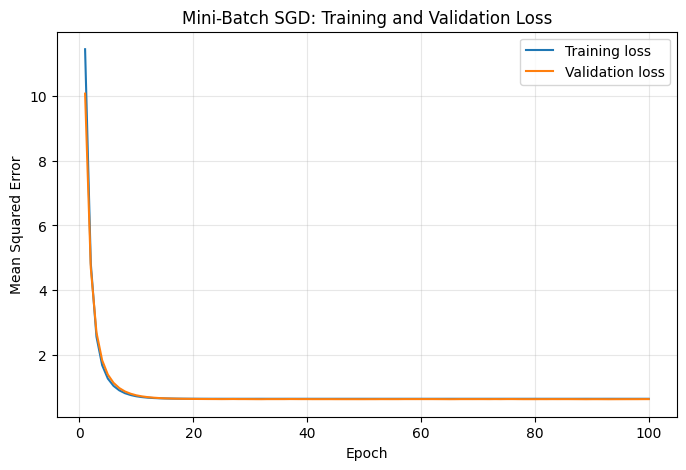

In [43]:
plot_losses(
    sgd_history,
    title=(
        "Mini-Batch SGD: "
        "Training and Validation Loss"
    ),
)

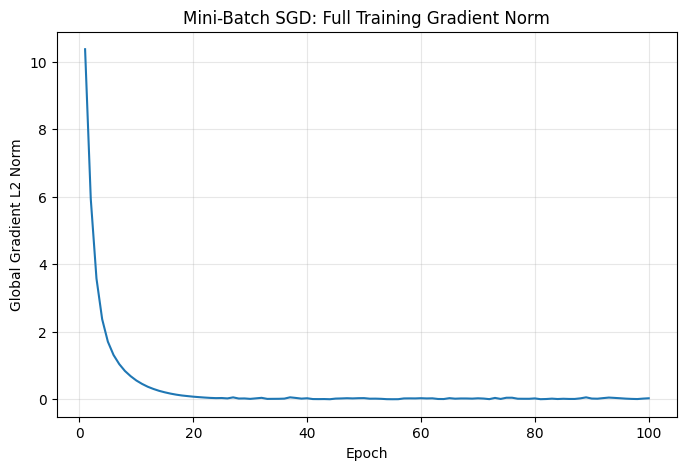

In [44]:
plot_gradient_norms(
    sgd_history,
    title=(
        "Mini-Batch SGD: "
        "Full Training Gradient Norm"
    ),
)

In [45]:
def plot_sgd_gradient_norms(
    history,
    title,
):
    """
    Compare:

    1. Full training-set gradient norm.
    2. Mean mini-batch gradient norm.
    """

    epochs = np.arange(
        1,
        len(
            history[
                "gradient_norm"
            ]
        ) + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs,

        history[
            "gradient_norm"
        ],

        label=(
            "Full training "
            "gradient norm"
        ),
    )


    plt.plot(
        epochs,

        history[
            "mean_batch_gradient_norm"
        ],

        label=(
            "Mean mini-batch "
            "gradient norm"
        ),
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Gradient L2 Norm"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

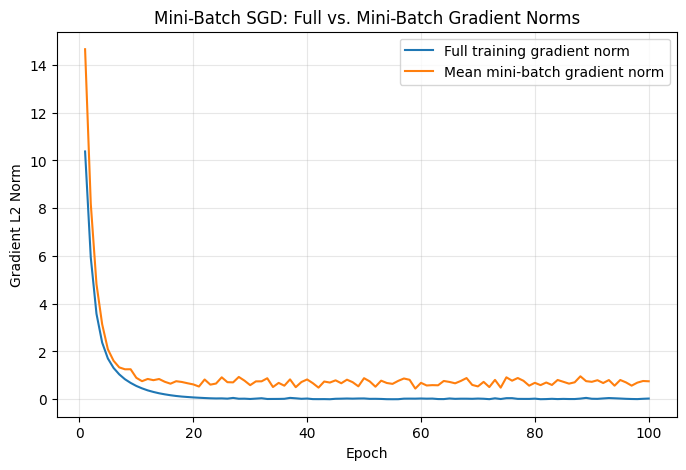

In [46]:
plot_sgd_gradient_norms(
    sgd_history,
    title=(
        "Mini-Batch SGD: "
        "Full vs. Mini-Batch "
        "Gradient Norms"
    ),
)

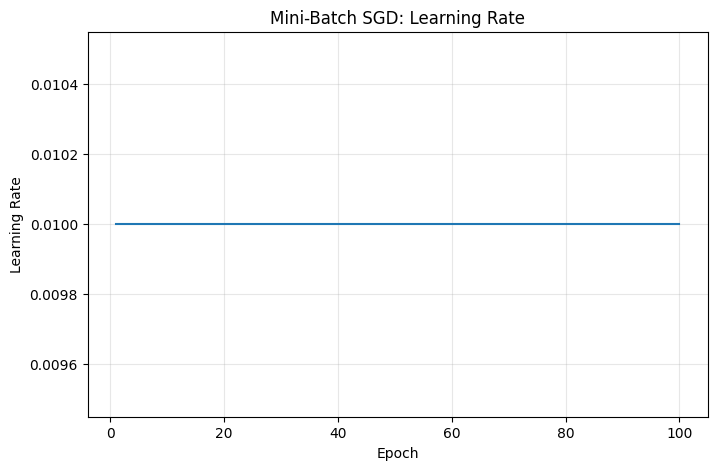

In [47]:
plot_learning_rates(
    sgd_history,
    title=(
        "Mini-Batch SGD: "
        "Learning Rate"
    ),
)

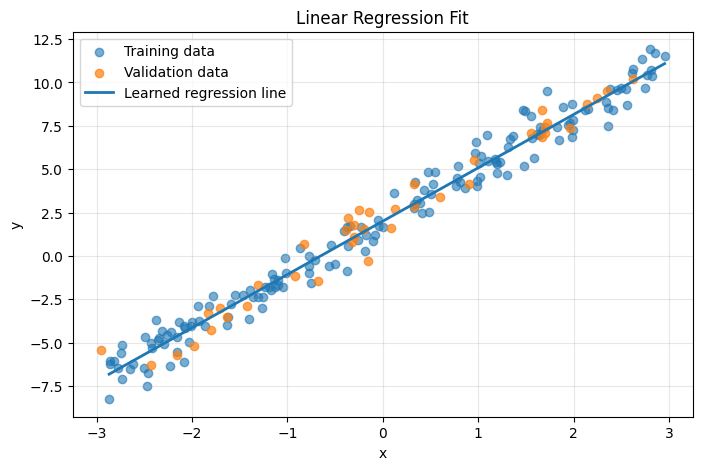

In [48]:
plot_regression_fit(

    X_train,

    y_train,

    X_validation,

    y_validation,

    weight=(
        sgd_parameters[
            "weight"
        ]
    ),

    bias=(
        sgd_parameters[
            "bias"
        ]
    ),
)

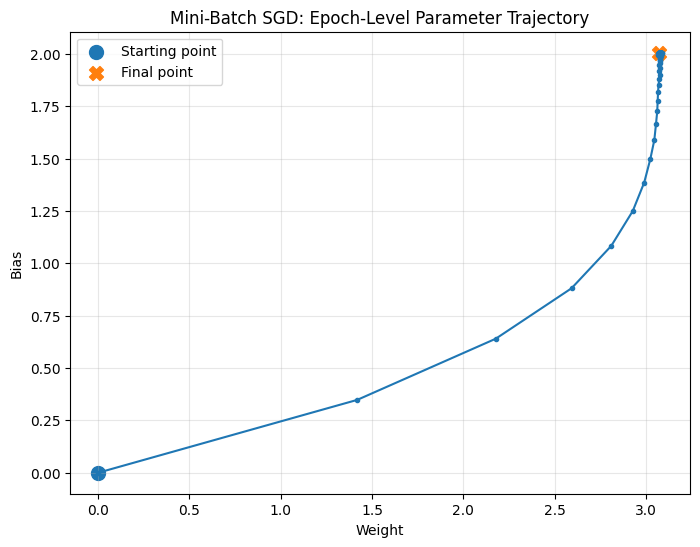

In [49]:
plot_parameter_trajectory(
    sgd_history,
    title=(
        "Mini-Batch SGD: "
        "Epoch-Level "
        "Parameter Trajectory"
    ),
)

In [50]:
def plot_update_trajectory(
    history,
    title,
):
    """
    Plot parameters after every
    optimizer update.
    """

    weights = np.array(
        history[
            "update_weight"
        ]
    )


    biases = np.array(
        history[
            "update_bias"
        ]
    )


    plt.figure(
        figsize=(8, 6)
    )


    plt.plot(
        weights,
        biases,
        linewidth=1.0,
        alpha=0.8,
    )


    plt.scatter(
        weights[0],
        biases[0],
        s=100,
        label="Starting point",
    )


    plt.scatter(
        weights[-1],
        biases[-1],
        s=100,
        marker="X",
        label="Final point",
    )


    plt.xlabel(
        "Weight"
    )


    plt.ylabel(
        "Bias"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

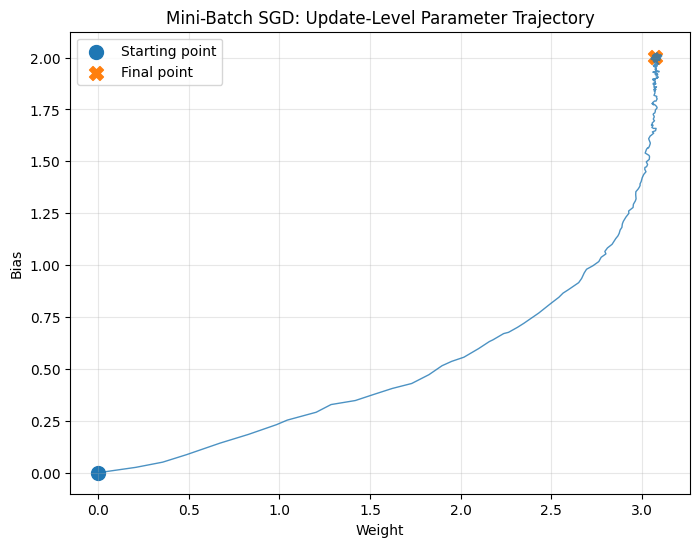

In [51]:
plot_update_trajectory(
    sgd_history,
    title=(
        "Mini-Batch SGD: "
        "Update-Level "
        "Parameter Trajectory"
    ),
)

In [52]:
def compare_loss_histories(
    histories,
    labels,
    title,
):
    """
    Compare training losses from
    multiple optimization runs.
    """

    plt.figure(
        figsize=(9, 5)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        epochs = np.arange(
            1,
            len(
                history[
                    "train_loss"
                ]
            ) + 1,
        )


        plt.plot(
            epochs,

            history[
                "train_loss"
            ],

            label=label,
        )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Training MSE"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

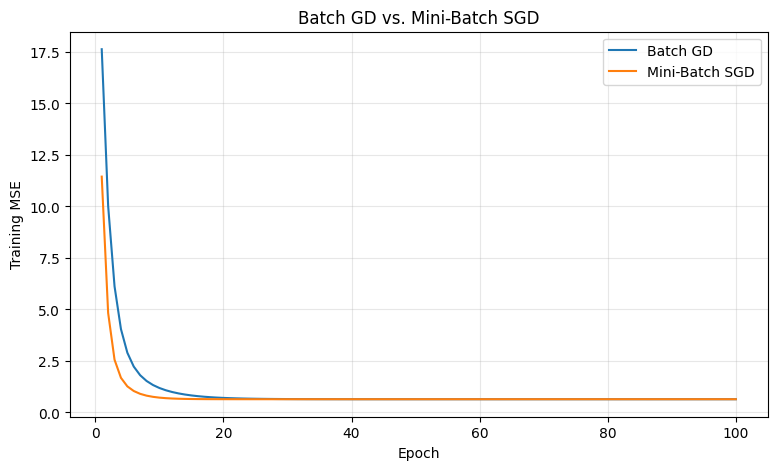

In [53]:
compare_loss_histories(

    histories=[
        batch_gd_history,
        sgd_history,
    ],

    labels=[
        "Batch GD",
        "Mini-Batch SGD",
    ],

    title=(
        "Batch GD vs. "
        "Mini-Batch SGD"
    ),
)

In [54]:
print(
    "Batch Gradient Descent"
)

print(
    "----------------------"
)

print(
    f"Weight: "
    f"{batch_gd_parameters['weight'].item():.4f}"
)

print(
    f"Bias:   "
    f"{batch_gd_parameters['bias'].item():.4f}"
)

print(
    f"Final training loss: "
    f"{batch_gd_history['train_loss'][-1]:.6f}"
)

print(
    f"Optimizer updates: "
    f"{batch_gd_optimizer.step_count}"
)


print(
    "\nMini-Batch SGD"
)

print(
    "--------------"
)

print(
    f"Weight: "
    f"{sgd_parameters['weight'].item():.4f}"
)

print(
    f"Bias:   "
    f"{sgd_parameters['bias'].item():.4f}"
)

print(
    f"Final training loss: "
    f"{sgd_history['train_loss'][-1]:.6f}"
)

print(
    f"Optimizer updates: "
    f"{sgd_optimizer.step_count}"
)

Batch Gradient Descent
----------------------
Weight: 3.0785
Bias:   2.0027
Final training loss: 0.639993
Optimizer updates: 100

Mini-Batch SGD
--------------
Weight: 3.0737
Bias:   2.0049
Final training loss: 0.640067
Optimizer updates: 1000


In [55]:
expected_updates_per_epoch = (
    int(
        np.ceil(
            len(X_train)
            / 16
        )
    )
)


expected_total_updates = (
    100
    * expected_updates_per_epoch
)


assert (
    sgd_history[
        "train_loss"
    ][-1]
    <
    sgd_history[
        "train_loss"
    ][0]
)


assert np.isclose(
    sgd_parameters[
        "weight"
    ].item(),
    3.0,
    atol=0.3,
)


assert np.isclose(
    sgd_parameters[
        "bias"
    ].item(),
    2.0,
    atol=0.3,
)


assert (
    sgd_optimizer.step_count
    ==
    expected_total_updates
)


assert all(
    number_of_updates
    ==
    expected_updates_per_epoch

    for number_of_updates
    in sgd_history[
        "updates_per_epoch"
    ]
)


assert (
    len(
        sgd_history[
            "update_weight"
        ]
    )
    ==
    expected_total_updates + 1
)


print(
    "All Mini-Batch SGD "
    "checks passed."
)

All Mini-Batch SGD checks passed.


# Part 4: SGD with Momentum

Ordinary SGD uses only the current gradient:

$$
\theta_{t+1}
=
\theta_t
-
\eta g_t
$$

Momentum maintains a velocity:

$$
v_t
=
\beta v_{t-1}
+
g_t
$$

The parameters are updated using:

$$
\theta_{t+1}
=
\theta_t
-
\eta v_t
$$

where:

- $\eta$ is the learning rate;
- $\beta$ is the momentum coefficient;
- $g_t$ is the current gradient;
- $v_t$ contains information from current and previous gradients.

The velocity is initialized to zero.

In [57]:
class SGDMomentum(NumPyOptimizer):
    """
    Stochastic Gradient Descent with Momentum.

    Velocity update:

        velocity =
            momentum * velocity
            + gradient

    Parameter update:

        parameter =
            parameter
            - learning_rate * velocity
    """

    def __init__(
        self,
        learning_rate,
        momentum=0.9,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= momentum < 1.0:

            raise ValueError(
                "momentum must satisfy "
                "0 <= momentum < 1."
            )


        self.momentum = momentum

        self.velocity = {}


    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        for name in parameters:


            # Initialize velocity during
            # the first optimizer step.

            if name not in self.velocity:

                self.velocity[name] = (
                    np.zeros_like(
                        parameters[name]
                    )
                )


            # Update velocity.

            self.velocity[name] = (

                self.momentum
                * self.velocity[name]

                + gradients[name]
            )


            # Update parameter.

            parameters[name] -= (

                self.learning_rate

                * self.velocity[name]
            )


        self.step_count += 1

In [58]:
test_parameters = {

    "weight": np.array(
        [[0.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[0.0]],
        dtype=np.float64,
    ),
}


test_gradients = {

    "weight": np.array(
        [[-4.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[-2.0]],
        dtype=np.float64,
    ),
}


test_momentum_optimizer = (
    SGDMomentum(
        learning_rate=0.1,
        momentum=0.9,
    )
)


test_momentum_optimizer.step(
    test_parameters,
    test_gradients,
)


print(
    "Weight velocity:",
    test_momentum_optimizer.velocity[
        "weight"
    ].item(),
)

print(
    "Bias velocity:",
    test_momentum_optimizer.velocity[
        "bias"
    ].item(),
)


print(
    "\nUpdated weight:",
    test_parameters[
        "weight"
    ].item(),
)

print(
    "Updated bias:",
    test_parameters[
        "bias"
    ].item(),
)

Weight velocity: -4.0
Bias velocity: -2.0

Updated weight: 0.4
Updated bias: 0.2


In [59]:
second_gradients = {

    "weight": np.array(
        [[-3.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[-1.0]],
        dtype=np.float64,
    ),
}


test_momentum_optimizer.step(
    test_parameters,
    second_gradients,
)


print(
    "Weight velocity:",
    test_momentum_optimizer.velocity[
        "weight"
    ].item(),
)

print(
    "Bias velocity:",
    test_momentum_optimizer.velocity[
        "bias"
    ].item(),
)


print(
    "\nUpdated weight:",
    test_parameters[
        "weight"
    ].item(),
)

print(
    "Updated bias:",
    test_parameters[
        "bias"
    ].item(),
)

Weight velocity: -6.6
Bias velocity: -2.8

Updated weight: 1.06
Updated bias: 0.48


In [60]:
assert np.isclose(

    test_momentum_optimizer.velocity[
        "weight"
    ].item(),

    -6.6,
)


assert np.isclose(

    test_momentum_optimizer.velocity[
        "bias"
    ].item(),

    -2.8,
)


assert np.isclose(

    test_parameters[
        "weight"
    ].item(),

    1.06,
)


assert np.isclose(

    test_parameters[
        "bias"
    ].item(),

    0.48,
)


assert (
    test_momentum_optimizer.step_count
    == 2
)


print(
    "Manual Momentum checks passed."
)

Manual Momentum checks passed.


In [61]:
momentum_optimizer = (
    SGDMomentum(
        learning_rate=0.01,
        momentum=0.9,
    )
)

(
    momentum_parameters,
    momentum_history,
) = train_linear_regression_sgd(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        momentum_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 6.466460 | Validation loss: 4.581388 | Full gradient norm: 8.206696 | Updates: 10
Epoch   10 | Train loss: 0.649614 | Validation loss: 0.656174 | Full gradient norm: 0.309941 | Updates: 10
Epoch   20 | Train loss: 0.643845 | Validation loss: 0.629453 | Full gradient norm: 0.188820 | Updates: 10
Epoch   30 | Train loss: 0.641155 | Validation loss: 0.635389 | Full gradient norm: 0.117737 | Updates: 10
Epoch   40 | Train loss: 0.642380 | Validation loss: 0.625595 | Full gradient norm: 0.164701 | Updates: 10
Epoch   50 | Train loss: 0.644791 | Validation loss: 0.618808 | Full gradient norm: 0.218335 | Updates: 10
Epoch   60 | Train loss: 0.640046 | Validation loss: 0.628122 | Full gradient norm: 0.024513 | Updates: 10
Epoch   70 | Train loss: 0.640087 | Validation loss: 0.630586 | Full gradient norm: 0.032973 | Updates: 10
Epoch   80 | Train loss: 0.640475 | Validation loss: 0.630149 | Full gradient norm: 0.054262 | Updates: 10
Epoch   90 | Train loss: 0.641158 | V

In [62]:
print(
    "\nTrue weight:    "
    "3.0000"
)

print(
    "Learned weight: "
    f"{momentum_parameters['weight'].item():.4f}"
)


print(
    "\nTrue bias:      "
    "2.0000"
)

print(
    "Learned bias:   "
    f"{momentum_parameters['bias'].item():.4f}"
)


print(
    "\nTotal optimizer updates:",
    momentum_optimizer.step_count,
)


True weight:    3.0000
Learned weight: 3.0903

True bias:      2.0000
Learned bias:   2.0202

Total optimizer updates: 1000


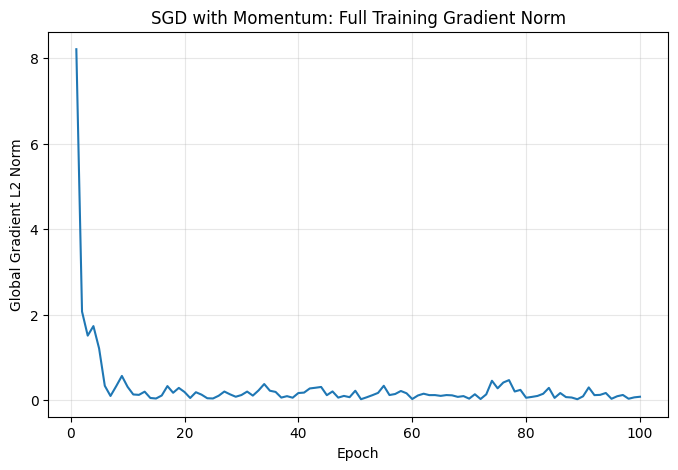

In [63]:
plot_gradient_norms(
    momentum_history,
    title=(
        "SGD with Momentum: "
        "Full Training Gradient Norm"
    ),
)

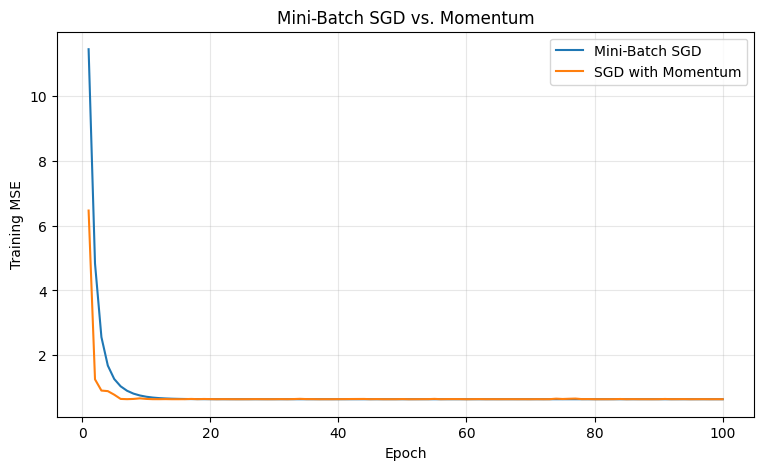

In [64]:
compare_loss_histories(

    histories=[
        sgd_history,
        momentum_history,
    ],

    labels=[
        "Mini-Batch SGD",
        "SGD with Momentum",
    ],

    title=(
        "Mini-Batch SGD "
        "vs. Momentum"
    ),
)

In [65]:
def compare_gradient_norm_histories(
    histories,
    labels,
    title,
):
    """
    Compare full training gradient norms
    from multiple optimization runs.
    """

    plt.figure(
        figsize=(9, 5)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        epochs = np.arange(
            1,
            len(
                history[
                    "gradient_norm"
                ]
            ) + 1,
        )


        plt.plot(

            epochs,

            history[
                "gradient_norm"
            ],

            label=label,
        )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Full Gradient L2 Norm"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

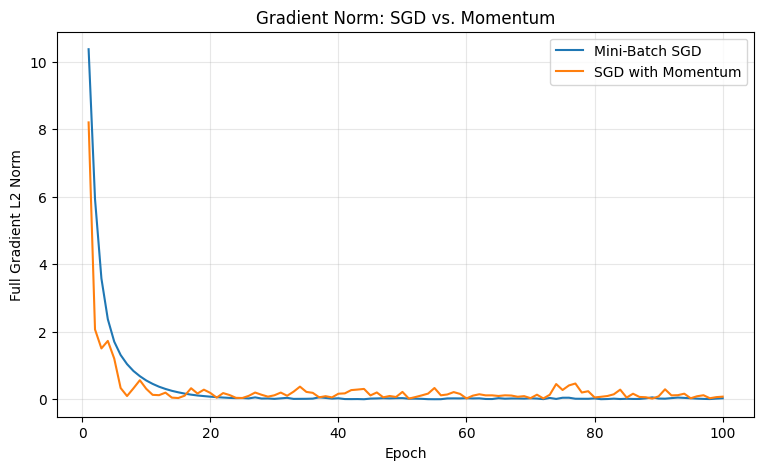

In [66]:
compare_gradient_norm_histories(

    histories=[
        sgd_history,
        momentum_history,
    ],

    labels=[
        "Mini-Batch SGD",
        "SGD with Momentum",
    ],

    title=(
        "Gradient Norm: "
        "SGD vs. Momentum"
    ),
)

In [67]:
def compare_update_trajectories(
    histories,
    labels,
    title,
):
    """
    Compare update-level parameter
    trajectories.
    """

    plt.figure(
        figsize=(9, 7)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        weights = np.array(
            history[
                "update_weight"
            ]
        )


        biases = np.array(
            history[
                "update_bias"
            ]
        )


        plt.plot(

            weights,

            biases,

            linewidth=1.2,

            alpha=0.8,

            label=label,
        )


        # Final point

        plt.scatter(

            weights[-1],

            biases[-1],

            marker="X",

            s=80,
        )


    # Both runs begin at the
    # same initial parameters.

    initial_weight = (
        histories[0][
            "update_weight"
        ][0]
    )


    initial_bias = (
        histories[0][
            "update_bias"
        ][0]
    )


    plt.scatter(

        initial_weight,

        initial_bias,

        s=120,

        label="Starting point",
    )


    plt.xlabel(
        "Weight"
    )


    plt.ylabel(
        "Bias"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

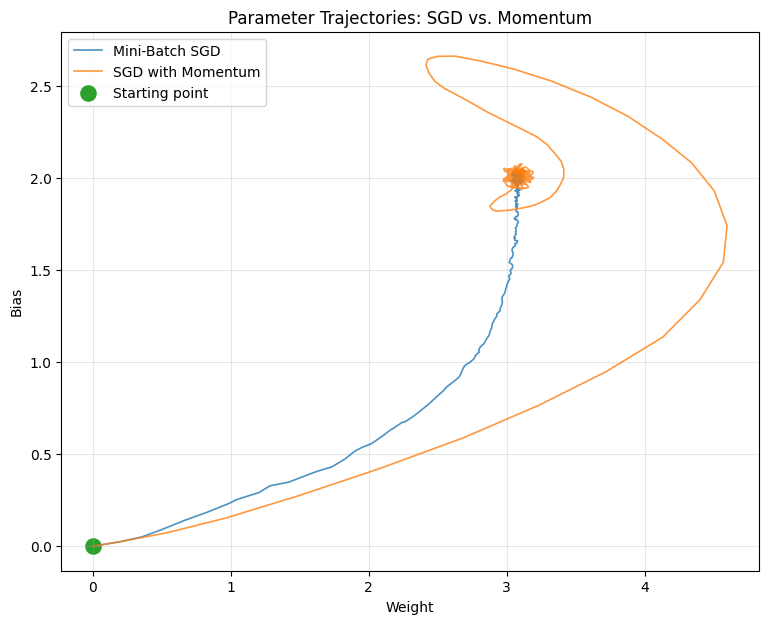

In [68]:
compare_update_trajectories(

    histories=[
        sgd_history,
        momentum_history,
    ],

    labels=[
        "Mini-Batch SGD",
        "SGD with Momentum",
    ],

    title=(
        "Parameter Trajectories: "
        "SGD vs. Momentum"
    ),
)

In [69]:
print(
    "Final weight velocity:"
)

print(
    momentum_optimizer.velocity[
        "weight"
    ]
)


print(
    "\nFinal bias velocity:"
)

print(
    momentum_optimizer.velocity[
        "bias"
    ]
)

Final weight velocity:
[[0.42988808]]

Final bias velocity:
[[0.25373584]]


In [70]:
ordinary_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


zero_momentum_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


comparison_gradients = {

    "weight": np.array(
        [[2.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[-3.0]],
        dtype=np.float64,
    ),
}


ordinary_optimizer = SGD(
    learning_rate=0.1
)


zero_momentum_optimizer = (
    SGDMomentum(
        learning_rate=0.1,
        momentum=0.0,
    )
)


ordinary_optimizer.step(
    ordinary_parameters,
    comparison_gradients,
)


zero_momentum_optimizer.step(
    zero_momentum_parameters,
    comparison_gradients,
)


print(
    "Ordinary SGD parameters:"
)

print(
    ordinary_parameters
)


print(
    "\nMomentum with beta = 0:"
)

print(
    zero_momentum_parameters
)

Ordinary SGD parameters:
{'weight': array([[0.8]]), 'bias': array([[1.3]])}

Momentum with beta = 0:
{'weight': array([[0.8]]), 'bias': array([[1.3]])}


In [71]:
assert np.allclose(

    ordinary_parameters[
        "weight"
    ],

    zero_momentum_parameters[
        "weight"
    ],
)


assert np.allclose(

    ordinary_parameters[
        "bias"
    ],

    zero_momentum_parameters[
        "bias"
    ],
)


print(
    "Momentum with beta = 0 "
    "matches ordinary SGD."
)

Momentum with beta = 0 matches ordinary SGD.


In [72]:
expected_updates_per_epoch = (
    int(
        np.ceil(
            len(X_train)
            / 16
        )
    )
)


expected_total_updates = (
    100
    * expected_updates_per_epoch
)


assert (
    momentum_history[
        "train_loss"
    ][-1]
    <
    momentum_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    momentum_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.3,
)


assert np.isclose(

    momentum_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (
    momentum_optimizer.step_count
    ==
    expected_total_updates
)


assert (
    "weight"
    in momentum_optimizer.velocity
)


assert (
    "bias"
    in momentum_optimizer.velocity
)


assert (

    momentum_optimizer.velocity[
        "weight"
    ].shape

    ==

    momentum_parameters[
        "weight"
    ].shape
)


assert (

    momentum_optimizer.velocity[
        "bias"
    ].shape

    ==

    momentum_parameters[
        "bias"
    ].shape
)


print(
    "All SGD with Momentum "
    "checks passed."
)

All SGD with Momentum checks passed.


# Part 5: Nesterov Momentum

Ordinary Momentum computes the gradient at the current
parameter position:

$$
g_t
=
\nabla L(\theta_t)
$$

Nesterov Momentum first computes a look-ahead position:

$$
\theta_{\text{lookahead}}
=
\theta_t
-
\eta\beta v_{t-1}
$$

The gradient is evaluated at that look-ahead position:

$$
g_t
=
\nabla L
\left(
\theta_t
-
\eta\beta v_{t-1}
\right)
$$

The velocity and parameters are then updated:

$$
v_t
=
\beta v_{t-1}
+
g_t
$$

$$
\theta_{t+1}
=
\theta_t
-
\eta v_t
$$

Nesterov Momentum anticipates the effect of the existing
momentum before calculating the new gradient.

In [73]:
class NesterovMomentum(
    NumPyOptimizer
):
    """
    Nesterov Accelerated Gradient.

    Look-ahead parameters:

        lookahead =
            parameter
            - learning_rate
              * momentum
              * velocity

    Gradient:

        gradient =
            gradient evaluated
            at lookahead

    Velocity:

        velocity =
            momentum * velocity
            + gradient

    Parameter:

        parameter =
            parameter
            - learning_rate
              * velocity
    """

    def __init__(
        self,
        learning_rate,
        momentum=0.9,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= momentum < 1.0:

            raise ValueError(
                "momentum must satisfy "
                "0 <= momentum < 1."
            )


        self.momentum = momentum

        self.velocity = {}

In [74]:
class NesterovMomentum(
    NumPyOptimizer
):
    """
    Nesterov Accelerated Gradient.
    """

    def __init__(
        self,
        learning_rate,
        momentum=0.9,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= momentum < 1.0:

            raise ValueError(
                "momentum must satisfy "
                "0 <= momentum < 1."
            )


        self.momentum = momentum

        self.velocity = {}


    def initialize_state(
        self,
        parameters,
    ):
        """
        Create one zero velocity array
        for every parameter.
        """

        for name in parameters:

            if name not in self.velocity:

                self.velocity[name] = (
                    np.zeros_like(
                        parameters[name]
                    )
                )

In [75]:
class NesterovMomentum(
    NumPyOptimizer
):
    """
    Nesterov Accelerated Gradient.
    """

    def __init__(
        self,
        learning_rate,
        momentum=0.9,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= momentum < 1.0:

            raise ValueError(
                "momentum must satisfy "
                "0 <= momentum < 1."
            )


        self.momentum = momentum

        self.velocity = {}


    def initialize_state(
        self,
        parameters,
    ):

        for name in parameters:

            if name not in self.velocity:

                self.velocity[name] = (
                    np.zeros_like(
                        parameters[name]
                    )
                )


    def get_lookahead_parameters(
        self,
        parameters,
    ):
        """
        Return:

            parameter
            - learning_rate
              * momentum
              * velocity

        New arrays are returned so that
        the real parameters are not modified.
        """

        self.initialize_state(
            parameters
        )


        lookahead_parameters = {}


        for name in parameters:

            lookahead_parameters[name] = (

                parameters[name]

                - self.learning_rate

                * self.momentum

                * self.velocity[name]
            )


        return lookahead_parameters

In [76]:
class NesterovMomentum(
    NumPyOptimizer
):
    """
    Nesterov Accelerated Gradient.

    The training loop must compute gradients
    at the parameters returned by:

        get_lookahead_parameters()
    """

    def __init__(
        self,
        learning_rate,
        momentum=0.9,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= momentum < 1.0:

            raise ValueError(
                "momentum must satisfy "
                "0 <= momentum < 1."
            )


        self.momentum = momentum

        self.velocity = {}


    def initialize_state(
        self,
        parameters,
    ):

        for name in parameters:

            if name not in self.velocity:

                self.velocity[name] = (
                    np.zeros_like(
                        parameters[name]
                    )
                )


    def get_lookahead_parameters(
        self,
        parameters,
    ):

        self.initialize_state(
            parameters
        )


        lookahead_parameters = {}


        for name in parameters:

            lookahead_parameters[name] = (

                parameters[name]

                - self.learning_rate

                * self.momentum

                * self.velocity[name]
            )


        return lookahead_parameters


    def step(
        self,
        parameters,
        gradients,
    ):
        """
        gradients must have been computed
        at the look-ahead parameters.
        """

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        self.initialize_state(
            parameters
        )


        for name in parameters:


            self.velocity[name] = (

                self.momentum

                * self.velocity[name]

                + gradients[name]
            )


            parameters[name] -= (

                self.learning_rate

                * self.velocity[name]
            )


        self.step_count += 1

In [77]:
test_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[2.0]],
        dtype=np.float64,
    ),
}


test_nesterov = (
    NesterovMomentum(
        learning_rate=0.1,
        momentum=0.9,
    )
)


initial_lookahead = (
    test_nesterov
    .get_lookahead_parameters(
        test_parameters
    )
)


print(
    "Current weight:",
    test_parameters[
        "weight"
    ].item(),
)

print(
    "Look-ahead weight:",
    initial_lookahead[
        "weight"
    ].item(),
)


print(
    "\nCurrent bias:",
    test_parameters[
        "bias"
    ].item(),
)

print(
    "Look-ahead bias:",
    initial_lookahead[
        "bias"
    ].item(),
)

Current weight: 1.0
Look-ahead weight: 1.0

Current bias: 2.0
Look-ahead bias: 2.0


In [78]:
manual_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


manual_nesterov = (
    NesterovMomentum(
        learning_rate=0.1,
        momentum=0.9,
    )
)


first_lookahead = (
    manual_nesterov
    .get_lookahead_parameters(
        manual_parameters
    )
)


print(
    "First look-ahead:",
    first_lookahead[
        "weight"
    ].item(),
)


first_gradient = {

    "weight": np.array(
        [[2.0]],
        dtype=np.float64,
    ),
}


manual_nesterov.step(
    manual_parameters,
    first_gradient,
)


print(
    "Parameter after step 1:",
    manual_parameters[
        "weight"
    ].item(),
)


print(
    "Velocity after step 1:",
    manual_nesterov.velocity[
        "weight"
    ].item(),
)


second_lookahead = (
    manual_nesterov
    .get_lookahead_parameters(
        manual_parameters
    )
)


print(
    "Second look-ahead:",
    second_lookahead[
        "weight"
    ].item(),
)

First look-ahead: 1.0
Parameter after step 1: 0.8
Velocity after step 1: 2.0
Second look-ahead: 0.62


In [79]:
assert np.isclose(

    first_lookahead[
        "weight"
    ].item(),

    1.0,
)


assert np.isclose(

    manual_parameters[
        "weight"
    ].item(),

    0.8,
)


assert np.isclose(

    manual_nesterov.velocity[
        "weight"
    ].item(),

    2.0,
)


assert np.isclose(

    second_lookahead[
        "weight"
    ].item(),

    0.62,
)


print(
    "Manual Nesterov checks passed."
)

Manual Nesterov checks passed.


In [80]:
def train_linear_regression_nesterov(
    X_train,
    y_train,
    X_validation,
    y_validation,
    optimizer,
    epochs=100,
    batch_size=16,
    initial_weight=0.0,
    initial_bias=0.0,
    shuffle=True,
    seed=42,
    print_every=10,
):
    """
    Train linear regression using
    Nesterov Momentum.

    For every mini-batch:

    1. Compute look-ahead parameters.
    2. Compute predictions at look-ahead.
    3. Compute gradients at look-ahead.
    4. Update velocity.
    5. Update the real parameters.
    """

    parameters = {

        "weight": np.array(
            [[initial_weight]],
            dtype=np.float64,
        ),

        "bias": np.array(
            [[initial_bias]],
            dtype=np.float64,
        ),
    }


    history = create_sgd_history()


    rng = np.random.default_rng(
        seed=seed
    )


    # Save initial parameters.

    history["weight"].append(
        parameters[
            "weight"
        ].item()
    )

    history["bias"].append(
        parameters[
            "bias"
        ].item()
    )


    history[
        "update_weight"
    ].append(
        parameters[
            "weight"
        ].item()
    )

    history[
        "update_bias"
    ].append(
        parameters[
            "bias"
        ].item()
    )


    # ===================================
    # Training
    # ===================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        batch_gradient_norms = []

        updates_this_epoch = 0


        mini_batches = (
            create_mini_batches(

                X=X_train,

                y=y_train,

                batch_size=batch_size,

                shuffle=shuffle,

                rng=rng,
            )
        )


        for (
            X_batch,
            y_batch,
        ) in mini_batches:


            # ---------------------------
            # Nesterov look-ahead
            # ---------------------------

            lookahead_parameters = (

                optimizer
                .get_lookahead_parameters(
                    parameters
                )
            )


            # ---------------------------
            # Forward pass at look-ahead
            # ---------------------------

            lookahead_predictions = (

                linear_model(

                    X_batch,

                    lookahead_parameters[
                        "weight"
                    ],

                    lookahead_parameters[
                        "bias"
                    ],
                )
            )


            # ---------------------------
            # Gradient at look-ahead
            # ---------------------------

            (
                weight_gradient,
                bias_gradient,
            ) = (

                linear_regression_gradients(

                    X_batch,

                    lookahead_predictions,

                    y_batch,
                )
            )


            gradients = {

                "weight":
                    weight_gradient,

                "bias":
                    bias_gradient,
            }


            # Gradient norm is the norm
            # of the look-ahead gradient
            # used by the optimizer.

            batch_gradient_norm = (

                compute_global_gradient_norm(
                    gradients
                )
            )


            batch_gradient_norms.append(
                batch_gradient_norm
            )


            history[
                "update_gradient_norm"
            ].append(
                batch_gradient_norm
            )


            # ---------------------------
            # Nesterov update
            # ---------------------------

            optimizer.step(
                parameters,
                gradients,
            )


            updates_this_epoch += 1


            history[
                "update_weight"
            ].append(

                parameters[
                    "weight"
                ].item()
            )


            history[
                "update_bias"
            ].append(

                parameters[
                    "bias"
                ].item()
            )


        # ===================================
        # End-of-epoch evaluation
        # ===================================

        train_predictions = (

            linear_model(

                X_train,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        train_loss = (

            mean_squared_error(

                train_predictions,

                y_train,
            )
        )


        validation_predictions = (

            linear_model(

                X_validation,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        validation_loss = (

            mean_squared_error(

                validation_predictions,

                y_validation,
            )
        )


        # Full gradient at the real
        # parameters, not look-ahead.

        (
            full_weight_gradient,
            full_bias_gradient,
        ) = (

            linear_regression_gradients(

                X_train,

                train_predictions,

                y_train,
            )
        )


        full_gradients = {

            "weight":
                full_weight_gradient,

            "bias":
                full_bias_gradient,
        }


        full_gradient_norm = (

            compute_global_gradient_norm(
                full_gradients
            )
        )


        mean_batch_gradient_norm = (

            float(

                np.mean(
                    batch_gradient_norms
                )
            )
        )


        # ===================================
        # Save metrics
        # ===================================

        history[
            "train_loss"
        ].append(
            train_loss
        )


        history[
            "validation_loss"
        ].append(
            validation_loss
        )


        history[
            "gradient_norm"
        ].append(
            full_gradient_norm
        )


        history[
            "mean_batch_gradient_norm"
        ].append(
            mean_batch_gradient_norm
        )


        history[
            "learning_rate"
        ].append(
            optimizer.learning_rate
        )


        history[
            "weight"
        ].append(

            parameters[
                "weight"
            ].item()
        )


        history[
            "bias"
        ].append(

            parameters[
                "bias"
            ].item()
        )


        history[
            "updates_per_epoch"
        ].append(
            updates_this_epoch
        )


        # ===================================
        # Print progress
        # ===================================

        if (
            epoch == 1

            or epoch % print_every == 0

            or epoch == epochs
        ):

            print(

                f"Epoch {epoch:4d} | "

                f"Train loss: "
                f"{train_loss:.6f} | "

                f"Validation loss: "
                f"{validation_loss:.6f} | "

                f"Full gradient norm: "
                f"{full_gradient_norm:.6f} | "

                f"Updates: "
                f"{updates_this_epoch}"
            )


    return parameters, history

In [81]:
nesterov_optimizer = (

    NesterovMomentum(

        learning_rate=0.01,

        momentum=0.9,
    )
)

In [82]:
(
    nesterov_parameters,
    nesterov_history,
) = train_linear_regression_nesterov(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        nesterov_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 3.314453 | Validation loss: 2.516790 | Full gradient norm: 5.317334 | Updates: 10
Epoch   10 | Train loss: 0.642992 | Validation loss: 0.642597 | Full gradient norm: 0.153503 | Updates: 10
Epoch   20 | Train loss: 0.641769 | Validation loss: 0.630232 | Full gradient norm: 0.117541 | Updates: 10
Epoch   30 | Train loss: 0.640113 | Validation loss: 0.631096 | Full gradient norm: 0.029667 | Updates: 10
Epoch   40 | Train loss: 0.642045 | Validation loss: 0.625617 | Full gradient norm: 0.153052 | Updates: 10
Epoch   50 | Train loss: 0.643490 | Validation loss: 0.619725 | Full gradient norm: 0.183547 | Updates: 10
Epoch   60 | Train loss: 0.640010 | Validation loss: 0.629604 | Full gradient norm: 0.013448 | Updates: 10
Epoch   70 | Train loss: 0.640014 | Validation loss: 0.629670 | Full gradient norm: 0.015404 | Updates: 10
Epoch   80 | Train loss: 0.640304 | Validation loss: 0.630348 | Full gradient norm: 0.039952 | Updates: 10
Epoch   90 | Train loss: 0.640598 | V

In [83]:
print(
    "\nTrue weight:    "
    "3.0000"
)

print(
    "Learned weight: "
    f"{nesterov_parameters['weight'].item():.4f}"
)


print(
    "\nTrue bias:      "
    "2.0000"
)

print(
    "Learned bias:   "
    f"{nesterov_parameters['bias'].item():.4f}"
)


print(
    "\nTotal optimizer updates:",
    nesterov_optimizer.step_count,
)


True weight:    3.0000
Learned weight: 3.0878

True bias:      2.0000
Learned bias:   2.0201

Total optimizer updates: 1000


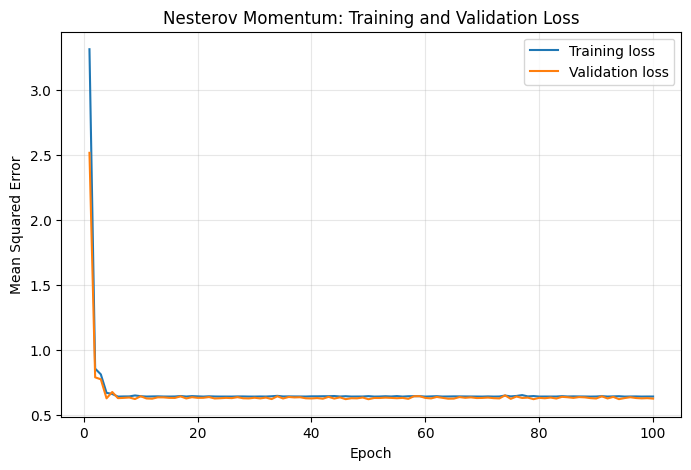

In [84]:
plot_losses(

    nesterov_history,

    title=(

        "Nesterov Momentum: "

        "Training and Validation Loss"
    ),
)

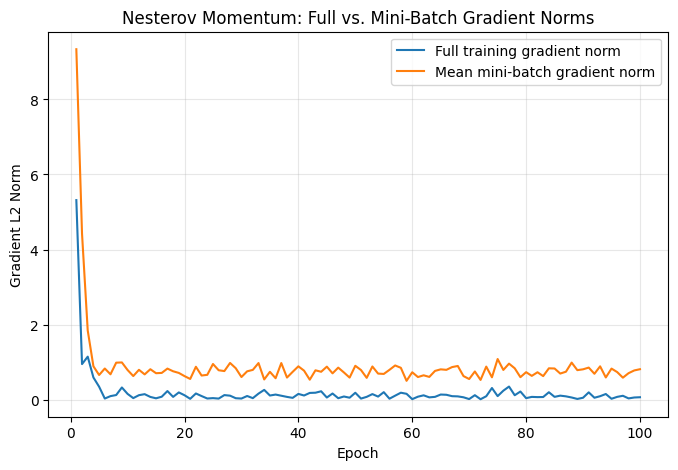

In [85]:
plot_sgd_gradient_norms(

    nesterov_history,

    title=(

        "Nesterov Momentum: "

        "Full vs. Mini-Batch "
        "Gradient Norms"
    ),
)

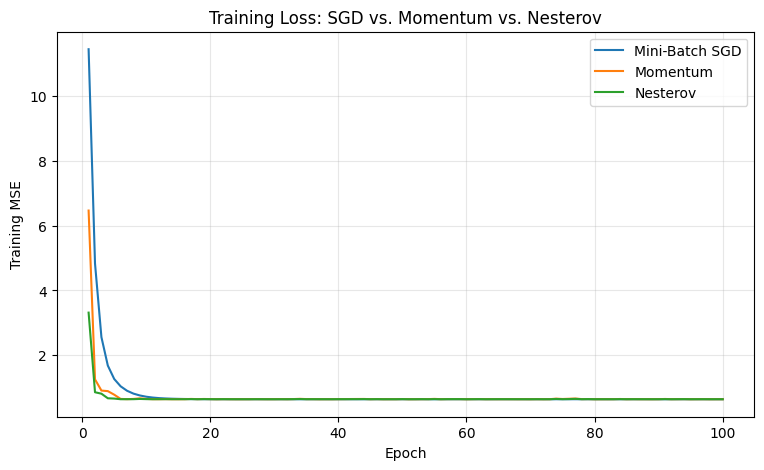

In [86]:
compare_loss_histories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",
    ],

    title=(

        "Training Loss: "

        "SGD vs. Momentum "
        "vs. Nesterov"
    ),
)

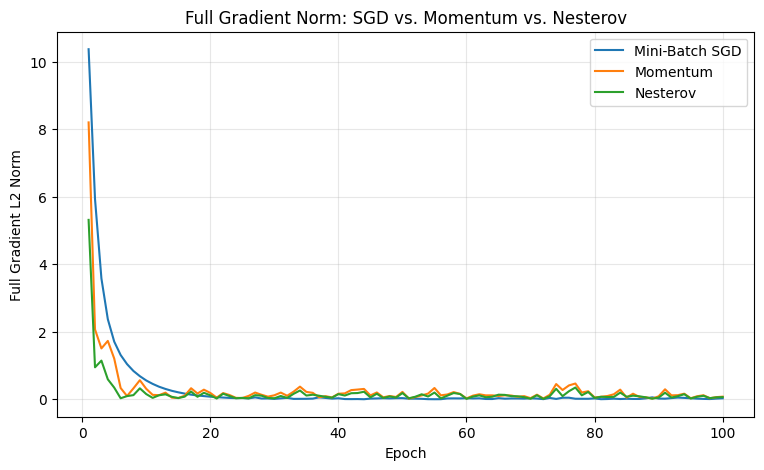

In [87]:
compare_gradient_norm_histories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",
    ],

    title=(

        "Full Gradient Norm: "

        "SGD vs. Momentum "
        "vs. Nesterov"
    ),
)

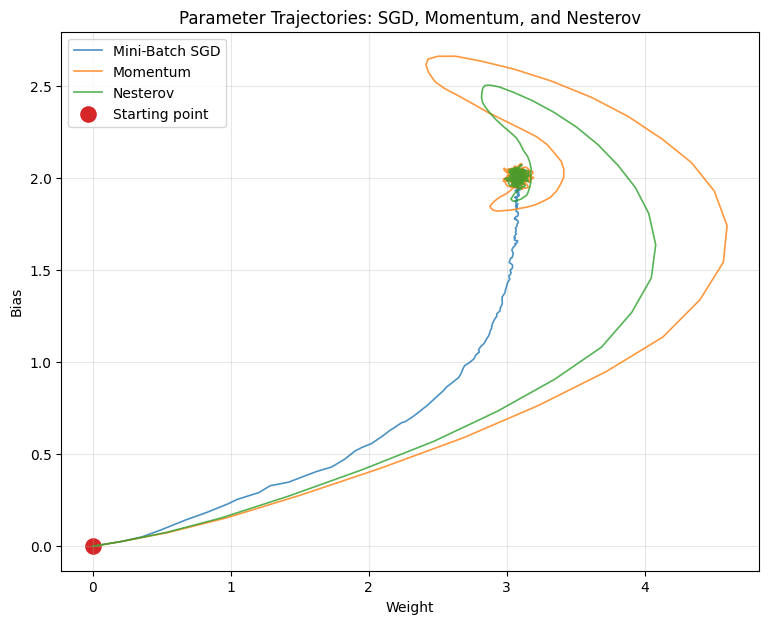

In [88]:
compare_update_trajectories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",
    ],

    title=(

        "Parameter Trajectories: "

        "SGD, Momentum, "
        "and Nesterov"
    ),
)

In [89]:
def compare_early_trajectories(
    histories,
    labels,
    title,
    number_of_updates=100,
):
    """
    Compare only the first portion
    of optimizer trajectories.
    """

    plt.figure(
        figsize=(9, 7)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        weights = np.array(

            history[
                "update_weight"
            ][
                :number_of_updates + 1
            ]
        )


        biases = np.array(

            history[
                "update_bias"
            ][
                :number_of_updates + 1
            ]
        )


        plt.plot(

            weights,

            biases,

            linewidth=1.5,

            marker="o",

            markersize=2,

            label=label,
        )


    plt.xlabel(
        "Weight"
    )


    plt.ylabel(
        "Bias"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

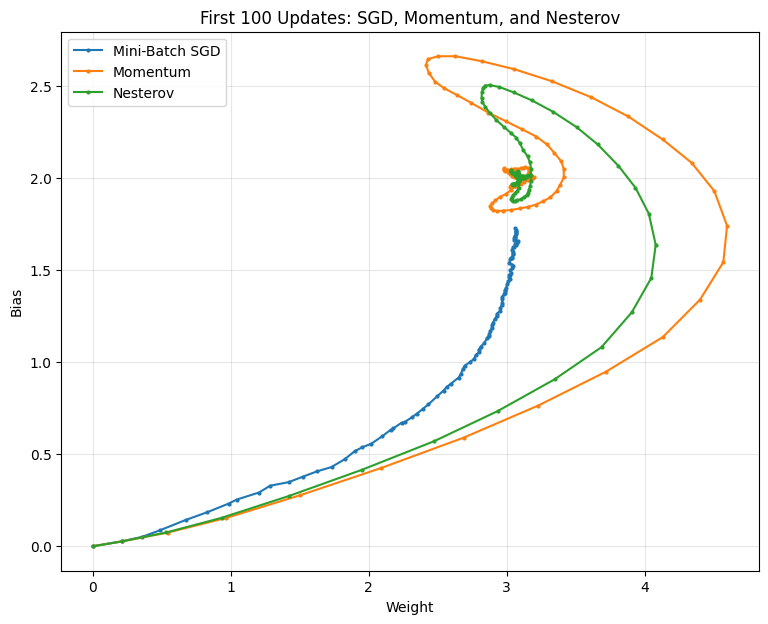

In [90]:
compare_early_trajectories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",
    ],

    title=(

        "First 100 Updates: "

        "SGD, Momentum, "
        "and Nesterov"
    ),

    number_of_updates=100,
)

In [91]:
sgd_test_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


nesterov_zero_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


test_gradient = {

    "weight": np.array(
        [[2.0]],
        dtype=np.float64,
    ),
}


sgd_test_optimizer = SGD(
    learning_rate=0.1
)


nesterov_zero_optimizer = (

    NesterovMomentum(

        learning_rate=0.1,

        momentum=0.0,
    )
)


lookahead = (

    nesterov_zero_optimizer

    .get_lookahead_parameters(

        nesterov_zero_parameters
    )
)


assert np.allclose(

    lookahead[
        "weight"
    ],

    nesterov_zero_parameters[
        "weight"
    ],
)


sgd_test_optimizer.step(

    sgd_test_parameters,

    test_gradient,
)


nesterov_zero_optimizer.step(

    nesterov_zero_parameters,

    test_gradient,
)


assert np.allclose(

    sgd_test_parameters[
        "weight"
    ],

    nesterov_zero_parameters[
        "weight"
    ],
)


print(
    "Nesterov with momentum = 0 "
    "matches ordinary SGD."
)

Nesterov with momentum = 0 matches ordinary SGD.


In [92]:
expected_updates_per_epoch = (

    int(

        np.ceil(

            len(X_train)

            / 16
        )
    )
)


expected_total_updates = (

    100

    * expected_updates_per_epoch
)


assert (

    nesterov_history[
        "train_loss"
    ][-1]

    <

    nesterov_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    nesterov_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.3,
)


assert np.isclose(

    nesterov_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (

    nesterov_optimizer.step_count

    ==

    expected_total_updates
)


assert (

    "weight"

    in

    nesterov_optimizer.velocity
)


assert (

    "bias"

    in

    nesterov_optimizer.velocity
)


assert (

    len(

        nesterov_history[
            "update_weight"
        ]
    )

    ==

    expected_total_updates + 1
)


print(
    "All Nesterov Momentum "
    "checks passed."
)

All Nesterov Momentum checks passed.


# Part 6: AdaGrad

AdaGrad adapts the effective learning rate separately
for every parameter.

It accumulates squared gradients:

$$
G_t
=
G_{t-1}
+
g_t^2
$$

The parameter update is:

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}
{\sqrt{G_t}+\epsilon}
g_t
$$

where:

- $\eta$ is the base learning rate;
- $g_t$ is the current gradient;
- $G_t$ is the accumulated sum of squared gradients;
- $\epsilon$ prevents division by zero.

All squares, square roots, divisions, and multiplications
are element-wise.

Because $G_t$ continually increases, AdaGrad's effective
learning rates generally decrease throughout training.

In [93]:
class AdaGrad(NumPyOptimizer):
    """
    Adaptive Gradient optimizer.

    Accumulator:

        accumulator =
            accumulator
            + gradient^2

    Parameter update:

        parameter =
            parameter
            - learning_rate
              * gradient
              / (
                    sqrt(accumulator)
                    + epsilon
                )
    """

    def __init__(
        self,
        learning_rate=0.01,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.epsilon = epsilon


        # One accumulated squared-gradient
        # array for every parameter.

        self.accumulator = {}

In [94]:
class AdaGrad(NumPyOptimizer):
    """
    Adaptive Gradient optimizer.

    Accumulator:

        accumulator =
            accumulator
            + gradient^2

    Parameter:

        parameter =
            parameter
            - learning_rate
              * gradient
              / (
                    sqrt(accumulator)
                    + epsilon
                )
    """

    def __init__(
        self,
        learning_rate=0.01,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.epsilon = epsilon

        self.accumulator = {}


    def initialize_state(
        self,
        parameters,
    ):
        """
        Create one zero accumulator
        for every parameter.
        """

        for name in parameters:

            if (
                name
                not in self.accumulator
            ):

                self.accumulator[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        self.initialize_state(
            parameters
        )


        for name in parameters:


            # Accumulate squared gradients.

            self.accumulator[name] += (

                gradients[name] ** 2
            )


            # Compute the adaptive update.

            adaptive_update = (

                self.learning_rate

                * gradients[name]

                / (

                    np.sqrt(
                        self.accumulator[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


            # Update parameters.

            parameters[name] -= (
                adaptive_update
            )


        self.step_count += 1

In [95]:
test_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


test_gradients = {

    "weight": np.array(
        [[2.0]],
        dtype=np.float64,
    ),
}


test_adagrad = AdaGrad(

    learning_rate=0.1,

    epsilon=1e-8,
)


test_adagrad.step(

    test_parameters,

    test_gradients,
)


print(
    "Accumulator:",
    test_adagrad.accumulator[
        "weight"
    ].item(),
)


print(
    "Updated parameter:",
    test_parameters[
        "weight"
    ].item(),
)

Accumulator: 4.0
Updated parameter: 0.9000000005


In [96]:
test_adagrad.step(

    test_parameters,

    test_gradients,
)


print(
    "Accumulator:",
    test_adagrad.accumulator[
        "weight"
    ].item(),
)


print(
    "Updated parameter:",
    test_parameters[
        "weight"
    ].item(),
)

Accumulator: 8.0
Updated parameter: 0.8292893226313451


In [97]:
assert np.isclose(

    test_adagrad.accumulator[
        "weight"
    ].item(),

    8.0,
)


expected_parameter = (

    1.0

    - (
        0.1 * 2.0
        / (
            np.sqrt(4.0)
            + 1e-8
        )
    )

    - (
        0.1 * 2.0
        / (
            np.sqrt(8.0)
            + 1e-8
        )
    )
)


assert np.isclose(

    test_parameters[
        "weight"
    ].item(),

    expected_parameter,
)


assert (
    test_adagrad.step_count
    == 2
)


print(
    "Manual AdaGrad checks passed."
)

Manual AdaGrad checks passed.


In [98]:
class AdaGrad(NumPyOptimizer):
    """
    Adaptive Gradient optimizer.
    """

    def __init__(
        self,
        learning_rate=0.01,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.epsilon = epsilon

        self.accumulator = {}


    def initialize_state(
        self,
        parameters,
    ):

        for name in parameters:

            if (
                name
                not in self.accumulator
            ):

                self.accumulator[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


    def get_effective_learning_rates(
        self,
    ):
        """
        Return the element-wise effective
        learning rates:

            learning_rate
            / (
                sqrt(accumulator)
                + epsilon
              )
        """

        effective_learning_rates = {}


        for name in self.accumulator:

            effective_learning_rates[
                name
            ] = (

                self.learning_rate

                / (

                    np.sqrt(
                        self.accumulator[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


        return effective_learning_rates


    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        self.initialize_state(
            parameters
        )


        for name in parameters:


            self.accumulator[name] += (

                gradients[name] ** 2
            )


            effective_learning_rate = (

                self.learning_rate

                / (

                    np.sqrt(
                        self.accumulator[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


            parameters[name] -= (

                effective_learning_rate

                * gradients[name]
            )


        self.step_count += 1

In [99]:
vector_parameters = {

    "vector": np.array(

        [
            [0.0],
            [0.0],
        ],

        dtype=np.float64,
    ),
}


vector_gradients = {

    "vector": np.array(

        [
            [10.0],
            [1.0],
        ],

        dtype=np.float64,
    ),
}


vector_adagrad = AdaGrad(

    learning_rate=0.1,

    epsilon=1e-8,
)


vector_adagrad.step(

    vector_parameters,

    vector_gradients,
)


effective_learning_rates = (

    vector_adagrad
    .get_effective_learning_rates()
)


print(
    "Accumulator:"
)

print(
    vector_adagrad.accumulator[
        "vector"
    ]
)


print(
    "\nEffective learning rates:"
)

print(
    effective_learning_rates[
        "vector"
    ]
)


print(
    "\nUpdated parameters:"
)

print(
    vector_parameters[
        "vector"
    ]
)

Accumulator:
[[100.]
 [  1.]]

Effective learning rates:
[[0.01]
 [0.1 ]]

Updated parameters:
[[-0.1]
 [-0.1]]


In [100]:
adagrad_optimizer = AdaGrad(

    learning_rate=0.1,
    epsilon=1e-8,
)

(
    adagrad_parameters,
    adagrad_history,
) = train_linear_regression_sgd(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        adagrad_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 23.077592 | Validation loss: 18.620807 | Full gradient norm: 15.870266 | Updates: 10
Epoch   10 | Train loss: 7.828485 | Validation loss: 6.506088 | Full gradient norm: 9.097261 | Updates: 10
Epoch   20 | Train loss: 3.608315 | Validation loss: 3.140237 | Full gradient norm: 5.884970 | Updates: 10
Epoch   30 | Train loss: 1.969374 | Validation loss: 1.811446 | Full gradient norm: 3.955773 | Updates: 10
Epoch   40 | Train loss: 1.254410 | Validation loss: 1.215054 | Full gradient norm: 2.697786 | Updates: 10
Epoch   50 | Train loss: 0.927828 | Validation loss: 0.930796 | Full gradient norm: 1.850466 | Updates: 10
Epoch   60 | Train loss: 0.775958 | Validation loss: 0.790222 | Full gradient norm: 1.273785 | Updates: 10
Epoch   70 | Train loss: 0.704459 | Validation loss: 0.718206 | Full gradient norm: 0.878150 | Updates: 10
Epoch   80 | Train loss: 0.670627 | Validation loss: 0.680169 | Full gradient norm: 0.605807 | Updates: 10
Epoch   90 | Train loss: 0.654559 

In [101]:
print(
    "\nTrue weight:    "
    "3.0000"
)

print(
    "Learned weight: "
    f"{adagrad_parameters['weight'].item():.4f}"
)


print(
    "\nTrue bias:      "
    "2.0000"
)

print(
    "Learned bias:   "
    f"{adagrad_parameters['bias'].item():.4f}"
)


print(
    "\nTotal optimizer updates:",
    adagrad_optimizer.step_count,
)


True weight:    3.0000
Learned weight: 3.0307

True bias:      2.0000
Learned bias:   1.9945

Total optimizer updates: 1000


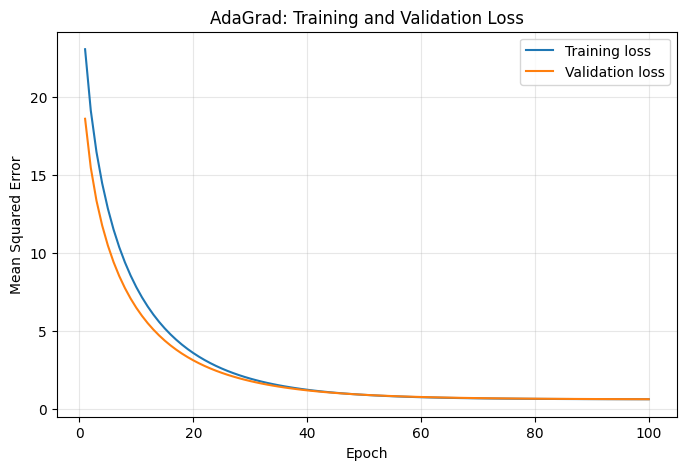

In [102]:
plot_losses(

    adagrad_history,

    title=(

        "AdaGrad: "

        "Training and Validation Loss"
    ),
)

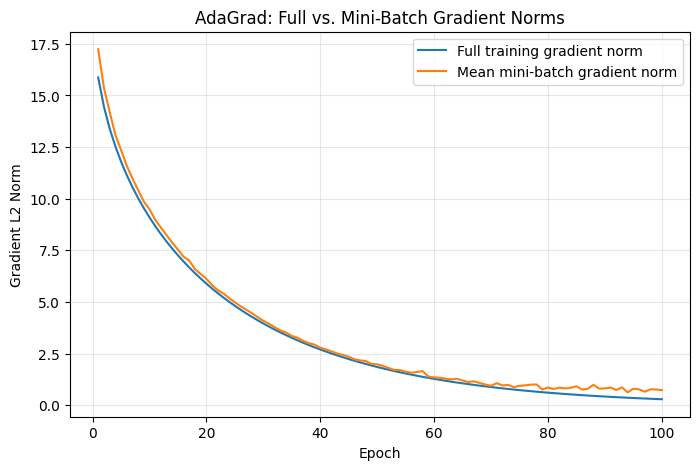

In [103]:
plot_sgd_gradient_norms(

    adagrad_history,

    title=(

        "AdaGrad: "

        "Full vs. Mini-Batch "
        "Gradient Norms"
    ),
)

In [104]:
print(
    "Final weight accumulator:"
)

print(
    adagrad_optimizer.accumulator[
        "weight"
    ]
)


print(
    "\nFinal bias accumulator:"
)

print(
    adagrad_optimizer.accumulator[
        "bias"
    ]
)

Final weight accumulator:
[[26709.1243995]]

Final bias accumulator:
[[1203.84590796]]


In [105]:
final_effective_learning_rates = (

    adagrad_optimizer
    .get_effective_learning_rates()
)


print(
    "Base learning rate:"
)

print(
    adagrad_optimizer.learning_rate
)


print(
    "\nFinal effective learning "
    "rate for weight:"
)

print(
    final_effective_learning_rates[
        "weight"
    ]
)


print(
    "\nFinal effective learning "
    "rate for bias:"
)

print(
    final_effective_learning_rates[
        "bias"
    ]
)

Base learning rate:
0.1

Final effective learning rate for weight:
[[0.00061189]]

Final effective learning rate for bias:
[[0.00288214]]


In [106]:
def train_linear_regression_adagrad(
    X_train,
    y_train,
    X_validation,
    y_validation,
    optimizer,
    epochs=100,
    batch_size=16,
    initial_weight=0.0,
    initial_bias=0.0,
    shuffle=True,
    seed=42,
    print_every=10,
):
    """
    Train linear regression with AdaGrad
    while tracking effective learning rates.
    """

    parameters = {

        "weight": np.array(
            [[initial_weight]],
            dtype=np.float64,
        ),

        "bias": np.array(
            [[initial_bias]],
            dtype=np.float64,
        ),
    }


    history = (
        create_sgd_history()
    )


    history[
        "weight_effective_lr"
    ] = []


    history[
        "bias_effective_lr"
    ] = []


    rng = np.random.default_rng(
        seed=seed
    )


    # Save initial parameters.

    history["weight"].append(

        parameters[
            "weight"
        ].item()
    )


    history["bias"].append(

        parameters[
            "bias"
        ].item()
    )


    history[
        "update_weight"
    ].append(

        parameters[
            "weight"
        ].item()
    )


    history[
        "update_bias"
    ].append(

        parameters[
            "bias"
        ].item()
    )


    # ===================================
    # Training
    # ===================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        batch_gradient_norms = []

        updates_this_epoch = 0


        mini_batches = (

            create_mini_batches(

                X=X_train,

                y=y_train,

                batch_size=batch_size,

                shuffle=shuffle,

                rng=rng,
            )
        )


        for (
            X_batch,
            y_batch,
        ) in mini_batches:


            batch_predictions = (

                linear_model(

                    X_batch,

                    parameters[
                        "weight"
                    ],

                    parameters[
                        "bias"
                    ],
                )
            )


            (
                weight_gradient,
                bias_gradient,
            ) = (

                linear_regression_gradients(

                    X_batch,

                    batch_predictions,

                    y_batch,
                )
            )


            gradients = {

                "weight":
                    weight_gradient,

                "bias":
                    bias_gradient,
            }


            batch_gradient_norm = (

                compute_global_gradient_norm(
                    gradients
                )
            )


            batch_gradient_norms.append(

                batch_gradient_norm
            )


            history[
                "update_gradient_norm"
            ].append(

                batch_gradient_norm
            )


            optimizer.step(

                parameters,

                gradients,
            )


            updates_this_epoch += 1


            history[
                "update_weight"
            ].append(

                parameters[
                    "weight"
                ].item()
            )


            history[
                "update_bias"
            ].append(

                parameters[
                    "bias"
                ].item()
            )


        # ===================================
        # End-of-epoch evaluation
        # ===================================

        train_predictions = (

            linear_model(

                X_train,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        train_loss = (

            mean_squared_error(

                train_predictions,

                y_train,
            )
        )


        validation_predictions = (

            linear_model(

                X_validation,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        validation_loss = (

            mean_squared_error(

                validation_predictions,

                y_validation,
            )
        )


        (
            full_weight_gradient,
            full_bias_gradient,
        ) = (

            linear_regression_gradients(

                X_train,

                train_predictions,

                y_train,
            )
        )


        full_gradients = {

            "weight":
                full_weight_gradient,

            "bias":
                full_bias_gradient,
        }


        full_gradient_norm = (

            compute_global_gradient_norm(

                full_gradients
            )
        )


        mean_batch_gradient_norm = (

            float(

                np.mean(
                    batch_gradient_norms
                )
            )
        )


        effective_learning_rates = (

            optimizer

            .get_effective_learning_rates()
        )


        # ===================================
        # Save metrics
        # ===================================

        history[
            "train_loss"
        ].append(
            train_loss
        )


        history[
            "validation_loss"
        ].append(
            validation_loss
        )


        history[
            "gradient_norm"
        ].append(
            full_gradient_norm
        )


        history[
            "mean_batch_gradient_norm"
        ].append(
            mean_batch_gradient_norm
        )


        history[
            "learning_rate"
        ].append(
            optimizer.learning_rate
        )


        history[
            "weight_effective_lr"
        ].append(

            effective_learning_rates[
                "weight"
            ].item()
        )


        history[
            "bias_effective_lr"
        ].append(

            effective_learning_rates[
                "bias"
            ].item()
        )


        history[
            "weight"
        ].append(

            parameters[
                "weight"
            ].item()
        )


        history[
            "bias"
        ].append(

            parameters[
                "bias"
            ].item()
        )


        history[
            "updates_per_epoch"
        ].append(

            updates_this_epoch
        )


        # ===================================
        # Print progress
        # ===================================

        if (
            epoch == 1

            or epoch % print_every == 0

            or epoch == epochs
        ):

            print(

                f"Epoch {epoch:4d} | "

                f"Train loss: "
                f"{train_loss:.6f} | "

                f"Validation loss: "
                f"{validation_loss:.6f} | "

                f"Weight effective LR: "
                f"{history['weight_effective_lr'][-1]:.6f} | "

                f"Bias effective LR: "
                f"{history['bias_effective_lr'][-1]:.6f}"
            )


    return parameters, history

In [108]:
tracked_adagrad_optimizer = (

    AdaGrad(

        learning_rate=0.1,

        epsilon=1e-8,
    )
)

(
    tracked_adagrad_parameters,
    tracked_adagrad_history,
) = train_linear_regression_adagrad(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        tracked_adagrad_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 23.077592 | Validation loss: 18.620807 | Weight effective LR: 0.001819 | Bias effective LR: 0.009241
Epoch   10 | Train loss: 7.828485 | Validation loss: 6.506088 | Weight effective LR: 0.000787 | Bias effective LR: 0.003665
Epoch   20 | Train loss: 3.608315 | Validation loss: 3.140237 | Weight effective LR: 0.000678 | Bias effective LR: 0.003200
Epoch   30 | Train loss: 1.969374 | Validation loss: 1.811446 | Weight effective LR: 0.000642 | Bias effective LR: 0.003076
Epoch   40 | Train loss: 1.254410 | Validation loss: 1.215054 | Weight effective LR: 0.000627 | Bias effective LR: 0.003022
Epoch   50 | Train loss: 0.927828 | Validation loss: 0.930796 | Weight effective LR: 0.000620 | Bias effective LR: 0.002982
Epoch   60 | Train loss: 0.775958 | Validation loss: 0.790222 | Weight effective LR: 0.000616 | Bias effective LR: 0.002955
Epoch   70 | Train loss: 0.704459 | Validation loss: 0.718206 | Weight effective LR: 0.000615 | Bias effective LR: 0.002935
Epoch 

In [109]:
def plot_effective_learning_rates(
    history,
    title,
):
    """
    Plot AdaGrad's parameter-wise
    effective learning rates.
    """

    epochs = np.arange(

        1,

        len(

            history[
                "weight_effective_lr"
            ]

        ) + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        epochs,

        history[
            "weight_effective_lr"
        ],

        label=(
            "Weight effective LR"
        ),
    )


    plt.plot(

        epochs,

        history[
            "bias_effective_lr"
        ],

        label=(
            "Bias effective LR"
        ),
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Effective Learning Rate"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

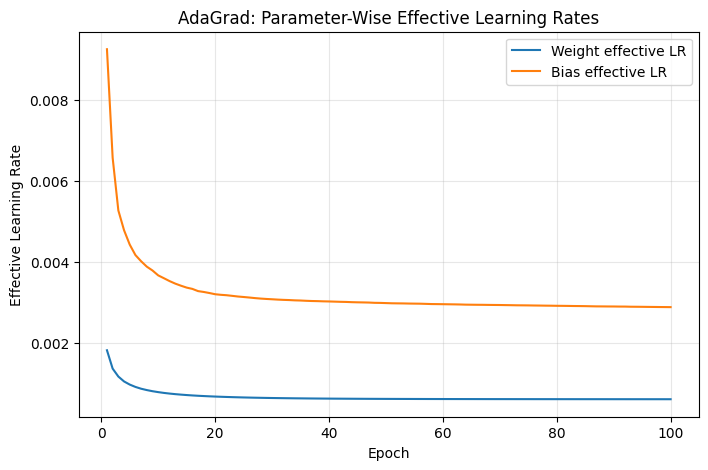

In [110]:
plot_effective_learning_rates(

    tracked_adagrad_history,

    title=(

        "AdaGrad: "

        "Parameter-Wise "
        "Effective Learning Rates"
    ),
)

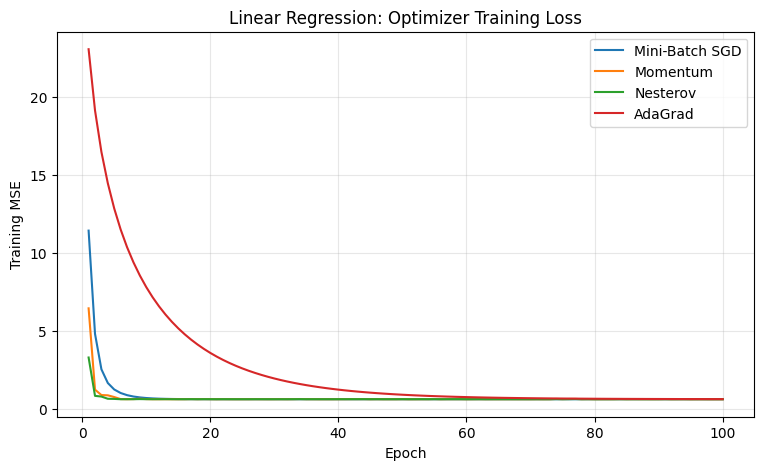

In [111]:
compare_loss_histories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",
    ],

    title=(

        "Linear Regression: "

        "Optimizer Training Loss"
    ),
)

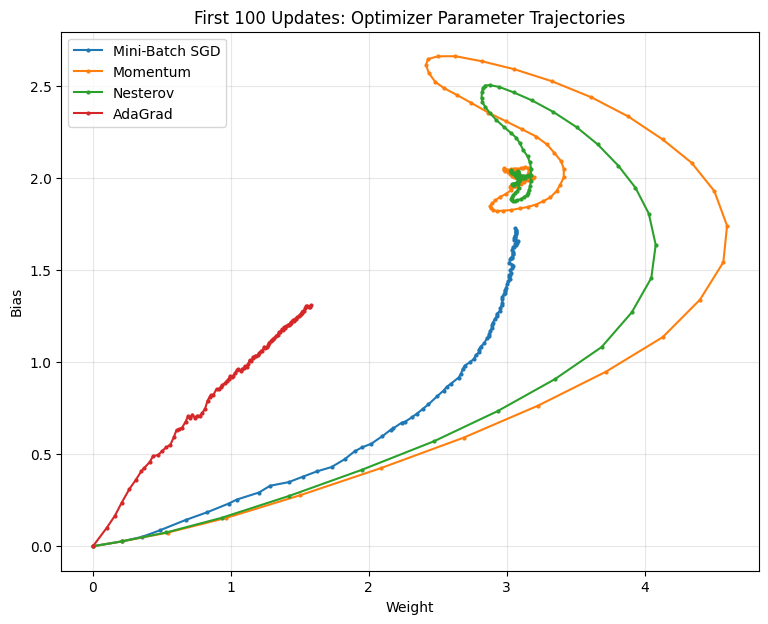

In [112]:
compare_early_trajectories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",
    ],

    title=(

        "First 100 Updates: "

        "Optimizer Parameter "
        "Trajectories"
    ),

    number_of_updates=100,
)

In [113]:
assert (

    tracked_adagrad_history[
        "train_loss"
    ][-1]

    <

    tracked_adagrad_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    tracked_adagrad_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.3,
)


assert np.isclose(

    tracked_adagrad_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (

    tracked_adagrad_optimizer.step_count

    ==

    1000
)


assert np.all(

    tracked_adagrad_optimizer
    .accumulator[
        "weight"
    ]

    >= 0
)


assert np.all(

    tracked_adagrad_optimizer
    .accumulator[
        "bias"
    ]

    >= 0
)


assert (

    tracked_adagrad_history[
        "weight_effective_lr"
    ][-1]

    <=

    tracked_adagrad_history[
        "weight_effective_lr"
    ][0]
)


assert (

    tracked_adagrad_history[
        "bias_effective_lr"
    ][-1]

    <=

    tracked_adagrad_history[
        "bias_effective_lr"
    ][0]
)


print(
    "All AdaGrad checks passed."
)

All AdaGrad checks passed.


# Part 7: RMSProp

AdaGrad stores the lifetime sum of squared gradients:

$$
G_t
=
G_{t-1}
+
g_t^2
$$

Because this accumulator continually grows, AdaGrad's
effective learning rates continually decrease.

RMSProp instead maintains an exponential moving average
of squared gradients:

$$
s_t
=
\rho s_{t-1}
+
(1-\rho)g_t^2
$$

The parameter update is:

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}
{\sqrt{s_t}+\epsilon}
g_t
$$

where:

- $\eta$ is the base learning rate;
- $\rho$ is the squared-gradient decay rate;
- $s_t$ is the exponential moving average of squared gradients;
- $\epsilon$ prevents division by zero.

Older squared gradients gradually lose influence because
their contributions are repeatedly multiplied by $\rho$.

In [114]:
class RMSProp(NumPyOptimizer):
    """
    Root Mean Square Propagation.

    Squared-gradient moving average:

        square_average =
            decay_rate
            * square_average

            + (1 - decay_rate)
            * gradient^2

    Parameter update:

        parameter =
            parameter

            - learning_rate
              * gradient

              / (
                    sqrt(square_average)
                    + epsilon
                )
    """

    def __init__(
        self,
        learning_rate=0.001,
        decay_rate=0.9,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= decay_rate < 1.0:

            raise ValueError(
                "decay_rate must satisfy "
                "0 <= decay_rate < 1."
            )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.decay_rate = decay_rate

        self.epsilon = epsilon


        # One moving average of squared
        # gradients for every parameter.

        self.square_average = {}

In [115]:
class RMSProp(NumPyOptimizer):
    """
    Root Mean Square Propagation.

    Squared-gradient moving average:

        square_average =
            decay_rate
            * square_average

            + (1 - decay_rate)
            * gradient^2

    Parameter:

        parameter =
            parameter

            - learning_rate
              * gradient

              / (
                    sqrt(square_average)
                    + epsilon
                )
    """

    def __init__(
        self,
        learning_rate=0.001,
        decay_rate=0.9,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= decay_rate < 1.0:

            raise ValueError(
                "decay_rate must satisfy "
                "0 <= decay_rate < 1."
            )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.decay_rate = decay_rate

        self.epsilon = epsilon

        self.square_average = {}


    def initialize_state(
        self,
        parameters,
    ):
        """
        Create one zero squared-gradient
        moving average for every parameter.
        """

        for name in parameters:

            if (
                name
                not in self.square_average
            ):

                self.square_average[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


    def get_effective_learning_rates(
        self,
    ):
        """
        Return:

            learning_rate
            / (
                sqrt(square_average)
                + epsilon
              )
        """

        effective_learning_rates = {}


        for name in self.square_average:

            effective_learning_rates[
                name
            ] = (

                self.learning_rate

                / (

                    np.sqrt(

                        self.square_average[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


        return effective_learning_rates


    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        self.initialize_state(
            parameters
        )


        for name in parameters:


            # Update the exponential
            # moving average of squared
            # gradients.

            self.square_average[name] = (

                self.decay_rate

                * self.square_average[
                    name
                ]

                + (

                    1.0
                    - self.decay_rate

                )

                * (
                    gradients[name] ** 2
                )
            )


            # Compute parameter-wise
            # effective learning rates.

            effective_learning_rate = (

                self.learning_rate

                / (

                    np.sqrt(

                        self.square_average[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


            # Update parameters.

            parameters[name] -= (

                effective_learning_rate

                * gradients[name]
            )


        self.step_count += 1

In [116]:
test_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


test_gradients = {

    "weight": np.array(
        [[2.0]],
        dtype=np.float64,
    ),
}


test_rmsprop = RMSProp(

    learning_rate=0.1,

    decay_rate=0.9,

    epsilon=1e-8,
)


test_rmsprop.step(

    test_parameters,

    test_gradients,
)


print(
    "Squared-gradient average:"
)

print(
    test_rmsprop.square_average[
        "weight"
    ]
)


print(
    "\nUpdated parameter:"
)

print(
    test_parameters[
        "weight"
    ]
)

Squared-gradient average:
[[0.4]]

Updated parameter:
[[0.68377224]]


In [117]:
test_rmsprop.step(

    test_parameters,

    test_gradients,
)


print(
    "Squared-gradient average:"
)

print(
    test_rmsprop.square_average[
        "weight"
    ]
)


print(
    "\nUpdated parameter:"
)

print(
    test_parameters[
        "weight"
    ]
)

Squared-gradient average:
[[0.76]]

Updated parameter:
[[0.45435651]]


In [118]:
expected_square_average = (

    0.9 * 0.4

    + 0.1 * 4.0
)


assert np.isclose(

    test_rmsprop.square_average[
        "weight"
    ].item(),

    expected_square_average,
)


first_parameter = (

    1.0

    - (

        0.1 * 2.0

        / (
            np.sqrt(0.4)
            + 1e-8
        )
    )
)


expected_parameter = (

    first_parameter

    - (

        0.1 * 2.0

        / (
            np.sqrt(0.76)
            + 1e-8
        )
    )
)


assert np.isclose(

    test_parameters[
        "weight"
    ].item(),

    expected_parameter,
)


assert (
    test_rmsprop.step_count
    == 2
)


print(
    "Manual RMSProp checks passed."
)

Manual RMSProp checks passed.


In [119]:
def compare_adagrad_rmsprop_state(
    gradient=2.0,
    steps=100,
    decay_rate=0.9,
):
    """
    Compare AdaGrad's cumulative
    squared-gradient state with
    RMSProp's exponential moving average.
    """

    adagrad_state = 0.0

    rmsprop_state = 0.0


    adagrad_values = []

    rmsprop_values = []


    for _ in range(steps):


        squared_gradient = (
            gradient ** 2
        )


        # AdaGrad

        adagrad_state += (
            squared_gradient
        )


        # RMSProp

        rmsprop_state = (

            decay_rate

            * rmsprop_state

            + (

                1.0
                - decay_rate

            )

            * squared_gradient
        )


        adagrad_values.append(
            adagrad_state
        )


        rmsprop_values.append(
            rmsprop_state
        )


    step_numbers = np.arange(

        1,

        steps + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        step_numbers,

        adagrad_values,

        label=(
            "AdaGrad accumulator"
        ),
    )


    plt.plot(

        step_numbers,

        rmsprop_values,

        label=(
            "RMSProp square average"
        ),
    )


    plt.xlabel(
        "Optimizer Step"
    )


    plt.ylabel(
        "Squared-Gradient State"
    )


    plt.title(

        "AdaGrad vs. RMSProp State "
        "for a Constant Gradient"
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

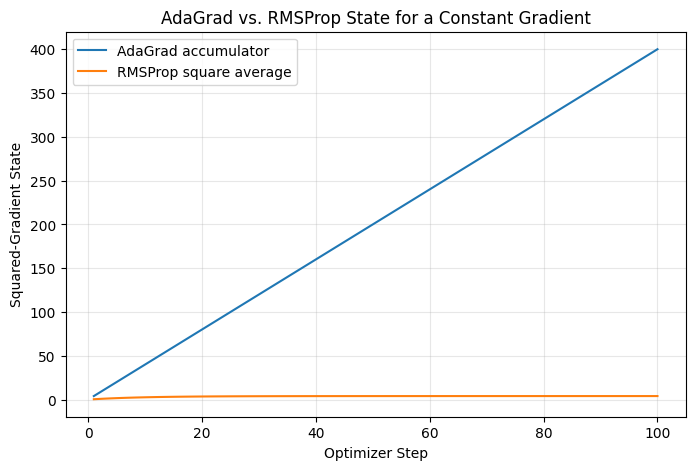

In [120]:
compare_adagrad_rmsprop_state(

    gradient=2.0,

    steps=100,

    decay_rate=0.9,
)

In [121]:
def train_linear_regression_adaptive(
    X_train,
    y_train,
    X_validation,
    y_validation,
    optimizer,
    epochs=100,
    batch_size=16,
    initial_weight=0.0,
    initial_bias=0.0,
    shuffle=True,
    seed=42,
    print_every=10,
):
    """
    Train linear regression using an
    adaptive optimizer.

    The optimizer must implement:

        get_effective_learning_rates()
    """

    parameters = {

        "weight": np.array(
            [[initial_weight]],
            dtype=np.float64,
        ),

        "bias": np.array(
            [[initial_bias]],
            dtype=np.float64,
        ),
    }


    history = (
        create_sgd_history()
    )


    history[
        "weight_effective_lr"
    ] = []


    history[
        "bias_effective_lr"
    ] = []


    rng = np.random.default_rng(
        seed=seed
    )


    # Save initial parameters.

    history["weight"].append(

        parameters[
            "weight"
        ].item()
    )


    history["bias"].append(

        parameters[
            "bias"
        ].item()
    )


    history[
        "update_weight"
    ].append(

        parameters[
            "weight"
        ].item()
    )


    history[
        "update_bias"
    ].append(

        parameters[
            "bias"
        ].item()
    )


    # ===================================
    # Training
    # ===================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        batch_gradient_norms = []

        updates_this_epoch = 0


        mini_batches = (

            create_mini_batches(

                X=X_train,

                y=y_train,

                batch_size=batch_size,

                shuffle=shuffle,

                rng=rng,
            )
        )


        for (
            X_batch,
            y_batch,
        ) in mini_batches:


            batch_predictions = (

                linear_model(

                    X_batch,

                    parameters[
                        "weight"
                    ],

                    parameters[
                        "bias"
                    ],
                )
            )


            (
                weight_gradient,
                bias_gradient,
            ) = (

                linear_regression_gradients(

                    X_batch,

                    batch_predictions,

                    y_batch,
                )
            )


            gradients = {

                "weight":
                    weight_gradient,

                "bias":
                    bias_gradient,
            }


            batch_gradient_norm = (

                compute_global_gradient_norm(
                    gradients
                )
            )


            batch_gradient_norms.append(

                batch_gradient_norm
            )


            history[
                "update_gradient_norm"
            ].append(

                batch_gradient_norm
            )


            optimizer.step(

                parameters,

                gradients,
            )


            updates_this_epoch += 1


            history[
                "update_weight"
            ].append(

                parameters[
                    "weight"
                ].item()
            )


            history[
                "update_bias"
            ].append(

                parameters[
                    "bias"
                ].item()
            )


        # ===================================
        # End-of-epoch evaluation
        # ===================================

        train_predictions = (

            linear_model(

                X_train,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        train_loss = (

            mean_squared_error(

                train_predictions,

                y_train,
            )
        )


        validation_predictions = (

            linear_model(

                X_validation,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        validation_loss = (

            mean_squared_error(

                validation_predictions,

                y_validation,
            )
        )


        (
            full_weight_gradient,
            full_bias_gradient,
        ) = (

            linear_regression_gradients(

                X_train,

                train_predictions,

                y_train,
            )
        )


        full_gradients = {

            "weight":
                full_weight_gradient,

            "bias":
                full_bias_gradient,
        }


        full_gradient_norm = (

            compute_global_gradient_norm(

                full_gradients
            )
        )


        mean_batch_gradient_norm = (

            float(

                np.mean(
                    batch_gradient_norms
                )
            )
        )


        effective_learning_rates = (

            optimizer

            .get_effective_learning_rates()
        )


        # ===================================
        # Save metrics
        # ===================================

        history[
            "train_loss"
        ].append(
            train_loss
        )


        history[
            "validation_loss"
        ].append(
            validation_loss
        )


        history[
            "gradient_norm"
        ].append(
            full_gradient_norm
        )


        history[
            "mean_batch_gradient_norm"
        ].append(
            mean_batch_gradient_norm
        )


        history[
            "learning_rate"
        ].append(
            optimizer.learning_rate
        )


        history[
            "weight_effective_lr"
        ].append(

            effective_learning_rates[
                "weight"
            ].item()
        )


        history[
            "bias_effective_lr"
        ].append(

            effective_learning_rates[
                "bias"
            ].item()
        )


        history[
            "weight"
        ].append(

            parameters[
                "weight"
            ].item()
        )


        history[
            "bias"
        ].append(

            parameters[
                "bias"
            ].item()
        )


        history[
            "updates_per_epoch"
        ].append(

            updates_this_epoch
        )


        # ===================================
        # Print progress
        # ===================================

        if (
            epoch == 1

            or epoch % print_every == 0

            or epoch == epochs
        ):

            print(

                f"Epoch {epoch:4d} | "

                f"Train loss: "
                f"{train_loss:.6f} | "

                f"Validation loss: "
                f"{validation_loss:.6f} | "

                f"Weight effective LR: "
                f"{history['weight_effective_lr'][-1]:.6f} | "

                f"Bias effective LR: "
                f"{history['bias_effective_lr'][-1]:.6f}"
            )


    return parameters, history

In [122]:
rmsprop_optimizer = RMSProp(

    learning_rate=0.01,

    decay_rate=0.9,

    epsilon=1e-8,
)

(
    rmsprop_parameters,
    rmsprop_history,
) = train_linear_regression_adaptive(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        rmsprop_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 29.123970 | Validation loss: 23.519446 | Weight effective LR: 0.000668 | Bias effective LR: 0.003312
Epoch   10 | Train loss: 14.396325 | Validation loss: 11.785298 | Weight effective LR: 0.000754 | Bias effective LR: 0.003192
Epoch   20 | Train loss: 4.635539 | Validation loss: 3.986903 | Weight effective LR: 0.001352 | Bias effective LR: 0.005946
Epoch   30 | Train loss: 0.861037 | Validation loss: 0.871171 | Weight effective LR: 0.004363 | Bias effective LR: 0.022833
Epoch   40 | Train loss: 0.640358 | Validation loss: 0.630403 | Weight effective LR: 0.012606 | Bias effective LR: 0.026403
Epoch   50 | Train loss: 0.640111 | Validation loss: 0.627426 | Weight effective LR: 0.012777 | Bias effective LR: 0.025505
Epoch   60 | Train loss: 0.640110 | Validation loss: 0.630077 | Weight effective LR: 0.014422 | Bias effective LR: 0.030414
Epoch   70 | Train loss: 0.640337 | Validation loss: 0.630183 | Weight effective LR: 0.017086 | Bias effective LR: 0.030819
Epoc

In [123]:
print(
    "\nTrue weight:    "
    "3.0000"
)

print(
    "Learned weight: "
    f"{rmsprop_parameters['weight'].item():.4f}"
)


print(
    "\nTrue bias:      "
    "2.0000"
)

print(
    "Learned bias:   "
    f"{rmsprop_parameters['bias'].item():.4f}"
)


print(
    "\nTotal optimizer updates:",
    rmsprop_optimizer.step_count,
)


True weight:    3.0000
Learned weight: 3.0700

True bias:      2.0000
Learned bias:   2.0082

Total optimizer updates: 1000


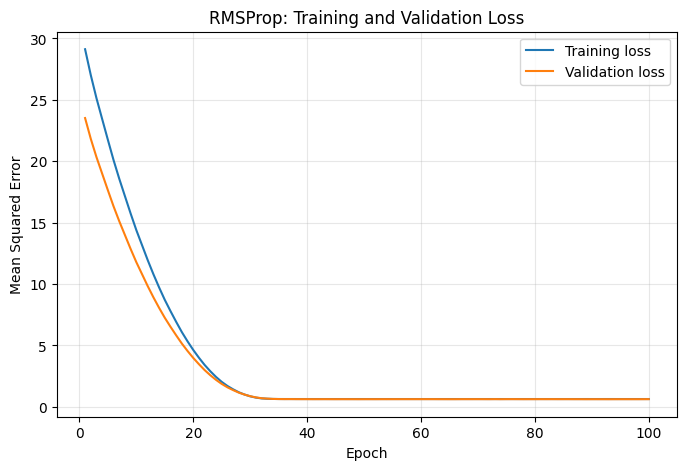

In [124]:
plot_losses(

    rmsprop_history,

    title=(

        "RMSProp: "

        "Training and Validation Loss"
    ),
)

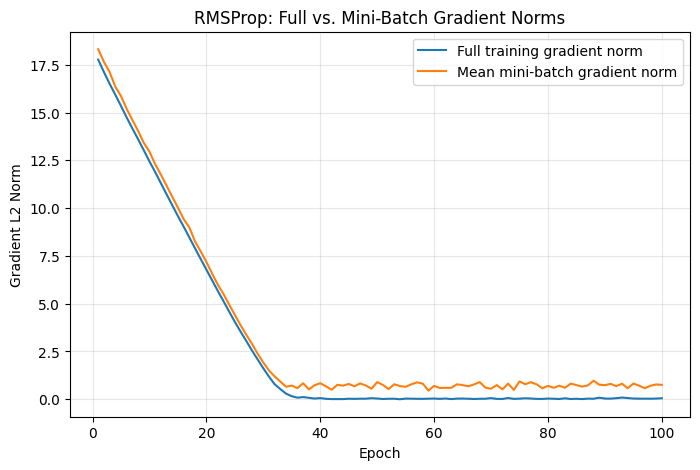

In [125]:
plot_sgd_gradient_norms(

    rmsprop_history,

    title=(

        "RMSProp: "

        "Full vs. Mini-Batch "
        "Gradient Norms"
    ),
)

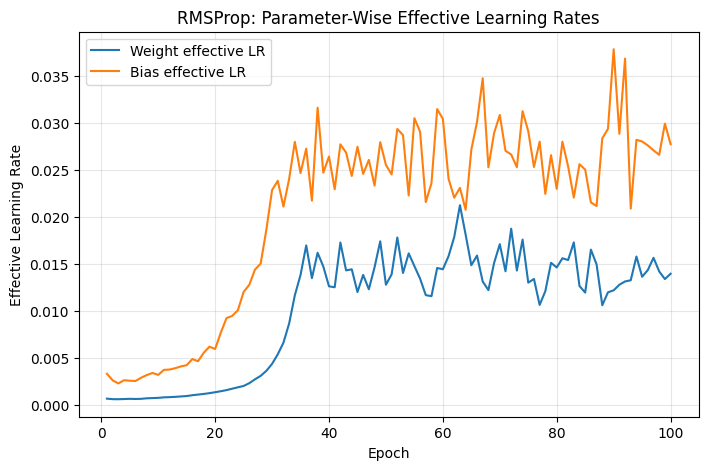

In [126]:
plot_effective_learning_rates(

    rmsprop_history,

    title=(

        "RMSProp: "

        "Parameter-Wise "
        "Effective Learning Rates"
    ),
)

In [127]:
def compare_effective_learning_rates(
    histories,
    labels,
    parameter_name,
    title,
):
    """
    Compare effective learning rates
    for one parameter.
    """

    history_key = (

        f"{parameter_name}"
        "_effective_lr"
    )


    plt.figure(
        figsize=(9, 5)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        epochs = np.arange(

            1,

            len(
                history[
                    history_key
                ]
            ) + 1,
        )


        plt.plot(

            epochs,

            history[
                history_key
            ],

            label=label,
        )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Effective Learning Rate"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

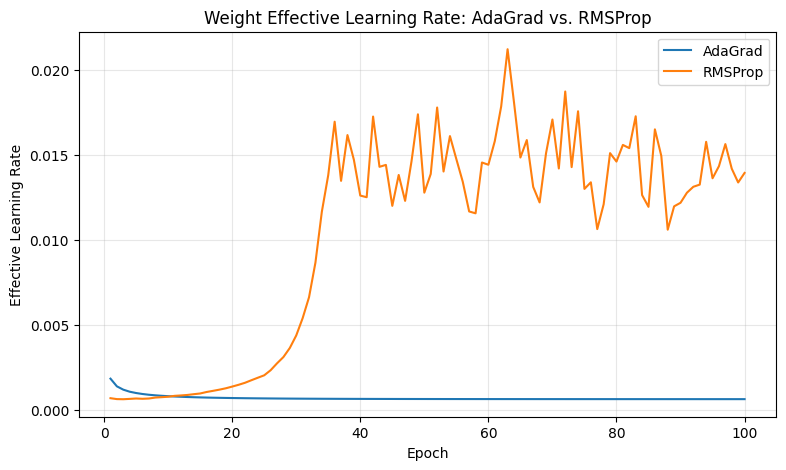

In [128]:
compare_effective_learning_rates(

    histories=[

        tracked_adagrad_history,

        rmsprop_history,
    ],

    labels=[

        "AdaGrad",

        "RMSProp",
    ],

    parameter_name="weight",

    title=(

        "Weight Effective Learning Rate: "

        "AdaGrad vs. RMSProp"
    ),
)

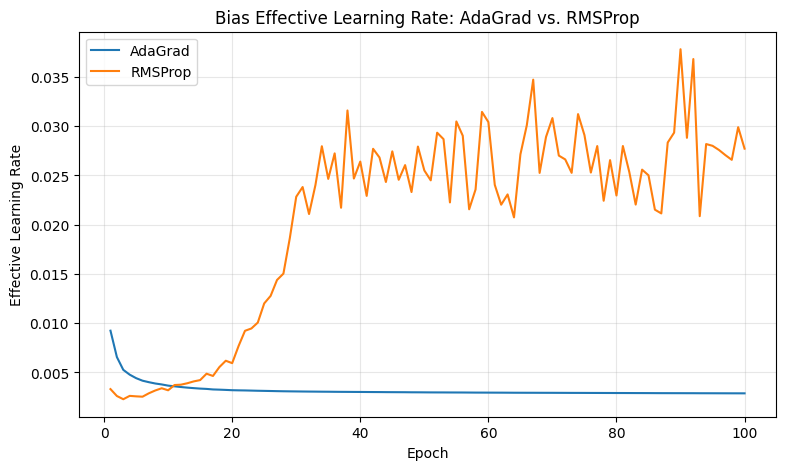

In [129]:
compare_effective_learning_rates(

    histories=[

        tracked_adagrad_history,

        rmsprop_history,
    ],

    labels=[

        "AdaGrad",

        "RMSProp",
    ],

    parameter_name="bias",

    title=(

        "Bias Effective Learning Rate: "

        "AdaGrad vs. RMSProp"
    ),
)

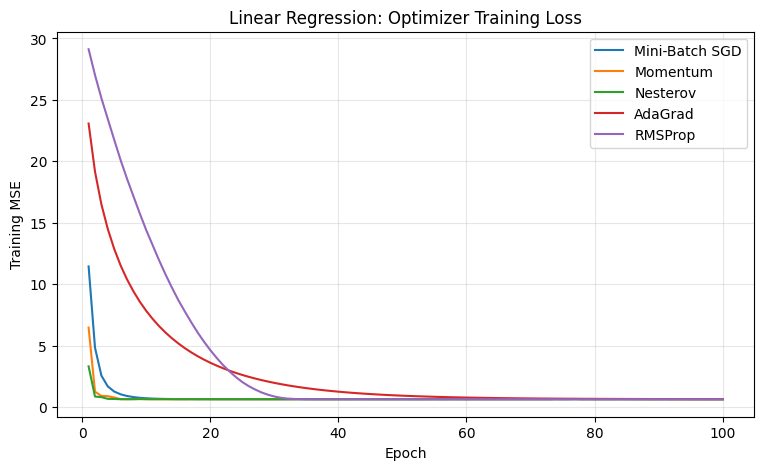

In [130]:
compare_loss_histories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",
    ],

    title=(

        "Linear Regression: "

        "Optimizer Training Loss"
    ),
)

In [131]:
def compare_loss_histories_log_scale(
    histories,
    labels,
    title,
):
    """
    Compare training losses using
    a logarithmic y-axis.
    """

    plt.figure(
        figsize=(9, 5)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        epochs = np.arange(

            1,

            len(

                history[
                    "train_loss"
                ]

            ) + 1,
        )


        plt.plot(

            epochs,

            history[
                "train_loss"
            ],

            label=label,
        )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Training MSE "
        "(Log Scale)"
    )


    plt.yscale(
        "log"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

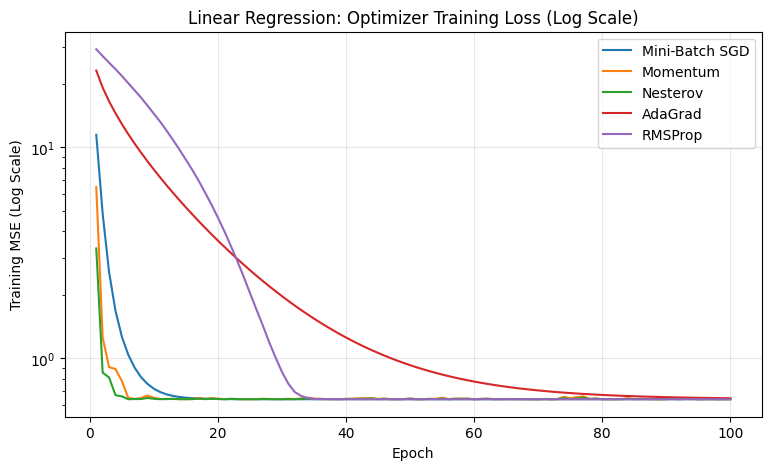

In [132]:
compare_loss_histories_log_scale(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",
    ],

    title=(

        "Linear Regression: "

        "Optimizer Training Loss "
        "(Log Scale)"
    ),
)

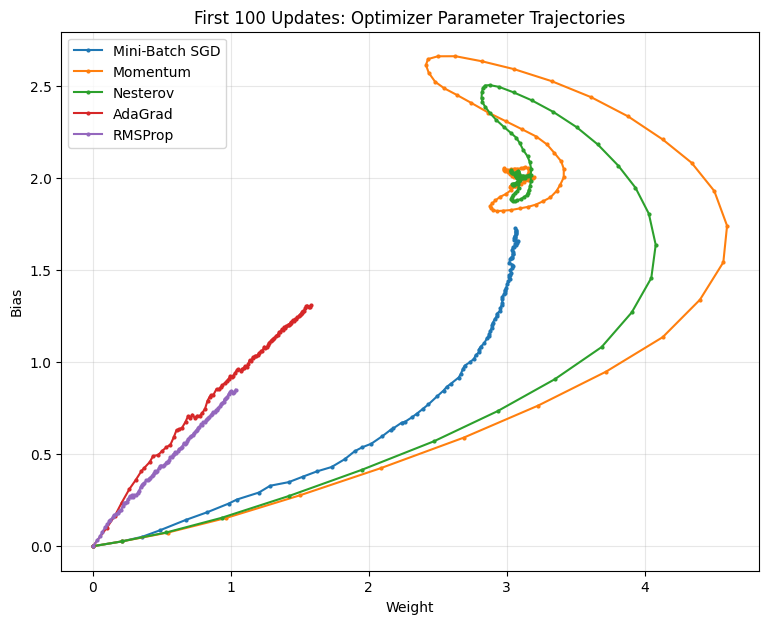

In [133]:
compare_early_trajectories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",
    ],

    title=(

        "First 100 Updates: "

        "Optimizer Parameter "
        "Trajectories"
    ),

    number_of_updates=100,
)

In [134]:
assert (

    rmsprop_history[
        "train_loss"
    ][-1]

    <

    rmsprop_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    rmsprop_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.3,
)


assert np.isclose(

    rmsprop_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (

    rmsprop_optimizer.step_count

    ==

    1000
)


assert np.all(

    rmsprop_optimizer
    .square_average[
        "weight"
    ]

    >= 0
)


assert np.all(

    rmsprop_optimizer
    .square_average[
        "bias"
    ]

    >= 0
)


assert (

    len(

        rmsprop_history[
            "weight_effective_lr"
        ]
    )

    == 100
)


assert (

    len(

        rmsprop_history[
            "bias_effective_lr"
        ]
    )

    == 100
)


print(
    "All RMSProp checks passed."
)

All RMSProp checks passed.


# Part 8: Adam

Adam combines:

1. A Momentum-like exponential moving average of gradients.
2. An RMSProp-like exponential moving average of squared gradients.

The first moment is:

$$
m_t
=
\beta_1m_{t-1}
+
(1-\beta_1)g_t
$$

The second moment is:

$$
v_t
=
\beta_2v_{t-1}
+
(1-\beta_2)g_t^2
$$

Because both moving averages begin at zero, they are biased
toward zero during the first optimization steps.

Adam applies bias correction:

$$
\hat m_t
=
\frac{m_t}
{1-\beta_1^t}
$$

$$
\hat v_t
=
\frac{v_t}
{1-\beta_2^t}
$$

The parameter update is:

$$
\theta_{t+1}
=
\theta_t
-
\eta
\frac{\hat m_t}
{\sqrt{\hat v_t}+\epsilon}
$$

Common default values are:

$$
\beta_1=0.9
$$

$$
\beta_2=0.999
$$

$$
\epsilon=10^{-8}
$$

In [135]:
class Adam(NumPyOptimizer):
    """
    Adaptive Moment Estimation.

    First moment:

        first_moment =
            beta1 * first_moment

            + (1 - beta1)
            * gradient

    Second moment:

        second_moment =
            beta2 * second_moment

            + (1 - beta2)
            * gradient^2

    Bias correction:

        corrected_first =
            first_moment
            / (1 - beta1^t)

        corrected_second =
            second_moment
            / (1 - beta2^t)

    Parameter:

        parameter =
            parameter

            - learning_rate

            * corrected_first

            / (
                sqrt(corrected_second)
                + epsilon
              )
    """

    def __init__(
        self,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= beta1 < 1.0:

            raise ValueError(
                "beta1 must satisfy "
                "0 <= beta1 < 1."
            )


        if not 0.0 <= beta2 < 1.0:

            raise ValueError(
                "beta2 must satisfy "
                "0 <= beta2 < 1."
            )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.beta1 = beta1

        self.beta2 = beta2

        self.epsilon = epsilon


        self.first_moment = {}

        self.second_moment = {}

In [140]:
class Adam(NumPyOptimizer):
    """
    Adaptive Moment Estimation.
    """

    def __init__(
        self,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= beta1 < 1.0:

            raise ValueError(
                "beta1 must satisfy "
                "0 <= beta1 < 1."
            )


        if not 0.0 <= beta2 < 1.0:

            raise ValueError(
                "beta2 must satisfy "
                "0 <= beta2 < 1."
            )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        self.beta1 = beta1

        self.beta2 = beta2

        self.epsilon = epsilon


        self.first_moment = {}

        self.second_moment = {}


    def initialize_state(
        self,
        parameters,
    ):

        for name in parameters:

            if (
                name
                not in self.first_moment
            ):

                self.first_moment[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


            if (
                name
                not in self.second_moment
            ):

                self.second_moment[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


    def get_corrected_moments(
        self,
    ):
        """
        Return Adam's bias-corrected
        first and second moments.
        """

        if self.step_count == 0:

            raise ValueError(
                "Adam has not performed "
                "an optimizer step yet."
            )


        corrected_first = {}

        corrected_second = {}


        for name in self.first_moment:


            corrected_first[name] = (

                self.first_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta1
                    ** self.step_count
                )
            )


            corrected_second[name] = (

                self.second_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta2
                    ** self.step_count
                )
            )


        return (
            corrected_first,
            corrected_second,
        )


    def get_effective_learning_rates(
        self,
    ):
        """
        Return the denominator-scaled
        learning-rate factors:

            learning_rate
            / (
                sqrt(corrected_second)
                + epsilon
              )

        Adam's complete update also
        multiplies this by the corrected
        first moment.
        """

        (
            _,
            corrected_second,
        ) = self.get_corrected_moments()


        effective_learning_rates = {}


        for name in corrected_second:

            effective_learning_rates[
                name
            ] = (

                self.learning_rate

                / (

                    np.sqrt(

                        corrected_second[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


        return effective_learning_rates


    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        self.initialize_state(
            parameters
        )


        self.step_count += 1


        for name in parameters:


            gradient = gradients[name]


            self.first_moment[name] = (

                self.beta1

                * self.first_moment[
                    name
                ]

                + (

                    1.0
                    - self.beta1

                )

                * gradient
            )


            self.second_moment[name] = (

                self.beta2

                * self.second_moment[
                    name
                ]

                + (

                    1.0
                    - self.beta2

                )

                * (
                    gradient ** 2
                )
            )


            corrected_first_moment = (

                self.first_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta1
                    ** self.step_count
                )
            )


            corrected_second_moment = (

                self.second_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta2
                    ** self.step_count
                )
            )


            parameters[name] -= (

                self.learning_rate

                * corrected_first_moment

                / (

                    np.sqrt(
                        corrected_second_moment
                    )

                    + self.epsilon
                )
            )

In [142]:
test_parameters = {

    "weight": np.array(
        [[1.0]],
        dtype=np.float64,
    ),
}


test_gradients = {

    "weight": np.array(
        [[2.0]],
        dtype=np.float64,
    ),
}


test_adam = Adam(

    learning_rate=0.1,

    beta1=0.9,

    beta2=0.999,

    epsilon=1e-8,
)


test_adam.step(

    test_parameters,

    test_gradients,
)


(
    corrected_first,
    corrected_second,
) = test_adam.get_corrected_moments()


print(
    "Uncorrected first moment:"
)

print(
    test_adam.first_moment[
        "weight"
    ]
)


print(
    "\nCorrected first moment:"
)

print(
    corrected_first[
        "weight"
    ]
)


print(
    "\nUncorrected second moment:"
)

print(
    test_adam.second_moment[
        "weight"
    ]
)


print(
    "\nCorrected second moment:"
)

print(
    corrected_second[
        "weight"
    ]
)

Uncorrected first moment:
[[0.2]]

Corrected first moment:
[[2.]]

Uncorrected second moment:
[[0.004]]

Corrected second moment:
[[4.]]


In [143]:
assert np.isclose(

    test_adam.first_moment[
        "weight"
    ].item(),

    0.2,
)


assert np.isclose(

    test_adam.second_moment[
        "weight"
    ].item(),

    0.004,
)


assert np.isclose(

    corrected_first[
        "weight"
    ].item(),

    2.0,
)


assert np.isclose(

    corrected_second[
        "weight"
    ].item(),

    4.0,
)


assert np.isclose(

    test_parameters[
        "weight"
    ].item(),

    0.9,

    atol=1e-7,
)


assert (
    test_adam.step_count
    == 1
)


print(
    "Adam first-step checks passed."
)

Adam first-step checks passed.


In [144]:
def demonstrate_adam_bias_correction(
    gradient=2.0,
    steps=50,
    beta1=0.9,
    beta2=0.999,
):
    """
    Visualize Adam's uncorrected and
    bias-corrected moments for a
    constant gradient.
    """

    first_moment = 0.0

    second_moment = 0.0


    first_values = []

    corrected_first_values = []


    second_values = []

    corrected_second_values = []


    for step in range(
        1,
        steps + 1,
    ):


        first_moment = (

            beta1

            * first_moment

            + (

                1.0
                - beta1

            )

            * gradient
        )


        second_moment = (

            beta2

            * second_moment

            + (

                1.0
                - beta2

            )

            * (
                gradient ** 2
            )
        )


        corrected_first = (

            first_moment

            / (

                1.0

                - beta1 ** step
            )
        )


        corrected_second = (

            second_moment

            / (

                1.0

                - beta2 ** step
            )
        )


        first_values.append(
            first_moment
        )


        corrected_first_values.append(
            corrected_first
        )


        second_values.append(
            second_moment
        )


        corrected_second_values.append(
            corrected_second
        )


    step_numbers = np.arange(

        1,

        steps + 1,
    )


    # First moment

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        step_numbers,

        first_values,

        label=(
            "Uncorrected first moment"
        ),
    )


    plt.plot(

        step_numbers,

        corrected_first_values,

        label=(
            "Bias-corrected first moment"
        ),
    )


    plt.axhline(

        gradient,

        linestyle="--",

        label="True constant gradient",
    )


    plt.xlabel(
        "Optimizer Step"
    )


    plt.ylabel(
        "First Moment"
    )


    plt.title(
        "Adam First-Moment "
        "Bias Correction"
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()


    # Second moment

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        step_numbers,

        second_values,

        label=(
            "Uncorrected second moment"
        ),
    )


    plt.plot(

        step_numbers,

        corrected_second_values,

        label=(
            "Bias-corrected second moment"
        ),
    )


    plt.axhline(

        gradient ** 2,

        linestyle="--",

        label=(
            "True squared gradient"
        ),
    )


    plt.xlabel(
        "Optimizer Step"
    )


    plt.ylabel(
        "Second Moment"
    )


    plt.title(
        "Adam Second-Moment "
        "Bias Correction"
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

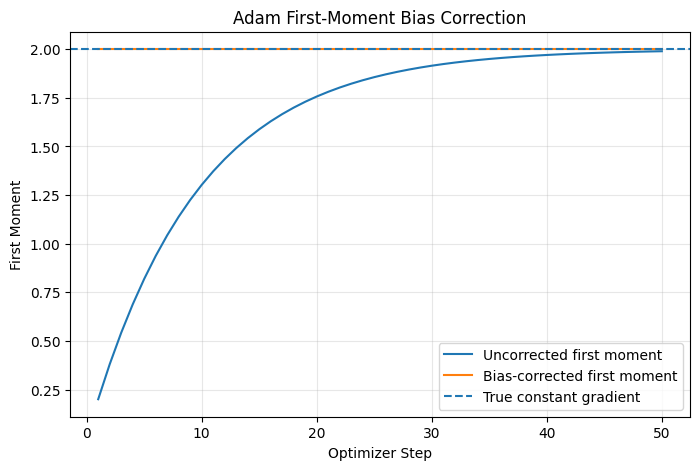

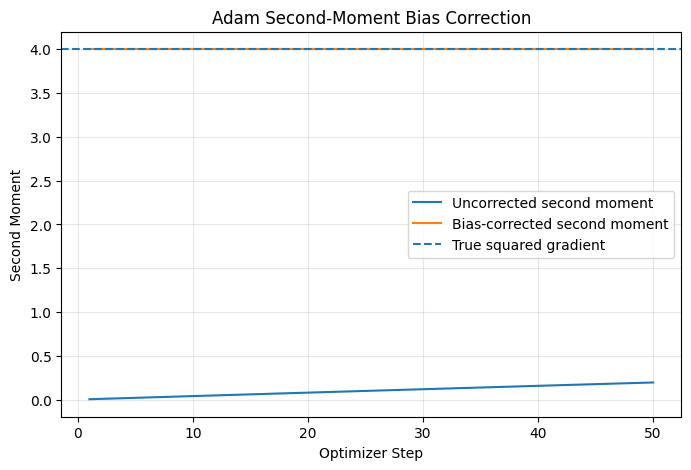

In [145]:
demonstrate_adam_bias_correction(

    gradient=2.0,

    steps=50,

    beta1=0.9,

    beta2=0.999,
)

In [146]:
adam_optimizer = Adam(

    learning_rate=0.05,

    beta1=0.9,

    beta2=0.999,

    epsilon=1e-8,
)

In [147]:
(
    adam_parameters,
    adam_history,
) = train_linear_regression_adaptive(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        adam_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 22.875477 | Validation loss: 18.484094 | Weight effective LR: 0.002840 | Bias effective LR: 0.013978
Epoch   10 | Train loss: 0.668616 | Validation loss: 0.675348 | Weight effective LR: 0.005506 | Bias effective LR: 0.025904
Epoch   20 | Train loss: 0.639997 | Validation loss: 0.629182 | Weight effective LR: 0.007965 | Bias effective LR: 0.036661
Epoch   30 | Train loss: 0.640046 | Validation loss: 0.629874 | Weight effective LR: 0.009974 | Bias effective LR: 0.045051
Epoch   40 | Train loss: 0.640091 | Validation loss: 0.630344 | Weight effective LR: 0.011779 | Bias effective LR: 0.052122
Epoch   50 | Train loss: 0.640189 | Validation loss: 0.626779 | Weight effective LR: 0.013470 | Bias effective LR: 0.058227
Epoch   60 | Train loss: 0.640179 | Validation loss: 0.631217 | Weight effective LR: 0.015090 | Bias effective LR: 0.063993
Epoch   70 | Train loss: 0.640095 | Validation loss: 0.630582 | Weight effective LR: 0.016687 | Bias effective LR: 0.069089
Epoch 

In [148]:
print(
    "\nTrue weight:    "
    "3.0000"
)

print(
    "Learned weight: "
    f"{adam_parameters['weight'].item():.4f}"
)


print(
    "\nTrue bias:      "
    "2.0000"
)

print(
    "Learned bias:   "
    f"{adam_parameters['bias'].item():.4f}"
)


print(
    "\nTotal optimizer updates:",
    adam_optimizer.step_count,
)


True weight:    3.0000
Learned weight: 3.0813

True bias:      2.0000
Learned bias:   2.0223

Total optimizer updates: 1000


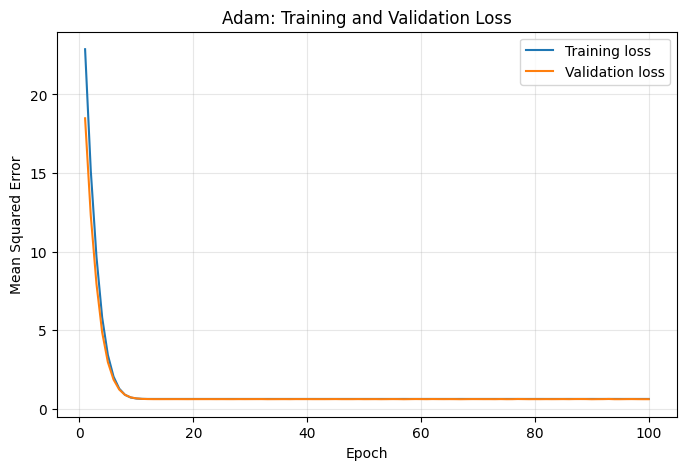

In [149]:
plot_losses(

    adam_history,

    title=(

        "Adam: "

        "Training and Validation Loss"
    ),
)

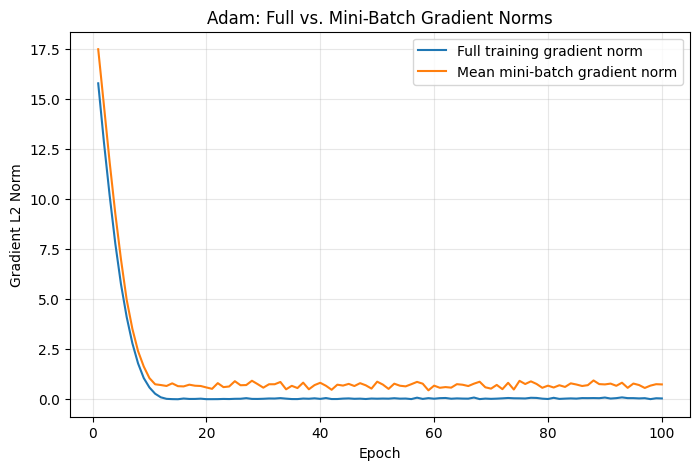

In [150]:
plot_sgd_gradient_norms(

    adam_history,

    title=(

        "Adam: "

        "Full vs. Mini-Batch "
        "Gradient Norms"
    ),
)

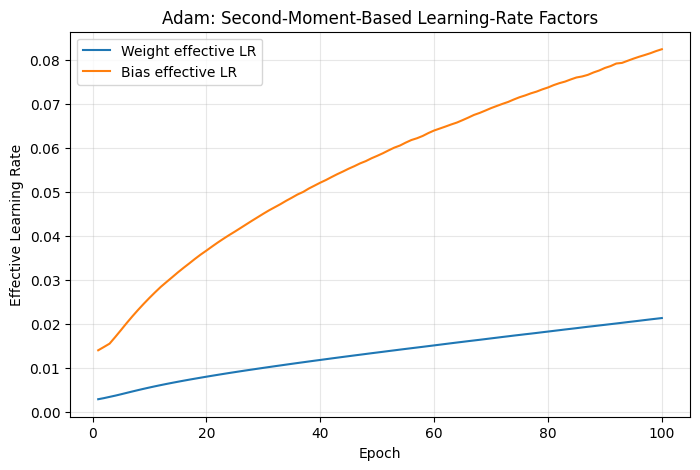

In [152]:
plot_effective_learning_rates(

    adam_history,

    title=(

        "Adam: "

        "Second-Moment-Based "
        "Learning-Rate Factors"
    ),
)

In [153]:
(
    final_corrected_first,
    final_corrected_second,
) = adam_optimizer.get_corrected_moments()


print(
    "Final uncorrected "
    "first moment for weight:"
)

print(
    adam_optimizer.first_moment[
        "weight"
    ]
)


print(
    "\nFinal corrected "
    "first moment for weight:"
)

print(
    final_corrected_first[
        "weight"
    ]
)


print(
    "\nFinal uncorrected "
    "second moment for weight:"
)

print(
    adam_optimizer.second_moment[
        "weight"
    ]
)


print(
    "\nFinal corrected "
    "second moment for weight:"
)

print(
    final_corrected_second[
        "weight"
    ]
)

Final uncorrected first moment for weight:
[[0.07823475]]

Final corrected first moment for weight:
[[0.07823475]]

Final uncorrected second moment for weight:
[[3.47974969]]

Final corrected second moment for weight:
[[5.5032809]]


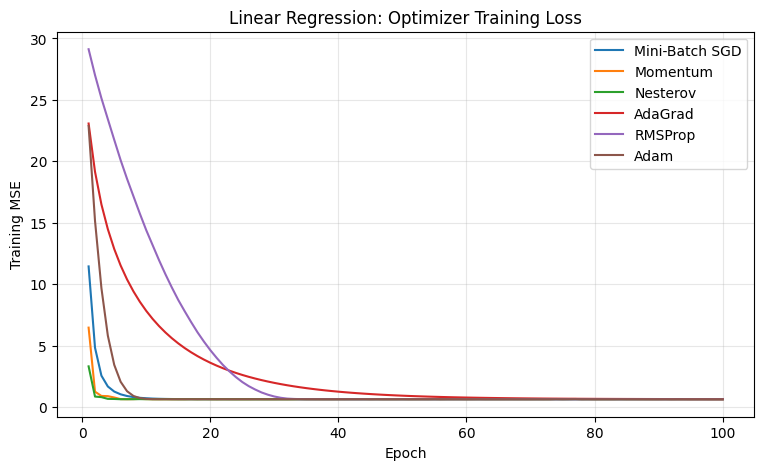

In [154]:
compare_loss_histories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,

        adam_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",

        "Adam",
    ],

    title=(

        "Linear Regression: "

        "Optimizer Training Loss"
    ),
)

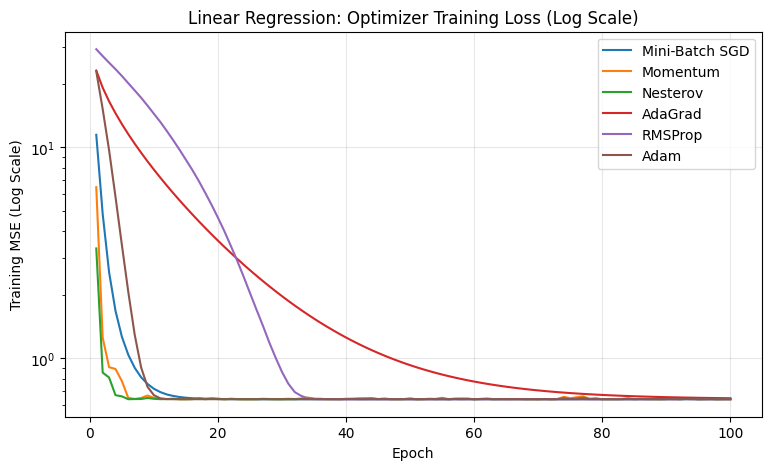

In [155]:
compare_loss_histories_log_scale(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,

        adam_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",

        "Adam",
    ],

    title=(

        "Linear Regression: "

        "Optimizer Training Loss "
        "(Log Scale)"
    ),
)

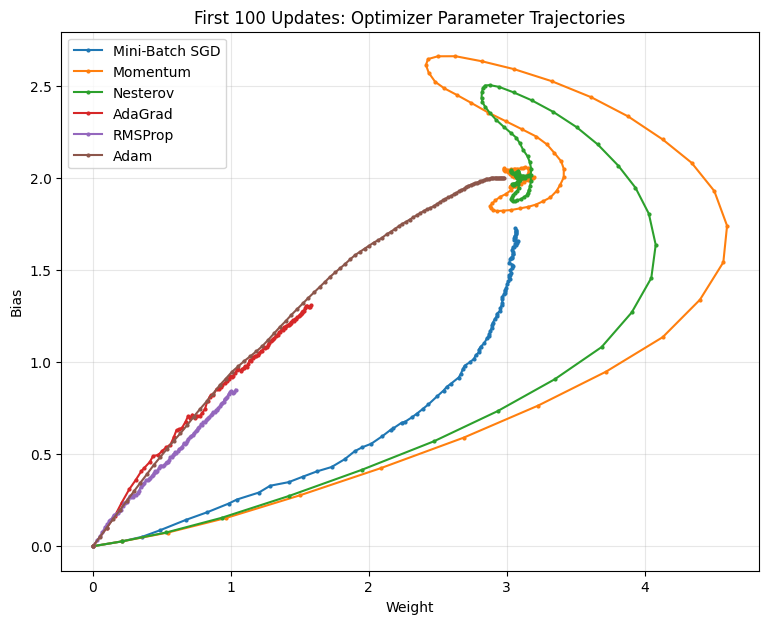

In [156]:
compare_early_trajectories(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,

        adam_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",

        "Adam",
    ],

    title=(

        "First 100 Updates: "

        "Optimizer Parameter "
        "Trajectories"
    ),

    number_of_updates=100,
)

In [157]:
def summarize_optimizer_results(
    names,
    parameters_list,
    histories,
    optimizers,
):
    """
    Print a compact summary of
    optimizer results.
    """

    header = (

        f"{'Optimizer':<15}"

        f"{'Weight':>12}"

        f"{'Bias':>12}"

        f"{'Train Loss':>16}"

        f"{'Val Loss':>16}"

        f"{'Updates':>12}"
    )


    print(
        header
    )


    print(
        "-" * len(header)
    )


    for (
        name,
        parameters,
        history,
        optimizer,
    ) in zip(

        names,

        parameters_list,

        histories,

        optimizers,
    ):


        print(

            f"{name:<15}"

            f"{parameters['weight'].item():>12.4f}"

            f"{parameters['bias'].item():>12.4f}"

            f"{history['train_loss'][-1]:>16.6f}"

            f"{history['validation_loss'][-1]:>16.6f}"

            f"{optimizer.step_count:>12d}"
        )

summarize_optimizer_results(

    names=[

        "SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",

        "Adam",
    ],

    parameters_list=[

        sgd_parameters,

        momentum_parameters,

        nesterov_parameters,

        tracked_adagrad_parameters,

        rmsprop_parameters,

        adam_parameters,
    ],

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,

        adam_history,
    ],

    optimizers=[

        sgd_optimizer,

        momentum_optimizer,

        nesterov_optimizer,

        tracked_adagrad_optimizer,

        rmsprop_optimizer,

        adam_optimizer,
    ],
)

Optimizer            Weight        Bias      Train Loss        Val Loss     Updates
-----------------------------------------------------------------------------------
SGD                  3.0737      2.0049        0.640067        0.629796        1000
Momentum             3.0903      2.0202        0.640701        0.623939        1000
Nesterov             3.0878      2.0201        0.640541        0.624497        1000
AdaGrad              3.0307      1.9945        0.646921        0.647474        1000
RMSProp              3.0700      2.0082        0.640243        0.630457        1000
Adam                 3.0813      2.0223        0.640393        0.625825        1000


In [158]:
assert (

    adam_history[
        "train_loss"
    ][-1]

    <

    adam_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    adam_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.3,
)


assert np.isclose(

    adam_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (

    adam_optimizer.step_count

    ==

    1000
)


assert (

    "weight"

    in

    adam_optimizer.first_moment
)


assert (

    "weight"

    in

    adam_optimizer.second_moment
)


assert np.all(

    adam_optimizer
    .second_moment[
        "weight"
    ]

    >= 0
)


assert np.all(

    adam_optimizer
    .second_moment[
        "bias"
    ]

    >= 0
)


assert (

    len(

        adam_history[
            "weight_effective_lr"
        ]
    )

    == 100
)


print(
    "All Adam checks passed."
)

All Adam checks passed.


# Part 9: AdamW and Weight Decay

AdamW combines Adam with decoupled weight decay.

Adam computes:

$$
m_t
=
\beta_1m_{t-1}
+
(1-\beta_1)g_t
$$

$$
v_t
=
\beta_2v_{t-1}
+
(1-\beta_2)g_t^2
$$

After bias correction:

$$
\hat m_t
=
\frac{m_t}
{1-\beta_1^t}
$$

$$
\hat v_t
=
\frac{v_t}
{1-\beta_2^t}
$$

AdamW updates parameters using:

$$
\theta_{t+1}
=
\theta_t
-
\eta
\frac{\hat m_t}
{\sqrt{\hat v_t}+\epsilon}
-
\eta\lambda\theta_t
$$

where:

- $\eta$ is the learning rate;
- $\lambda$ is the weight-decay coefficient;
- $\eta\lambda\theta_t$ is applied directly to the parameter;
- the decay term is not added to the gradient moments.

This is called decoupled weight decay because optimization
of the loss and parameter shrinkage are handled separately.

In [167]:
class AdamW(NumPyOptimizer):
    """
    Adam with decoupled and selective
    weight decay.

    By default, all parameters decay.

    To decay only selected parameters,
    provide:

        decay_parameter_names={
            "weight",
            ...
        }
    """

    def __init__(
        self,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        weight_decay=0.01,
        decay_parameter_names=None,
    ):

        super().__init__(
            learning_rate=learning_rate
        )


        if not 0.0 <= beta1 < 1.0:

            raise ValueError(
                "beta1 must satisfy "
                "0 <= beta1 < 1."
            )


        if not 0.0 <= beta2 < 1.0:

            raise ValueError(
                "beta2 must satisfy "
                "0 <= beta2 < 1."
            )


        if epsilon <= 0:

            raise ValueError(
                "epsilon must be "
                "greater than zero."
            )


        if weight_decay < 0:

            raise ValueError(
                "weight_decay must be "
                "greater than or equal "
                "to zero."
            )


        self.beta1 = beta1

        self.beta2 = beta2

        self.epsilon = epsilon

        self.weight_decay = (
            weight_decay
        )


        if (
            decay_parameter_names
            is None
        ):

            self.decay_parameter_names = (
                None
            )

        else:

            self.decay_parameter_names = (

                set(
                    decay_parameter_names
                )
            )


        self.first_moment = {}

        self.second_moment = {}


    def initialize_state(
        self,
        parameters,
    ):

        for name in parameters:

            if (
                name
                not in self.first_moment
            ):

                self.first_moment[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


            if (
                name
                not in self.second_moment
            ):

                self.second_moment[name] = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


    def should_decay(
        self,
        parameter_name,
    ):
        """
        Return True when a parameter
        should receive weight decay.
        """

        if (
            self.decay_parameter_names
            is None
        ):

            return True


        return (

            parameter_name

            in

            self.decay_parameter_names
        )


    def get_corrected_moments(
        self,
    ):

        if self.step_count == 0:

            raise ValueError(
                "AdamW has not performed "
                "an optimizer step yet."
            )


        corrected_first = {}

        corrected_second = {}


        for name in self.first_moment:


            corrected_first[name] = (

                self.first_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta1
                    ** self.step_count
                )
            )


            corrected_second[name] = (

                self.second_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta2
                    ** self.step_count
                )
            )


        return (
            corrected_first,
            corrected_second,
        )


    def get_effective_learning_rates(
        self,
    ):

        (
            _,
            corrected_second,
        ) = self.get_corrected_moments()


        effective_learning_rates = {}


        for name in corrected_second:

            effective_learning_rates[
                name
            ] = (

                self.learning_rate

                / (

                    np.sqrt(

                        corrected_second[
                            name
                        ]
                    )

                    + self.epsilon
                )
            )


        return effective_learning_rates


    def step(
        self,
        parameters,
        gradients,
    ):

        if (
            parameters.keys()
            != gradients.keys()
        ):

            raise ValueError(
                "Parameters and gradients "
                "must have the same keys."
            )


        self.initialize_state(
            parameters
        )


        self.step_count += 1


        for name in parameters:


            gradient = gradients[name]


            # ---------------------------
            # Adam moments
            # ---------------------------

            self.first_moment[name] = (

                self.beta1

                * self.first_moment[
                    name
                ]

                + (

                    1.0
                    - self.beta1

                )

                * gradient
            )


            self.second_moment[name] = (

                self.beta2

                * self.second_moment[
                    name
                ]

                + (

                    1.0
                    - self.beta2

                )

                * (
                    gradient ** 2
                )
            )


            # ---------------------------
            # Bias correction
            # ---------------------------

            corrected_first_moment = (

                self.first_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta1
                    ** self.step_count
                )
            )


            corrected_second_moment = (

                self.second_moment[
                    name
                ]

                / (

                    1.0

                    - self.beta2
                    ** self.step_count
                )
            )


            # ---------------------------
            # Adam update
            # ---------------------------

            adam_update = (

                self.learning_rate

                * corrected_first_moment

                / (

                    np.sqrt(
                        corrected_second_moment
                    )

                    + self.epsilon
                )
            )


            # ---------------------------
            # Selective weight decay
            # ---------------------------

            if self.should_decay(name):

                decay_update = (

                    self.learning_rate

                    * self.weight_decay

                    * parameters[name]
                )

            else:

                decay_update = (

                    np.zeros_like(
                        parameters[name]
                    )
                )


            # ---------------------------
            # Final AdamW update
            # ---------------------------

            parameters[name] -= (

                adam_update

                + decay_update
            )

In [168]:
selective_parameters = {

    "weight": np.array(
        [[10.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[10.0]],
        dtype=np.float64,
    ),
}


selective_zero_gradients = {

    "weight": np.array(
        [[0.0]],
        dtype=np.float64,
    ),

    "bias": np.array(
        [[0.0]],
        dtype=np.float64,
    ),
}

In [169]:
selective_adamw = AdamW(

    learning_rate=0.1,

    weight_decay=0.2,

    decay_parameter_names={
        "weight"
    },
)

In [170]:
selective_adamw.step(

    selective_parameters,

    selective_zero_gradients,
)


print(
    "Weight after update:"
)

print(
    selective_parameters[
        "weight"
    ]
)


print(
    "\nBias after update:"
)

print(
    selective_parameters[
        "bias"
    ]
)

Weight after update:
[[9.8]]

Bias after update:
[[10.]]


In [171]:
assert np.isclose(

    selective_parameters[
        "weight"
    ].item(),

    9.8,
)


assert np.isclose(

    selective_parameters[
        "bias"
    ].item(),

    10.0,
)


print(
    "Selective weight-decay "
    "check passed."
)

Selective weight-decay check passed.


In [172]:
adamw_optimizer = AdamW(

    learning_rate=0.05,

    beta1=0.9,

    beta2=0.999,

    epsilon=1e-8,

    weight_decay=0.01,

    decay_parameter_names={
        "weight"
    },
)

In [173]:
(
    adamw_parameters,
    adamw_history,
) = train_linear_regression_adaptive(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        adamw_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 22.892592 | Validation loss: 18.496814 | Weight effective LR: 0.002840 | Bias effective LR: 0.013978
Epoch   10 | Train loss: 0.701565 | Validation loss: 0.711166 | Weight effective LR: 0.005472 | Bias effective LR: 0.025828
Epoch   20 | Train loss: 0.643376 | Validation loss: 0.640537 | Weight effective LR: 0.007911 | Bias effective LR: 0.036555
Epoch   30 | Train loss: 0.642686 | Validation loss: 0.638777 | Weight effective LR: 0.009905 | Bias effective LR: 0.044941
Epoch   40 | Train loss: 0.641622 | Validation loss: 0.637334 | Weight effective LR: 0.011697 | Bias effective LR: 0.052011
Epoch   50 | Train loss: 0.641136 | Validation loss: 0.632493 | Weight effective LR: 0.013375 | Bias effective LR: 0.058095
Epoch   60 | Train loss: 0.641225 | Validation loss: 0.636546 | Weight effective LR: 0.014984 | Bias effective LR: 0.063832
Epoch   70 | Train loss: 0.640968 | Validation loss: 0.635410 | Weight effective LR: 0.016569 | Bias effective LR: 0.068931
Epoch 

In [174]:
(
    adamw_parameters,
    adamw_history,
) = train_linear_regression_adaptive(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        adamw_optimizer
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | Train loss: 12.392288 | Validation loss: 10.173380 | Weight effective LR: 0.016055 | Bias effective LR: 0.067565
Epoch   10 | Train loss: 0.641126 | Validation loss: 0.636610 | Weight effective LR: 0.016151 | Bias effective LR: 0.068323
Epoch   20 | Train loss: 0.641010 | Validation loss: 0.635993 | Weight effective LR: 0.017318 | Bias effective LR: 0.071678
Epoch   30 | Train loss: 0.641074 | Validation loss: 0.634884 | Weight effective LR: 0.018486 | Bias effective LR: 0.075158
Epoch   40 | Train loss: 0.640458 | Validation loss: 0.633536 | Weight effective LR: 0.019679 | Bias effective LR: 0.078452
Epoch   50 | Train loss: 0.640873 | Validation loss: 0.629076 | Weight effective LR: 0.020896 | Bias effective LR: 0.081431
Epoch   60 | Train loss: 0.640782 | Validation loss: 0.634727 | Weight effective LR: 0.022131 | Bias effective LR: 0.084667
Epoch   70 | Train loss: 0.640461 | Validation loss: 0.633307 | Weight effective LR: 0.023423 | Bias effective LR: 0.087552
Epoch 

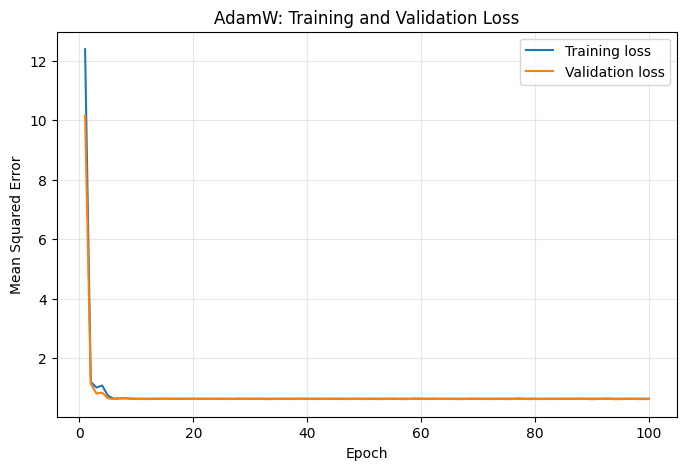

In [175]:
plot_losses(

    adamw_history,

    title=(

        "AdamW: "

        "Training and Validation Loss"
    ),
)

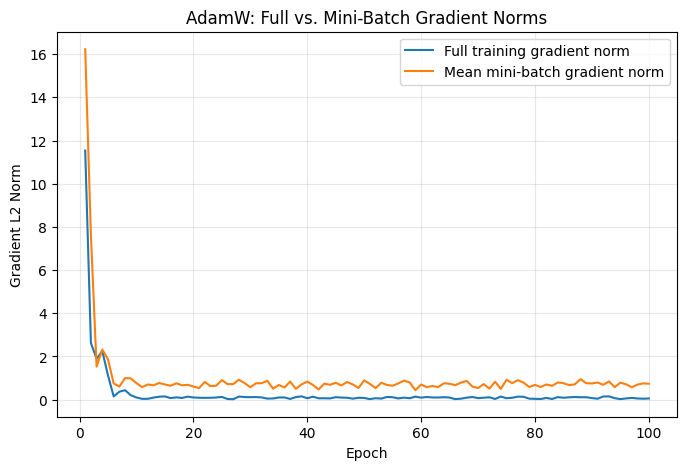

In [176]:
plot_sgd_gradient_norms(

    adamw_history,

    title=(

        "AdamW: "

        "Full vs. Mini-Batch "
        "Gradient Norms"
    ),
)

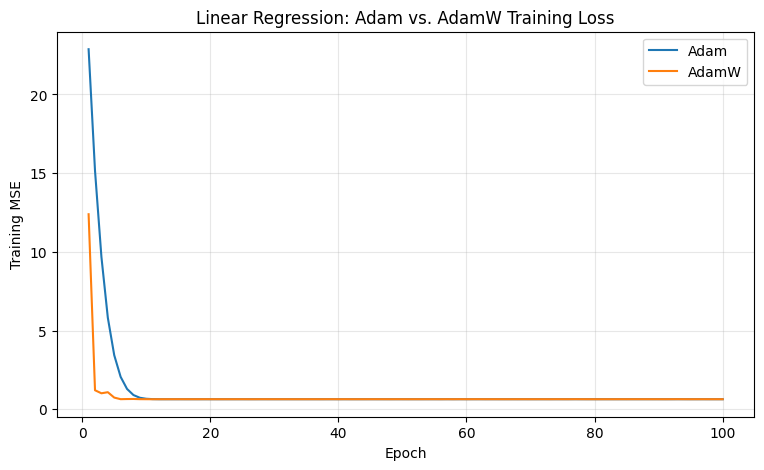

In [177]:
compare_loss_histories(

    histories=[

        adam_history,

        adamw_history,
    ],

    labels=[

        "Adam",

        "AdamW",
    ],

    title=(

        "Linear Regression: "

        "Adam vs. AdamW "
        "Training Loss"
    ),
)

In [178]:
print(
    f"{'Optimizer':<12}"
    f"{'Weight':>12}"
    f"{'Bias':>12}"
    f"{'Train Loss':>16}"
    f"{'Val Loss':>16}"
)


print(
    "-" * 68
)


print(

    f"{'Adam':<12}"

    f"{adam_parameters['weight'].item():>12.4f}"

    f"{adam_parameters['bias'].item():>12.4f}"

    f"{adam_history['train_loss'][-1]:>16.6f}"

    f"{adam_history['validation_loss'][-1]:>16.6f}"
)


print(

    f"{'AdamW':<12}"

    f"{adamw_parameters['weight'].item():>12.4f}"

    f"{adamw_parameters['bias'].item():>12.4f}"

    f"{adamw_history['train_loss'][-1]:>16.6f}"

    f"{adamw_history['validation_loss'][-1]:>16.6f}"
)

Optimizer         Weight        Bias      Train Loss        Val Loss
--------------------------------------------------------------------
Adam              3.0813      2.0223        0.640393        0.625825
AdamW             3.0717      2.0202        0.640447        0.628637


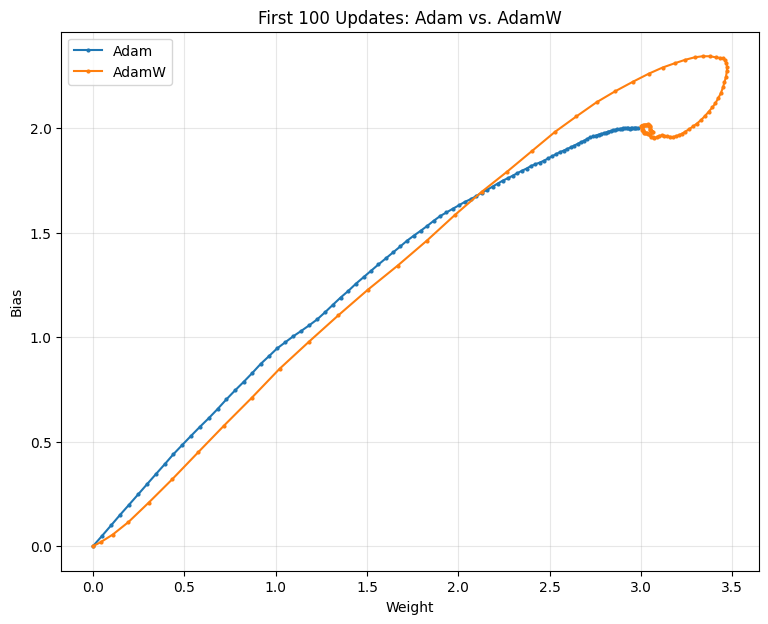

In [179]:
compare_early_trajectories(

    histories=[

        adam_history,

        adamw_history,
    ],

    labels=[

        "Adam",

        "AdamW",
    ],

    title=(

        "First 100 Updates: "

        "Adam vs. AdamW"
    ),

    number_of_updates=100,
)

In [180]:
def demonstrate_repeated_weight_decay(
    initial_parameter=10.0,
    learning_rate=0.1,
    weight_decay=0.2,
    steps=100,
):
    """
    Demonstrate exponential parameter
    shrinkage under pure weight decay.
    """

    parameter = (
        initial_parameter
    )


    parameter_values = [
        parameter
    ]


    for _ in range(steps):

        parameter *= (

            1.0

            - learning_rate
            * weight_decay
        )


        parameter_values.append(
            parameter
        )


    step_numbers = np.arange(

        0,

        steps + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        step_numbers,

        parameter_values,
    )


    plt.xlabel(
        "Optimizer Step"
    )


    plt.ylabel(
        "Parameter Value"
    )


    plt.title(
        "Repeated Decoupled "
        "Weight Decay"
    )


    plt.grid(
        alpha=0.3
    )


    plt.show()


    return parameter_values

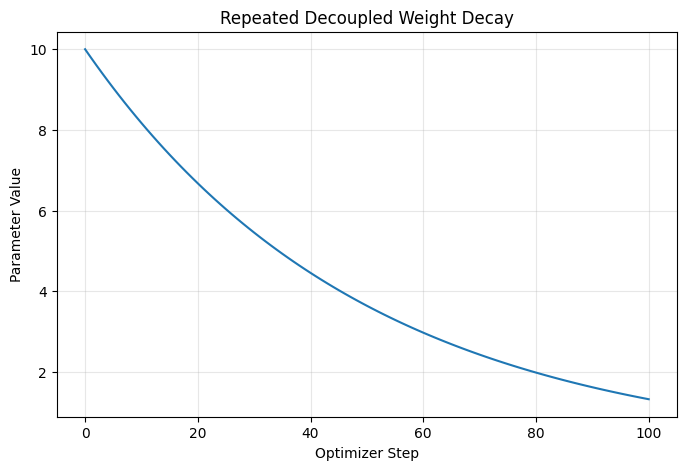

Repeated decay matches the closed-form equation.


In [182]:
decay_values = (

    demonstrate_repeated_weight_decay(

        initial_parameter=10.0,

        learning_rate=0.1,

        weight_decay=0.2,

        steps=100,
    )
)

expected_final_value = (

    10.0

    * (

        1.0

        - 0.1 * 0.2

    ) ** 100
)


assert np.isclose(

    decay_values[-1],

    expected_final_value,
)


print(
    "Repeated decay matches "
    "the closed-form equation."
)

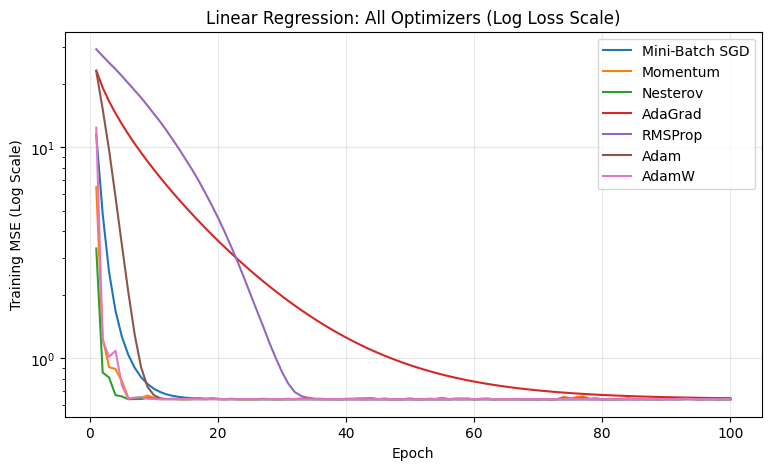

In [183]:
compare_loss_histories_log_scale(

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,

        adam_history,

        adamw_history,
    ],

    labels=[

        "Mini-Batch SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",

        "Adam",

        "AdamW",
    ],

    title=(

        "Linear Regression: "

        "All Optimizers "
        "(Log Loss Scale)"
    ),
)

In [184]:
summarize_optimizer_results(

    names=[

        "SGD",

        "Momentum",

        "Nesterov",

        "AdaGrad",

        "RMSProp",

        "Adam",

        "AdamW",
    ],

    parameters_list=[

        sgd_parameters,

        momentum_parameters,

        nesterov_parameters,

        tracked_adagrad_parameters,

        rmsprop_parameters,

        adam_parameters,

        adamw_parameters,
    ],

    histories=[

        sgd_history,

        momentum_history,

        nesterov_history,

        tracked_adagrad_history,

        rmsprop_history,

        adam_history,

        adamw_history,
    ],

    optimizers=[

        sgd_optimizer,

        momentum_optimizer,

        nesterov_optimizer,

        tracked_adagrad_optimizer,

        rmsprop_optimizer,

        adam_optimizer,

        adamw_optimizer,
    ],
)

Optimizer            Weight        Bias      Train Loss        Val Loss     Updates
-----------------------------------------------------------------------------------
SGD                  3.0737      2.0049        0.640067        0.629796        1000
Momentum             3.0903      2.0202        0.640701        0.623939        1000
Nesterov             3.0878      2.0201        0.640541        0.624497        1000
AdaGrad              3.0307      1.9945        0.646921        0.647474        1000
RMSProp              3.0700      2.0082        0.640243        0.630457        1000
Adam                 3.0813      2.0223        0.640393        0.625825        1000
AdamW                3.0717      2.0202        0.640447        0.628637        2000


In [186]:
assert (

    adamw_history[
        "train_loss"
    ][-1]

    <

    adamw_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    adamw_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.4,
)


assert np.isclose(

    adamw_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (

    adamw_optimizer.step_count

    ==

    2000
)


assert (

    adamw_optimizer.should_decay(
        "weight"
    )
)


assert not (

    adamw_optimizer.should_decay(
        "bias"
    )
)


assert np.all(

    adamw_optimizer
    .second_moment[
        "weight"
    ]

    >= 0
)


assert (

    len(

        adamw_history[
            "weight_effective_lr"
        ]
    )

    == 100
)


print(
    "All AdamW checks passed."
)

All AdamW checks passed.


# Part 10: Learning-Rate Schedulers

A learning-rate scheduler changes the optimizer's base
learning rate during training.

Instead of:

$$
\eta_t
=
\eta_0
$$

we use:

$$
\eta_t
=
f(t)
$$

where:

- $\eta_0$ is the initial learning rate;
- $t$ is the scheduler step;
- $f$ defines how the learning rate changes.

We will implement:

1. Step decay;
2. Exponential decay;
3. Cosine annealing;
4. Linear warmup.

For simplicity, the schedulers will update the learning
rate once per epoch.

In [187]:
class NumPyLRScheduler:
    """
    Base class for NumPy
    learning-rate schedulers.
    """

    def __init__(
        self,
        optimizer,
    ):

        if not hasattr(
            optimizer,
            "learning_rate",
        ):

            raise ValueError(
                "The optimizer must have "
                "a learning_rate attribute."
            )


        self.optimizer = optimizer


        self.initial_learning_rate = (

            optimizer.learning_rate
        )


        self.step_count = 0


    def get_learning_rate(
        self,
        step,
    ):

        raise NotImplementedError


    def step(
        self,
    ):
        """
        Advance the scheduler by one step
        and update the optimizer's
        learning rate.
        """

        self.step_count += 1


        new_learning_rate = (

            self.get_learning_rate(

                self.step_count
            )
        )


        self.optimizer.learning_rate = (

            float(
                new_learning_rate
            )
        )


        return (
            self.optimizer.learning_rate
        )

In [188]:
class StepLR(NumPyLRScheduler):
    """
    Multiply the initial learning rate
    by gamma every step_size scheduler
    steps.

    Formula:

        lr =
            initial_lr

            * gamma
              ** floor(
                    step
                    / step_size
                 )
    """

    def __init__(
        self,
        optimizer,
        step_size,
        gamma=0.1,
    ):

        super().__init__(
            optimizer=optimizer
        )


        if step_size <= 0:

            raise ValueError(
                "step_size must be "
                "greater than zero."
            )


        if not 0.0 < gamma <= 1.0:

            raise ValueError(
                "gamma must satisfy "
                "0 < gamma <= 1."
            )


        self.step_size = step_size

        self.gamma = gamma


    def get_learning_rate(
        self,
        step,
    ):

        number_of_decays = (

            step

            // self.step_size
        )


        return (

            self.initial_learning_rate

            * (

                self.gamma

                ** number_of_decays
            )
        )

In [189]:
step_test_optimizer = SGD(
    learning_rate=0.1
)

step_scheduler = StepLR(

    optimizer=(
        step_test_optimizer
    ),

    step_size=10,

    gamma=0.5,
)

In [190]:
step_lr_values = [

    step_test_optimizer
    .learning_rate
]


for _ in range(30):

    step_scheduler.step()


    step_lr_values.append(

        step_test_optimizer
        .learning_rate
    )

In [191]:
for step in [

    0,

    1,

    9,

    10,

    19,

    20,

    30,
]:

    print(

        f"Step {step:2d}: "

        f"{step_lr_values[step]:.6f}"
    )

assert np.isclose(

    step_lr_values[0],

    0.1,
)


assert np.isclose(

    step_lr_values[10],

    0.05,
)


assert np.isclose(

    step_lr_values[20],

    0.025,
)


print(
    "StepLR checks passed."
)

Step  0: 0.100000
Step  1: 0.100000
Step  9: 0.100000
Step 10: 0.050000
Step 19: 0.050000
Step 20: 0.025000
Step 30: 0.012500
StepLR checks passed.


In [192]:
class ExponentialLR(
    NumPyLRScheduler
):
    """
    Exponentially decay the learning rate.

    Formula:

        lr =
            initial_lr
            * gamma ** step
    """

    def __init__(
        self,
        optimizer,
        gamma=0.99,
    ):

        super().__init__(
            optimizer=optimizer
        )


        if not 0.0 < gamma <= 1.0:

            raise ValueError(
                "gamma must satisfy "
                "0 < gamma <= 1."
            )


        self.gamma = gamma


    def get_learning_rate(
        self,
        step,
    ):

        return (

            self.initial_learning_rate

            * (

                self.gamma

                ** step
            )
        )

In [193]:
exponential_test_optimizer = SGD(

    learning_rate=0.1
)


exponential_scheduler = (

    ExponentialLR(

        optimizer=(
            exponential_test_optimizer
        ),

        gamma=0.95,
    )
)

In [195]:
exponential_lr_values = [

    exponential_test_optimizer
    .learning_rate
]


for _ in range(20):

    exponential_scheduler.step()


    exponential_lr_values.append(

        exponential_test_optimizer
        .learning_rate
    )

In [196]:
for step in [

    0,

    1,

    2,

    5,

    10,

    20,
]:

    print(

        f"Step {step:2d}: "

        f"{exponential_lr_values[step]:.6f}"
    )

assert np.isclose(

    exponential_lr_values[0],

    0.1,
)


assert np.isclose(

    exponential_lr_values[1],

    0.1 * 0.95,
)


assert np.isclose(

    exponential_lr_values[10],

    0.1 * 0.95 ** 10,
)


print(
    "ExponentialLR checks passed."
)

Step  0: 0.100000
Step  1: 0.095000
Step  2: 0.090250
Step  5: 0.077378
Step 10: 0.059874
Step 20: 0.035849
ExponentialLR checks passed.


In [197]:
class CosineAnnealingLR(
    NumPyLRScheduler
):
    """
    Smoothly decrease the learning rate
    from the initial value to min_lr.

    Formula:

        lr =
            min_lr

            + 0.5

            * (
                initial_lr
                - min_lr
              )

            * (
                1
                + cos(
                    pi
                    * progress
                  )
              )

    where:

        progress =
            min(
                step / total_steps,
                1
            )
    """

    def __init__(
        self,
        optimizer,
        total_steps,
        min_lr=0.0,
    ):

        super().__init__(
            optimizer=optimizer
        )


        if total_steps <= 0:

            raise ValueError(
                "total_steps must be "
                "greater than zero."
            )


        if min_lr < 0:

            raise ValueError(
                "min_lr must be "
                "greater than or equal "
                "to zero."
            )


        if (
            min_lr

            > self.initial_learning_rate
        ):

            raise ValueError(
                "min_lr cannot be larger "
                "than the initial "
                "learning rate."
            )


        self.total_steps = (
            total_steps
        )


        self.min_lr = min_lr


    def get_learning_rate(
        self,
        step,
    ):

        progress = min(

            step

            / self.total_steps,

            1.0,
        )


        cosine_factor = (

            0.5

            * (

                1.0

                + np.cos(

                    np.pi

                    * progress
                )
            )
        )


        return (

            self.min_lr

            + (

                self.initial_learning_rate

                - self.min_lr

            )

            * cosine_factor
        )

In [198]:
cosine_test_optimizer = SGD(

    learning_rate=0.1
)


cosine_scheduler = (

    CosineAnnealingLR(

        optimizer=(
            cosine_test_optimizer
        ),

        total_steps=100,

        min_lr=0.001,
    )
)

In [199]:
cosine_lr_values = [

    cosine_test_optimizer
    .learning_rate
]


for _ in range(100):

    cosine_scheduler.step()


    cosine_lr_values.append(

        cosine_test_optimizer
        .learning_rate
    )

In [200]:
for step in [

    0,

    25,

    50,

    75,

    100,
]:

    print(

        f"Step {step:3d}: "

        f"{cosine_lr_values[step]:.6f}"
    )

expected_midpoint = (

    0.001

    + 0.5

    * (
        0.1
        - 0.001
    )
)


assert np.isclose(

    cosine_lr_values[0],

    0.1,
)


assert np.isclose(

    cosine_lr_values[50],

    expected_midpoint,
)


assert np.isclose(

    cosine_lr_values[100],

    0.001,
)


print(
    "CosineAnnealingLR "
    "checks passed."
)

Step   0: 0.100000
Step  25: 0.085502
Step  50: 0.050500
Step  75: 0.015498
Step 100: 0.001000
CosineAnnealingLR checks passed.


In [201]:
class LinearWarmupLR(
    NumPyLRScheduler
):
    """
    Linearly increase the learning rate
    from start_lr to the optimizer's
    original learning rate.

    After warmup_steps, keep the
    learning rate constant.
    """

    def __init__(
        self,
        optimizer,
        warmup_steps,
        start_lr=0.0,
    ):

        super().__init__(
            optimizer=optimizer
        )


        if warmup_steps <= 0:

            raise ValueError(
                "warmup_steps must be "
                "greater than zero."
            )


        if start_lr < 0:

            raise ValueError(
                "start_lr must be "
                "greater than or equal "
                "to zero."
            )


        if (

            start_lr

            > self.initial_learning_rate
        ):

            raise ValueError(
                "start_lr cannot be "
                "larger than the target "
                "learning rate."
            )


        self.warmup_steps = (
            warmup_steps
        )


        self.start_lr = start_lr


        # Training should begin using
        # the warmup starting LR.

        self.optimizer.learning_rate = (

            float(
                start_lr
            )
        )


    def get_learning_rate(
        self,
        step,
    ):

        if (
            step

            >= self.warmup_steps
        ):

            return (

                self.initial_learning_rate
            )


        progress = (

            step

            / self.warmup_steps
        )


        return (

            self.start_lr

            + progress

            * (

                self.initial_learning_rate

                - self.start_lr
            )
        )

In [202]:
warmup_test_optimizer = SGD(

    learning_rate=0.1
)


warmup_scheduler = (

    LinearWarmupLR(

        optimizer=(
            warmup_test_optimizer
        ),

        warmup_steps=10,

        start_lr=0.0,
    )
)

print(

    "Initial optimizer LR:",

    warmup_test_optimizer
    .learning_rate
)

Initial optimizer LR: 0.0


In [203]:
warmup_lr_values = [

    warmup_test_optimizer
    .learning_rate
]


for _ in range(15):

    warmup_scheduler.step()


    warmup_lr_values.append(

        warmup_test_optimizer
        .learning_rate
    )

for step in [

    0,

    1,

    5,

    10,

    15,
]:

    print(

        f"Step {step:2d}: "

        f"{warmup_lr_values[step]:.6f}"
    )

assert np.isclose(

    warmup_lr_values[0],

    0.0,
)


assert np.isclose(

    warmup_lr_values[5],

    0.05,
)


assert np.isclose(

    warmup_lr_values[10],

    0.1,
)


assert np.isclose(

    warmup_lr_values[15],

    0.1,
)


print(
    "LinearWarmupLR checks passed."
)

Step  0: 0.000000
Step  1: 0.010000
Step  5: 0.050000
Step 10: 0.100000
Step 15: 0.100000
LinearWarmupLR checks passed.


In [204]:
def generate_scheduler_history(
    optimizer,
    scheduler,
    number_of_steps,
):
    """
    Generate a learning-rate sequence.

    The first value is the optimizer's
    learning rate before scheduler.step().
    """

    learning_rates = [

        optimizer.learning_rate
    ]


    for _ in range(
        number_of_steps
    ):

        scheduler.step()


        learning_rates.append(

            optimizer.learning_rate
        )


    return learning_rates

step_plot_optimizer = SGD(

    learning_rate=0.1
)


step_plot_scheduler = StepLR(

    optimizer=(
        step_plot_optimizer
    ),

    step_size=20,

    gamma=0.5,
)


exponential_plot_optimizer = SGD(

    learning_rate=0.1
)


exponential_plot_scheduler = (

    ExponentialLR(

        optimizer=(
            exponential_plot_optimizer
        ),

        gamma=0.97,
    )
)


cosine_plot_optimizer = SGD(

    learning_rate=0.1
)


cosine_plot_scheduler = (

    CosineAnnealingLR(

        optimizer=(
            cosine_plot_optimizer
        ),

        total_steps=100,

        min_lr=0.001,
    )
)


warmup_plot_optimizer = SGD(

    learning_rate=0.1
)


warmup_plot_scheduler = (

    LinearWarmupLR(

        optimizer=(
            warmup_plot_optimizer
        ),

        warmup_steps=20,

        start_lr=0.0,
    )
)

In [205]:
step_plot_values = (

    generate_scheduler_history(

        optimizer=(
            step_plot_optimizer
        ),

        scheduler=(
            step_plot_scheduler
        ),

        number_of_steps=100,
    )
)


exponential_plot_values = (

    generate_scheduler_history(

        optimizer=(
            exponential_plot_optimizer
        ),

        scheduler=(
            exponential_plot_scheduler
        ),

        number_of_steps=100,
    )
)


cosine_plot_values = (

    generate_scheduler_history(

        optimizer=(
            cosine_plot_optimizer
        ),

        scheduler=(
            cosine_plot_scheduler
        ),

        number_of_steps=100,
    )
)


warmup_plot_values = (

    generate_scheduler_history(

        optimizer=(
            warmup_plot_optimizer
        ),

        scheduler=(
            warmup_plot_scheduler
        ),

        number_of_steps=100,
    )
)

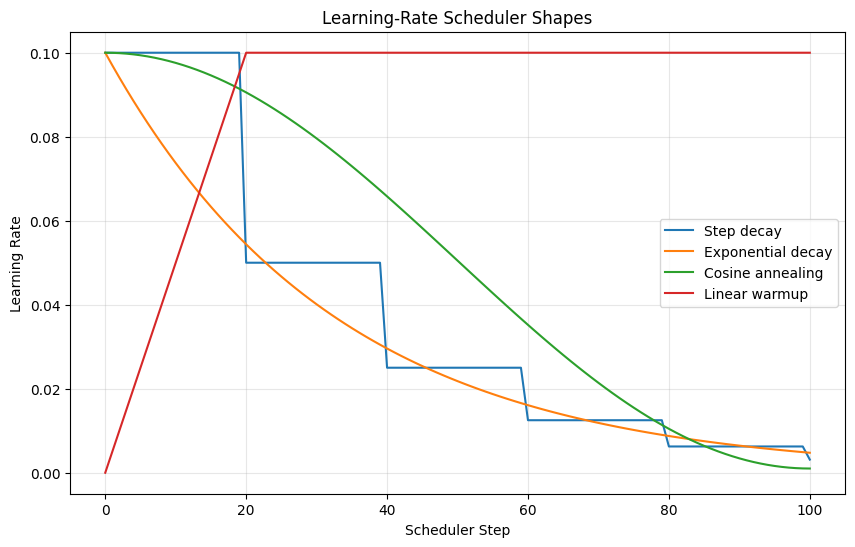

In [206]:
scheduler_steps = np.arange(

    0,

    101,
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    scheduler_steps,

    step_plot_values,

    label="Step decay",
)


plt.plot(

    scheduler_steps,

    exponential_plot_values,

    label="Exponential decay",
)


plt.plot(

    scheduler_steps,

    cosine_plot_values,

    label="Cosine annealing",
)


plt.plot(

    scheduler_steps,

    warmup_plot_values,

    label="Linear warmup",
)


plt.xlabel(
    "Scheduler Step"
)


plt.ylabel(
    "Learning Rate"
)


plt.title(
    "Learning-Rate Scheduler Shapes"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.show()

In [207]:
def train_linear_regression_with_scheduler(
    X_train,
    y_train,
    X_validation,
    y_validation,
    optimizer,
    scheduler=None,
    epochs=100,
    batch_size=16,
    initial_weight=0.0,
    initial_bias=0.0,
    shuffle=True,
    seed=42,
    print_every=10,
):
    """
    Train linear regression with an
    optional epoch-level scheduler.

    The learning rate stored for each
    epoch is the learning rate actually
    used during that epoch.

    scheduler.step() is called at the
    end of every epoch.
    """

    parameters = {

        "weight": np.array(
            [[initial_weight]],
            dtype=np.float64,
        ),

        "bias": np.array(
            [[initial_bias]],
            dtype=np.float64,
        ),
    }


    history = (
        create_sgd_history()
    )


    rng = np.random.default_rng(
        seed=seed
    )


    history["weight"].append(

        parameters[
            "weight"
        ].item()
    )


    history["bias"].append(

        parameters[
            "bias"
        ].item()
    )


    history[
        "update_weight"
    ].append(

        parameters[
            "weight"
        ].item()
    )


    history[
        "update_bias"
    ].append(

        parameters[
            "bias"
        ].item()
    )


    for epoch in range(
        1,
        epochs + 1,
    ):


        # Save the LR actually used
        # during this epoch.

        epoch_learning_rate = (

            optimizer.learning_rate
        )


        batch_gradient_norms = []

        updates_this_epoch = 0


        mini_batches = (

            create_mini_batches(

                X=X_train,

                y=y_train,

                batch_size=batch_size,

                shuffle=shuffle,

                rng=rng,
            )
        )


        for (
            X_batch,
            y_batch,
        ) in mini_batches:


            batch_predictions = (

                linear_model(

                    X_batch,

                    parameters[
                        "weight"
                    ],

                    parameters[
                        "bias"
                    ],
                )
            )


            (
                weight_gradient,
                bias_gradient,
            ) = (

                linear_regression_gradients(

                    X_batch,

                    batch_predictions,

                    y_batch,
                )
            )


            gradients = {

                "weight":
                    weight_gradient,

                "bias":
                    bias_gradient,
            }


            batch_gradient_norm = (

                compute_global_gradient_norm(
                    gradients
                )
            )


            batch_gradient_norms.append(

                batch_gradient_norm
            )


            history[
                "update_gradient_norm"
            ].append(

                batch_gradient_norm
            )


            optimizer.step(

                parameters,

                gradients,
            )


            updates_this_epoch += 1


            history[
                "update_weight"
            ].append(

                parameters[
                    "weight"
                ].item()
            )


            history[
                "update_bias"
            ].append(

                parameters[
                    "bias"
                ].item()
            )


        # ===================================
        # End-of-epoch evaluation
        # ===================================

        train_predictions = (

            linear_model(

                X_train,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        train_loss = (

            mean_squared_error(

                train_predictions,

                y_train,
            )
        )


        validation_predictions = (

            linear_model(

                X_validation,

                parameters[
                    "weight"
                ],

                parameters[
                    "bias"
                ],
            )
        )


        validation_loss = (

            mean_squared_error(

                validation_predictions,

                y_validation,
            )
        )


        (
            full_weight_gradient,
            full_bias_gradient,
        ) = (

            linear_regression_gradients(

                X_train,

                train_predictions,

                y_train,
            )
        )


        full_gradients = {

            "weight":
                full_weight_gradient,

            "bias":
                full_bias_gradient,
        }


        full_gradient_norm = (

            compute_global_gradient_norm(

                full_gradients
            )
        )


        mean_batch_gradient_norm = (

            float(

                np.mean(
                    batch_gradient_norms
                )
            )
        )


        # ===================================
        # Save metrics
        # ===================================

        history[
            "train_loss"
        ].append(
            train_loss
        )


        history[
            "validation_loss"
        ].append(
            validation_loss
        )


        history[
            "gradient_norm"
        ].append(
            full_gradient_norm
        )


        history[
            "mean_batch_gradient_norm"
        ].append(
            mean_batch_gradient_norm
        )


        history[
            "learning_rate"
        ].append(
            epoch_learning_rate
        )


        history[
            "weight"
        ].append(

            parameters[
                "weight"
            ].item()
        )


        history[
            "bias"
        ].append(

            parameters[
                "bias"
            ].item()
        )


        history[
            "updates_per_epoch"
        ].append(

            updates_this_epoch
        )


        # ===================================
        # Print progress
        # ===================================

        if (
            epoch == 1

            or epoch % print_every == 0

            or epoch == epochs
        ):

            print(

                f"Epoch {epoch:4d} | "

                f"LR: "
                f"{epoch_learning_rate:.6f} | "

                f"Train loss: "
                f"{train_loss:.6f} | "

                f"Validation loss: "
                f"{validation_loss:.6f}"
            )


        # Prepare the learning rate
        # for the next epoch.

        if scheduler is not None:

            scheduler.step()


    return parameters, history

In [209]:
scheduled_momentum_optimizer = (

    SGDMomentum(

        learning_rate=0.03,

        momentum=0.9,
    )
)

cosine_momentum_scheduler = (

    CosineAnnealingLR(

        optimizer=(
            scheduled_momentum_optimizer
        ),

        total_steps=100,

        min_lr=0.0001,
    )
)

(
    scheduled_momentum_parameters,
    scheduled_momentum_history,
) = train_linear_regression_with_scheduler(

    X_train=X_train,

    y_train=y_train,

    X_validation=(
        X_validation
    ),

    y_validation=(
        y_validation
    ),

    optimizer=(
        scheduled_momentum_optimizer
    ),

    scheduler=(
        cosine_momentum_scheduler
    ),

    epochs=100,

    batch_size=16,

    initial_weight=0.0,

    initial_bias=0.0,

    shuffle=True,

    seed=42,

    print_every=10,
)

Epoch    1 | LR: 0.030000 | Train loss: 2.631152 | Validation loss: 1.970971
Epoch   10 | LR: 0.029406 | Train loss: 0.695566 | Validation loss: 0.639047
Epoch   20 | LR: 0.027415 | Train loss: 0.646657 | Validation loss: 0.646732
Epoch   30 | LR: 0.024213 | Train loss: 0.700318 | Validation loss: 0.645560
Epoch   40 | LR: 0.020114 | Train loss: 0.647127 | Validation loss: 0.628404
Epoch   50 | LR: 0.015520 | Train loss: 0.649055 | Validation loss: 0.617142
Epoch   60 | LR: 0.010879 | Train loss: 0.640045 | Validation loss: 0.628941
Epoch   70 | LR: 0.006647 | Train loss: 0.640218 | Validation loss: 0.628524
Epoch   80 | LR: 0.003237 | Train loss: 0.640069 | Validation loss: 0.627545
Epoch   90 | LR: 0.000984 | Train loss: 0.640045 | Validation loss: 0.627999
Epoch  100 | LR: 0.000107 | Train loss: 0.640002 | Validation loss: 0.628497


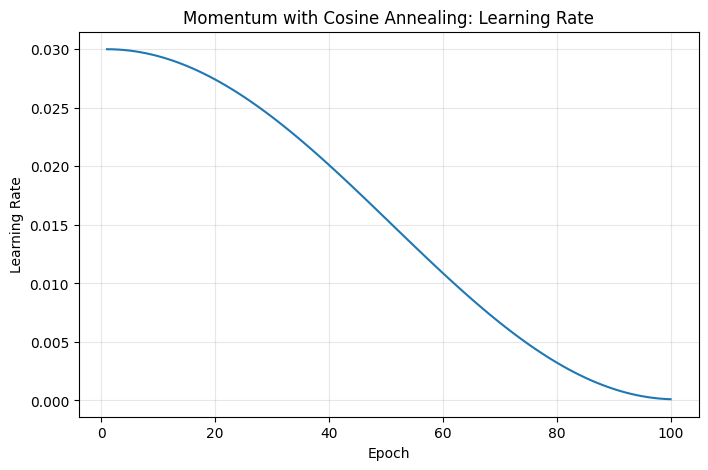

In [211]:
def plot_learning_rate_history(
    history,
    title,
):
    """
    Plot the base learning rate used
    during each epoch.
    """

    epochs = np.arange(

        1,

        len(

            history[
                "learning_rate"
            ]

        ) + 1,
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        epochs,

        history[
            "learning_rate"
        ],
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Learning Rate"
    )


    plt.title(
        title
    )


    plt.grid(
        alpha=0.3
    )


    plt.show()

plot_learning_rate_history(

    scheduled_momentum_history,

    title=(

        "Momentum with "
        "Cosine Annealing: "

        "Learning Rate"
    ),
)

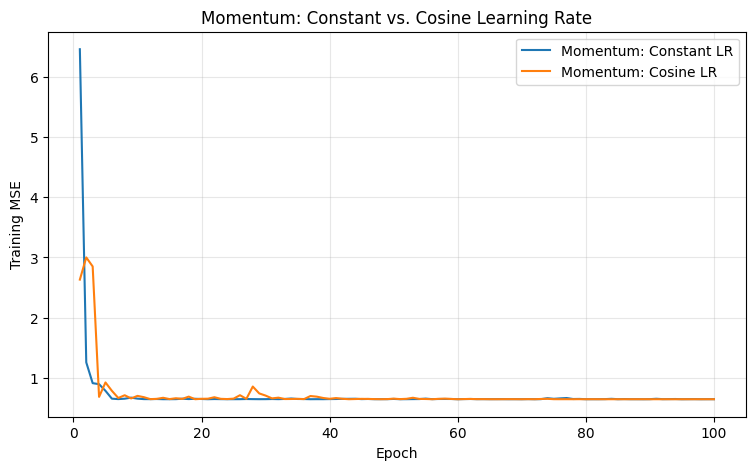

In [213]:
compare_loss_histories(

    histories=[

        momentum_history,

        scheduled_momentum_history,
    ],

    labels=[

        "Momentum: Constant LR",

        "Momentum: Cosine LR",
    ],

    title=(

        "Momentum: "

        "Constant vs. "
        "Cosine Learning Rate"
    ),
)

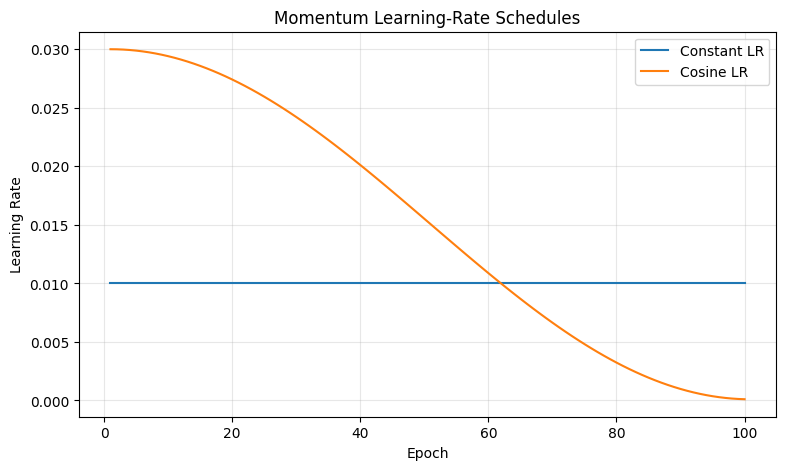

In [214]:
def compare_learning_rate_histories(
    histories,
    labels,
    title,
):
    """
    Compare base learning-rate histories.
    """

    plt.figure(
        figsize=(9, 5)
    )


    for history, label in zip(
        histories,
        labels,
    ):

        epochs = np.arange(

            1,

            len(

                history[
                    "learning_rate"
                ]

            ) + 1,
        )


        plt.plot(

            epochs,

            history[
                "learning_rate"
            ],

            label=label,
        )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        "Learning Rate"
    )


    plt.title(
        title
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.show()

compare_learning_rate_histories(

    histories=[

        momentum_history,

        scheduled_momentum_history,
    ],

    labels=[

        "Constant LR",

        "Cosine LR",
    ],

    title=(

        "Momentum Learning-Rate "
        "Schedules"
    ),
)

In [215]:
assert (

    scheduled_momentum_history[
        "train_loss"
    ][-1]

    <

    scheduled_momentum_history[
        "train_loss"
    ][0]
)


assert np.isclose(

    scheduled_momentum_parameters[
        "weight"
    ].item(),

    3.0,

    atol=0.3,
)


assert np.isclose(

    scheduled_momentum_parameters[
        "bias"
    ].item(),

    2.0,

    atol=0.3,
)


assert (

    len(

        scheduled_momentum_history[
            "learning_rate"
        ]
    )

    == 100
)


assert (

    scheduled_momentum_history[
        "learning_rate"
    ][-1]

    <

    scheduled_momentum_history[
        "learning_rate"
    ][0]
)


assert (

    cosine_momentum_scheduler
    .step_count

    == 100
)


assert np.isclose(

    scheduled_momentum_optimizer
    .learning_rate,

    0.0001,
)


print(
    "All scheduler integration "
    "checks passed."
)

All scheduler integration checks passed.


# Part 11: Gradient Clipping

Gradient clipping modifies gradients before the optimizer
updates the parameters.

## Clipping by value

Each gradient element is restricted to:

$$
[-c,\ c]
$$

Therefore:

$$
g_i
\leftarrow
\operatorname{clip}(g_i,-c,c)
$$

## Clipping by global norm

First compute:

$$
\|g\|_2
=
\sqrt{
\sum_k
\|g_k\|_2^2
}
$$

If:

$$
\|g\|_2 > c
$$

scale every gradient using:

$$
g_k
\leftarrow
g_k
\frac{c}
{\|g\|_2+\epsilon}
$$

Global-norm clipping preserves the overall gradient direction
while reducing its magnitude.

In [216]:
def clip_gradients_by_value(
    gradients,
    clip_value,
):
    """
    Clip every gradient element to:

        [-clip_value, clip_value]

    Returns a new dictionary.
    """

    if clip_value <= 0:

        raise ValueError(
            "clip_value must be positive."
        )


    return {

        name: np.clip(
            gradient,
            -clip_value,
            clip_value,
        )

        for name, gradient
        in gradients.items()
    }

In [217]:
def clip_gradients_by_value(
    gradients,
    clip_value,
):
    """
    Clip every gradient element to:

        [-clip_value, clip_value]

    Returns a new dictionary.
    """

    if clip_value <= 0:

        raise ValueError(
            "clip_value must be positive."
        )


    return {

        name: np.clip(
            gradient,
            -clip_value,
            clip_value,
        )

        for name, gradient
        in gradients.items()
    }

test_gradients = {

    "weight": np.array(
        [[-10.0, 2.0, 20.0]]
    ),

    "bias": np.array(
        [[5.0]]
    ),
}


value_clipped = (

    clip_gradients_by_value(

        test_gradients,

        clip_value=3.0,
    )
)


print(
    value_clipped
)

assert np.allclose(

    value_clipped["weight"],

    [[-3.0, 2.0, 3.0]],
)


assert np.allclose(

    value_clipped["bias"],

    [[3.0]],
)


print(
    "Value clipping passed."
)

{'weight': array([[-3.,  2.,  3.]]), 'bias': array([[3.]])}
Value clipping passed.


In [218]:
def clip_gradients_by_global_norm(
    gradients,
    max_norm,
    epsilon=1e-12,
):
    """
    Clip gradients using their combined
    global L2 norm.

    Returns:

        clipped_gradients,
        norm_before,
        norm_after
    """

    if max_norm <= 0:

        raise ValueError(
            "max_norm must be positive."
        )


    norm_before = (

        compute_global_gradient_norm(
            gradients
        )
    )


    if norm_before > max_norm:

        scale = (

            max_norm

            / (
                norm_before
                + epsilon
            )
        )

    else:

        scale = 1.0


    clipped_gradients = {

        name: gradient * scale

        for name, gradient
        in gradients.items()
    }


    norm_after = (

        compute_global_gradient_norm(

            clipped_gradients
        )
    )


    return (

        clipped_gradients,

        norm_before,

        norm_after,
    )

test_gradients = {

    "weight": np.array(
        [[3.0]]
    ),

    "bias": np.array(
        [[4.0]]
    ),
}


(
    clipped_gradients,
    norm_before,
    norm_after,
) = clip_gradients_by_global_norm(

    test_gradients,

    max_norm=2.0,
)


print(
    "Norm before:",
    norm_before,
)


print(
    "Norm after:",
    norm_after,
)


print(
    "Clipped gradients:",
    clipped_gradients,
)

assert np.isclose(
    norm_before,
    5.0,
)


assert np.isclose(
    norm_after,
    2.0,
)


assert np.isclose(

    clipped_gradients[
        "weight"
    ].item(),

    1.2,
)


assert np.isclose(

    clipped_gradients[
        "bias"
    ].item(),

    1.6,
)


print(
    "Global-norm clipping passed."
)

Norm before: 5.0
Norm after: 1.9999999999995999
Clipped gradients: {'weight': array([[1.2]]), 'bias': array([[1.6]])}
Global-norm clipping passed.


In [219]:
small_gradients = {

    "weight": np.array(
        [[0.3]]
    ),

    "bias": np.array(
        [[0.4]]
    ),
}


(
    unchanged_gradients,
    norm_before,
    norm_after,
) = clip_gradients_by_global_norm(

    small_gradients,

    max_norm=2.0,
)


assert np.isclose(
    norm_before,
    0.5,
)


assert np.isclose(
    norm_after,
    0.5,
)


assert np.allclose(

    unchanged_gradients[
        "weight"
    ],

    small_gradients[
        "weight"
    ],
)


print(
    "Small gradients remain unchanged."
)

Small gradients remain unchanged.
